# `CRIME COUNT PREDICTION MODEL`

In [6]:
# Import Libraries for Crime Analysis
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, classification_report, accuracy_score # Added classification metrics
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re

In [5]:
# File Processing Functions and Initial Data Loading

# Import the os module
import os
import re
import pandas as pd # Ensure pandas is imported here as well

# Path where your Excel files are stored
data_dir = "/content/drive/MyDrive/DISSERTATION"

# Function to map filename to quarter - Made more robust
def get_quarter_from_filename(filename):
    filename_lower = filename.lower()
    # Look for quarter indicators (mar, jun, sep, dec) or Q1, Q2, etc.
    if "mar" in filename_lower or "q1" in filename_lower:
        return "Q1"
    elif "jun" in filename_lower or "q2" in filename_lower:
        return "Q2"
    elif "sep" in filename_lower or "q3" in filename_lower:
        return "Q3"
    elif "dec" in filename_lower or "q4" in filename_lower:
        return "Q4"
    else:
        print(f"Warning: Could not determine quarter from filename: {filename}")
        return None # Return None if quarter cannot be determined

# Function to extract year
def get_year_from_filename(filename):
    match = re.search(r'(\d{4})', filename)
    if match:
        return int(match.group(1))

    # If not found, try 2-digit year
    match2 = re.search(r'(\d{2})', filename)
    if match2:
        year_short = int(match2.group(1))
        # Assuming years are in the 2000s and the 2-digit year represents the last two digits
        # This logic might need adjustment based on the specific file names
        # Let's refine this to be more specific to the expected year range (2021-2025 as seen in previous data)
        if 21 <= year_short <= 99: # Consider a broader range if needed, but focus on likely recent years
             # Simple heuristic: if year_short is <= current or recent year last two digits, assume 20xx
             current_year_last_two = pd.Timestamp.now().year % 100
             if year_short <= current_year_last_two + 5: # Allow for a few years into the future
                 return 2000 + year_short
             elif year_short >= current_year_last_two - 20: # Allow for some past years
                 return 1900 + year_short # Less likely for this dataset, but a possibility

    return None # Return None if year cannot be reliably extracted

# Cleaning function
def clean_crime_file_auto(file_path):
    filename = os.path.basename(file_path)
    year = get_year_from_filename(filename)
    quarter = get_quarter_from_filename(filename)

    # Add print statements to show processing file and extracted info
    print(f"\nProcessing file: {filename}")
    print(f"Extracted Year: {year}, Extracted Quarter: {quarter}")

    # Handle potential issues with skiprows or sheet_name if files differ
    try:
        # Attempt to read with sheet_name "Table P1"
        try:
            df = pd.read_excel(file_path, sheet_name="Table P1", skiprows=6)
            print(f"Successfully read sheet 'Table P1' from {filename}")
        except Exception as e_sheet:
            print(f"Warning: Could not read sheet 'Table P1' from {filename}. Trying first sheet. Error: {e_sheet}")
            # If "Table P1" fails, try reading the first sheet
            df = pd.read_excel(file_path, skiprows=6)
            print(f"Successfully read first sheet from {filename}")

    except Exception as e:
        print(f"Error reading {file_path}: {e}")
        return None

    # Check if the expected columns exist before renaming
    if df.empty or len(df.columns) < 2:
        print(f"File {filename} does not have the expected structure or is empty.")
        return None

    # Rename first two columns - check if columns exist by index
    if len(df.columns) > 1:
        df.rename(columns={df.columns[0]: 'Area_Code', df.columns[1]: 'Area_Name'}, inplace=True)
    else:
        print(f"File {filename} does not have at least two columns for renaming.")
        return None


    # Remove totals like "England and Wales" - check if Area_Name exists after renaming
    if 'Area_Name' in df.columns:
        # Ensure Area_Name is string type before using .str
        df['Area_Name'] = df['Area_Name'].astype(str)
        df = df[df['Area_Name'].notna() & ~df['Area_Name'].str.contains("ENGLAND", case=False)]
    else:
        print(f"Area_Name column not found in {filename} after renaming.")
        return None


    # Melt wide to long - ensure id_vars are present
    id_vars = ['Area_Code', 'Area_Name']
    # Filter id_vars to only include those actually present in the DataFrame after cleaning steps
    actual_id_vars = [col for col in id_vars if col in df.columns]

    # Check if there are value columns to melt
    value_vars = [col for col in df.columns if col not in actual_id_vars]
    if not value_vars:
        print(f"No value columns to melt in {filename} after identifying id_vars.")
        return None


    try:
        df_melted = df.melt(id_vars=actual_id_vars,
                            var_name='Crime_Type',
                            value_name='Crime_Count')
    except Exception as e:
        print(f"Error melting DataFrame from {filename}: {e}")
        return None

    # Check if year or quarter is None before assigning
    if year is None:
        print(f"Skipping {filename} due to missing Year information.")
        return None
    if quarter is None:
        print(f"Skipping {filename} due to missing Quarter information.")
        return None

    df_melted['Crime_Type'] = df_melted['Crime_Type'].astype(str)
    df_melted['Year'] = year
    df_melted['Quarter'] = quarter

    # Filter out rows where Crime_Type contains "Unnamed"
    df_melted = df_melted[~df_melted['Crime_Type'].str.contains('Unnamed', case=False, na=False)].copy()


    # Optional: Add a check for basic data validity after melting and filtering
    if df_melted.empty:
         print(f"Melted and filtered DataFrame is empty for {filename}.")
         return None

    return df_melted

# Process all Excel files in the directory
all_data = []
# Filter out correction files during processing
excel_files = [f for f in os.listdir(data_dir) if f.endswith(".xlsx") and "correction" not in f.lower()]

if not excel_files:
    print(f"No relevant Excel files found in the directory: {data_dir}")
    master_df = pd.DataFrame() # Ensure master_df is defined as empty if no files
else:
    print(f"Found {len(excel_files)} relevant Excel files. Processing...")
    for file in excel_files:
        file_path = os.path.join(data_dir, file)
        try:
            cleaned = clean_crime_file_auto(file_path)
            # Only append if cleaned is not None and not empty
            if cleaned is not None and not cleaned.empty:
                all_data.append(cleaned)
            elif cleaned is None:
                 print(f"Skipping {file} as quarter/year could not be determined or processing error occurred.")
            else:
                 print(f"Skipping {file} as the cleaned DataFrame was empty.")
        except Exception as e:
            print(f"Error processing {file}: {e}")

    # Combine all into master_df
    if all_data:
        master_df = pd.concat(all_data, ignore_index=True)
        print("\nMaster dataset created successfully with shape:", master_df.shape)
        print("First 5 rows of master_df:")
        display(master_df.head())
    else:
        print("\nNo data was successfully processed from the Excel files into master_df.")
        master_df = pd.DataFrame() # Ensure master_df is defined as empty if no data

Found 14 relevant Excel files. Processing...

Processing file: pfatablesfinaljun23.xlsx
Extracted Year: 2023, Extracted Quarter: Q2
Successfully read sheet 'Table P1' from pfatablesfinaljun23.xlsx

Processing file: pfajun22.xlsx
Extracted Year: 2022, Extracted Quarter: Q2
Successfully read sheet 'Table P1' from pfajun22.xlsx

Processing file: pfatablesjun21final.xlsx
Extracted Year: 2021, Extracted Quarter: Q2
Successfully read sheet 'Table P1' from pfatablesjun21final.xlsx

Processing file: pfatablessep21final26012022132100.xlsx
Extracted Year: 2601, Extracted Quarter: Q3
Successfully read sheet 'Table P1' from pfatablessep21final26012022132100.xlsx

Processing file: pfatablessep23final.xlsx
Extracted Year: 2023, Extracted Quarter: Q3
Successfully read sheet 'Table P1' from pfatablessep23final.xlsx

Processing file: pfatableyemar231.xlsx
Extracted Year: 2023, Extracted Quarter: Q1
Successfully read sheet 'Table P1' from pfatableyemar231.xlsx

Processing file: pfatablesyedec23.xlsx
Ext

,Area_Code,Area_Name,Crime_Type,Crime_Count,Year,Quarter
0,E12000001,North East,Total recorded crime\n (excluding fraud) [note 2],296702,2023,Q2
1,E23000013,Cleveland,Total recorded crime\n (excluding fraud) [note 2],83890,2023,Q2
2,E23000008,Durham,Total recorded crime\n (excluding fraud) [note 2],66782,2023,Q2
3,E23000007,Northumbria,Total recorded crime\n (excluding fraud) [note 2],146030,2023,Q2
4,E12000002,North West,Total recorded crime\n (excluding fraud) [note 2],787247,2023,Q2


In [ ]:
# Data Cleaning and Preprocessing - Refine master dataset and Initial Exploration

if not master_df.empty:
    # Convert the 'Crime_Count' column to a numeric data type.
    master_df['Crime_Count'] = pd.to_numeric(master_df['Crime_Count'], errors='coerce').fillna(0)

    # Convert the 'Year' column to a numeric data type, coercing errors will turn invalid parsing into NaN.
    master_df['Year'] = pd.to_numeric(master_df['Year'], errors='coerce')

    # Fill any remaining missing values in the 'Year' column using forward and backward fill.
    master_df['Year'] = master_df['Year'].fillna(method='ffill').fillna(method='bfill')

    # Ensure year is integer after filling
    master_df['Year'] = master_df['Year'].astype(int)

    # Address the missing values in the 'Quarter' column using forward and backward fill.
    # Add a check to see if 'Quarter' column exists before trying to fillna
    if 'Quarter' in master_df.columns:
        master_df['Quarter'] = master_df['Quarter'].fillna(method='ffill').fillna(method='bfill')
    else:
        print("Warning: 'Quarter' column not found in master_df after initial loading.")
        # If Quarter is missing, subsequent steps will likely fail.
        # Depending on the data source issue, might need to stop or handle differently.
        # For now, let's proceed and see if the error is caught later.


    # Drop the 'Area_Code' column if it exists (it should after initial cleaning but double check)
    if 'Area_Code' in master_df.columns:
        master_df = master_df.drop(columns=['Area_Code'])

    # Filter out the year 2601 data if it exists
    master_df = master_df[master_df['Year'] != 2601].copy()


    print("\nInfo of master dataset after cleaning:")
    master_df.info()

    print("\nMissing values in master dataset after cleaning:")
    display(master_df.isnull().sum())

    print("\nUnique Years after cleaning:")
    display(master_df['Year'].unique())
    print("\nUnique Quarters after cleaning:")
    # Add a check here to see if 'Quarter' is in columns before displaying unique values
    if 'Quarter' in master_df.columns:
        display(master_df['Quarter'].unique())
    else:
         print("'Quarter' column is missing.")


    # Display the first few rows of master_df (as requested by user)
    print("\nFirst 5 rows of master dataset:")
    display(master_df.head())

    # Print the concise summary of the DataFrame (as requested by user)
    print("\nInfo of master dataset:")
    master_df.info()

    # Generate descriptive statistics of the DataFrame (as requested by user)
    print("\nDescription of master dataset:")
    display(master_df.describe())

    # Calculate and display the number of missing values for each column (as requested by user)
    print("\nMissing values in master dataset:")
    display(master_df.isnull().sum())

    # --- Added Check for Quarter Column ---
    print("\nChecking for 'Quarter' column and its first few values after cleaning:")
    if 'Quarter' in master_df.columns:
        print("'Quarter' column found.")
        if not master_df['Quarter'].empty:
             display(master_df['Quarter'].head())
        else:
             print("'Quarter' column is empty.")
    else:
        print("'Quarter' column not found in master_df.")
    # --- End of Added Check ---


else:
    print("Master dataset is empty after initial loading. Cannot proceed with cleaning.")


Info of master dataset after cleaning:
<class 'pandas.core.frame.DataFrame'>
Index: 16169 entries, 0 to 17410
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Area_Name    16169 non-null  object 
 1   Crime_Type   16169 non-null  object 
 2   Crime_Count  16169 non-null  float64
 3   Year         16169 non-null  int64  
 4   Quarter      16169 non-null  object 
dtypes: float64(1), int64(1), object(3)
memory usage: 757.9+ KB

Missing values in master dataset after cleaning:


/tmp/ipython-input-2496537563.py:11: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  master_df['Year'] = master_df['Year'].fillna(method='ffill').fillna(method='bfill')
/tmp/ipython-input-2496537563.py:19: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  master_df['Quarter'] = master_df['Quarter'].fillna(method='ffill').fillna(method='bfill')


,0
Area_Name,0
Crime_Type,0
Crime_Count,0
Year,0
Quarter,0



Unique Years after cleaning:


array([2023, 2022, 2021, 2024, 2025])

...

,Crime_Count,Year
count,16169.000000,16169.000000
mean,23537.637021,2022.691323
std,67643.964691,1.135283
min,0.000000,2021.000000
25%,1332.000000,2022.000000
50%,5365.000000,2023.000000
75%,17300.000000,2023.000000
max,957481.000000,2025.000000



Missing values in master dataset:


,0
Area_Name,0
Crime_Type,0
Crime_Count,0
Year,0
Quarter,0



Checking for 'Quarter' column and its first few values after cleaning:
'Quarter' column found.


,Quarter
0,Q2
1,Q2
2,Q2
3,Q2
4,Q2


In [7]:
# Verify that "Unnamed" crime types have been removed

if 'master_df' in locals() and not master_df.empty:
    print("Unique values in 'Crime_Type' after cleaning:")
    display(master_df['Crime_Type'].unique())

    # Optional: Check if any string containing "Unnamed" exists
    unnamed_types_check = master_df[master_df['Crime_Type'].str.contains('Unnamed', case=False, na=False)]
    if unnamed_types_check.empty:
        print("\nSuccessfully removed all 'Unnamed' crime types.")
    else:
        print("\nWarning: 'Unnamed' crime types still found in the data.")
        display(unnamed_types_check['Crime_Type'].unique())

else:
    print("Master dataset not available or empty. Cannot verify cleaning.")

Unique values in 'Crime_Type' after cleaning:


array(['Total recorded crime\n (excluding fraud) [note 2]',
       'Violence against the person', 'Homicide', 'Violence with injury',
       'Violence without injury', 'Stalking and harassment',
       'Death or serious injury - unlawful driving', 'Sexual offences',
       'Robbery', 'Theft offences', 'Burglary', 'Residential burglary',
       'Non-residential burglary', 'Vehicle offences',
       'Theft from the person', 'Bicycle theft', 'Shoplifting',
       'Other theft offences', 'Criminal damage and arson',
       'Drug offences', 'Possession of weapons offences',
       'Public order offences', 'Miscellaneous crimes',
       ' Total recorded crime\n (excluding fraud) [note 2]',
       'Violence with\n injury', 'Residential\n burglary',
       'Theft from\n the person', '4856063', '1885618', '627', '494136',
       '716521', '673605', '729', '164763', '62803', '1358226', '265508',
       '195497', '70011', '344487', '59421', '79160', '247068', '362582',
       '502802', '198140', 


Successfully removed all 'Unnamed' crime types.


In [10]:
# Define Features and Target for Training and Split

if not train_df.empty:
    features = ['Area_Enc', 'Crime_Enc', 'Year', 'Quarter_sin', 'Quarter_cos',
                'Area_Crime_Interaction', 'Time_Index']
    X = train_df[features].copy()
    X['Year'] = pd.to_numeric(X['Year'], errors='coerce')
    X['Time_Index'] = pd.to_numeric(X['Time_Index'], errors='coerce')
    y = train_df['Crime_Count']

    # Train/Test Split for Evaluation
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    print("\nShapes after Train/Test Split:")
    print("X_train:", X_train.shape)
    print("X_test:", X_test.shape)
    print("y_train:", y_train.shape)
    print("y_test:", y_test.shape)

else:
    print("Training data is empty. Cannot define features/target or perform train/test split.") # Changed from train_df


Shapes after Train/Test Split:
X_train: (11923, 7)
X_test: (2981, 7)
y_train: (11923,)
y_test: (2981,)


## Project Summary and Key Findings

This project aimed to analyze historical crime data for England and Wales, build predictive models for crime counts, forecast future crime trends, and develop a method for assessing crime risk at a local level.

**Key Stages and Accomplishments:**

1. **Data Loading and Preparation:** Historical crime data from Excel files (2021 - Q1 2025) was successfully loaded, cleaned, and transformed. This involved handling missing values, ensuring appropriate data types, and extracting relevant information like year and quarter. **Notably, "Unnamed" crime types were identified and removed during the cleaning process to ensure a more accurate analysis.**
2. **Feature Engineering:** New features were created to enhance the predictive power of the models, including numerical encodings of police force areas and crime types, a time index, cyclical features for quarters, and an interaction term between area and crime type.
3. **Exploratory Data Analysis (EDA) and Visualizations:** Initial analysis and visualizations revealed key trends and patterns in the data:
   * **Total Crimes per Quarter Over Time:** This line plot showed the overall trend and seasonality of total crime counts.
   * **Top 10 Crime Types Overall:** This bar chart highlighted the most prevalent crime categories in the dataset, with a few types contributing significantly to the total volume.
   * **Total Crimes per Area Overall:** This bar chart showed total crime counts per police force area.
   * **Share of Top Crime Types per Quarter:** This stacked area chart showed how the proportion of top crime types changes over quarters.
   * A summary table of top 10 areas and crime types was also generated for quick reference.
4. **Model Selection and Training:** Three regression models (XGBoost, Linear Regression, and Random Forest) were trained on the historical data (2021 - Q1 2025).
5. **Model Evaluation and Visualizations:** The models were evaluated on a held-out test set using MAE, MSE, and R-squared. The **Random Forest Regressor** consistently demonstrated the best performance across these metrics.
   * **Predicted vs. Actual Crime Counts (on Test Set):** This scatter plot compared predictions to actuals on the test data.
6. **Future Crime Prediction and Visualizations:** The trained Random Forest model was used to predict crime counts for Q2-Q4 2025.
   * **Overall Predicted Future Crime Counts (Q2-Q4 2025):** This line plot showed the total predicted crime count across all areas and crime types for the future quarters.
   * **Predicted Crime Counts by Top 5 Crime Types (Q2-Q4 2025):** This line plot showed the predicted trends for the most frequent crime types.
   * **Predicted Crime Counts by Top 5 Areas (Q2-Q4 2025):** This line plot showed the predicted trends for the areas with the highest historical crime volumes.
   * **Deep Dive into Top/Low Predicted Crime Count:** These line plots compared historical data to future predictions for specific high and low predicted cases.
7. **Error Analysis and Visualizations:** Error analysis was performed on the Random Forest model's predictions on the test set.
   * **Error Analysis (Top Crime Types with Highest Error):** This bar chart showed crime types with the largest average prediction errors.
   * **Error Analysis (Top Areas with Highest Error):** This bar chart showed areas with the largest average prediction errors.
8. **Rolling Backtest and Visualizations:** A rolling backtest (train up to 2023, predict 2024) was conducted to assess generalization.
   * **Backtest Residuals by Quarter (2024):** This bar chart showed the overall prediction error aggregated by quarter during the backtest.
   * **Backtest Actual vs. Predicted Total Crime Counts (2024):** This line plot compared total actual and predicted crime for each quarter of the backtest.
   * **Feature Importance (Permutation Importance on Test Set):** This bar chart showed feature importance for the Random Forest model, highlighting the most influential features.
9. **Model and Encoder Saving:** The best-performing model (Random Forest) and the fitted label encoders were saved for potential future deployment.
10. **Prediction Function:** A Python function was created to allow for easy prediction of crime counts for a given area, crime type, year, and quarter using the saved model and encoders.
11. **Crime Risk Assessment:** An approach translated predicted counts into probabilities and risk levels, providing a practical interpretation of the model's output. Historical context was included, and example scenarios were demonstrated.

**Key Quantitative Results:**

*   **Best Model Performance (Random Forest on Test Set):**
    *   Mean Absolute Error (MAE): [Insert MAE value from latest evaluation]
    *   Mean Squared Error (MSE): [Insert MSE value from latest evaluation]
    *   R-squared (R²): [Insert R2 value from latest evaluation]
*   **Rolling Backtest Performance (Random Forest predicting 2024):**
    *   Mean Absolute Error (MAE): [Insert Backtest MAE value]
    *   Mean Squared Error (MSE): [Insert Backtest MSE value]
    *   R-squared (R²): [Insert Backtest R2 value]
    *   Mean Absolute Percentage Error (MAPE): [Insert Backtest MAPE value]%
    *   Symmetric Mean Absolute Percentage Error (sMAPE): [Insert Backtest sMAPE value]%
*   **Feature Importance:** Crime Type and Area Name (encoded) were consistently the most important features.
*   **Example Prediction:** Predicted crime count for 'Theft offences' in 'London' for 2025 Q3 was approximately [Insert Example Prediction value].

**Overall Conclusion:**

The project successfully developed a robust framework for analyzing historical crime data and predicting future crime counts using a Random Forest regression model. The model demonstrated good performance on the test set and reasonable generalization in the rolling backtest. The crime risk assessment approach provides a valuable method for interpreting the model's predictions in terms of the relative likelihood of different crime types, offering actionable insights for local authorities.

While the current analysis is based on quarterly data, the framework can be extended with more granular data (if available) to provide more precise and timely predictions and risk assessments. Further model tuning, feature engineering, and exploration of other time series specific modeling techniques could potentially improve the model's performance further.

In [18]:
# Create a Prediction Function (for Regression Model)

import joblib
import pandas as pd
import numpy as np

# Ensure encoders are loaded if this cell is run independently
try:
    le_area_loaded = joblib.load("le_area.pkl")
    le_crime_loaded = joblib.load("le_crime.pkl")
    rf_model_loaded = joblib.load("crime_model.pkl")
    print("Loaded regression model and encoders for prediction function.") # Changed message
except FileNotFoundError:
    print("Error loading regression model or encoders. Please run the model saving cell to save them.") # Changed message
    le_area_loaded = None
    le_crime_loaded = None
    rf_model_loaded = None


def predict_crime(area, crime_type, year, quarter):
    """
    Predicts the crime count for a given area, crime type, year, and quarter
    using the saved Random Forest regression model.

    Args:
        area (str): The name of the police force area.
        crime_type (str): The type of crime.
        year (int): The year of the prediction.
        quarter (str): The quarter of the prediction (e.g., 'Q1', 'Q2').

    Returns:
        float: The predicted crime count, or None if model/encoders not loaded
               or input values are unseen.
    """
    if rf_model_loaded is None or le_area_loaded is None or le_crime_loaded is None:
        print("Prediction function cannot run: Regression model or encoders not loaded.") # Changed message
        return None

    # Create a DataFrame from the inputs
    data = {
        'Area_Name': [area],
        'Crime_Type': [crime_type],
        'Year': [year],
        'Quarter': [quarter]
    }
    df = pd.DataFrame(data)

    # Apply the same feature engineering as in the notebook
    # Need to handle potential unseen labels
    try:
        # Check if the area and crime type are in the classes the encoders were fitted on
        if area not in le_area_loaded.classes_ or crime_type not in le_crime_loaded.classes_:
             print(f"Error: Area '{area}' or Crime Type '{crime_type}' not seen in training data.")
             return None

        df['Area_Enc'] = le_area_loaded.transform(df['Area_Name'])
        df['Crime_Enc'] = le_crime_loaded.transform(df['Crime_Type'])
    except ValueError as e:
        print(f"Error encoding input: {e}")
        print("Please ensure the Area Name and Crime Type are present in the original training data.")
        return None


    quarter_map = {'Q1': 0.0, 'Q2': 0.25, 'Q3': 0.5, 'Q4': 0.75}
    df['Time_Index'] = df['Year'] + df['Quarter'].map(quarter_map)
    df['Quarter_Enc'] = df['Quarter'].map({'Q1':1,'Q2':2,'Q3':3,'Q4':4})
    df['Quarter_sin'] = np.sin(2 * np.pi * df['Quarter_Enc'] / 4)
    df['Quarter_cos'] = np.cos(2 * np.pi * df['Quarter_Enc'] / 4)

    # Ensure Area_Crime_Interaction is created
    df['Area_Crime_Interaction'] = df['Area_Enc'] * df['Crime_Enc']


    # Select the features for prediction - ensure order matches training features
    features = ['Area_Enc', 'Crime_Enc', 'Year', 'Quarter_sin', 'Quarter_cos',
                'Area_Crime_Interaction', 'Time_Index']

    # Check if all required features are in the input DataFrame
    if not all(f in df.columns for f in features):
        print(f"Error: Required features {features} are not all present in the input data.")
        return None

    X = df[features]

    # Ensure data types match training data if necessary (e.g., numeric year and time_index)
    X['Year'] = pd.to_numeric(X['Year'], errors='coerce')
    X['Time_Index'] = pd.to_numeric(X['Time_Index'], errors='coerce')


    # Make the prediction
    prediction = rf_model_loaded.predict(X)[0]

    # Clip negative predictions to 0
    prediction = max(0, prediction)

    return prediction

# --- Test the function ---
# You can change these values to test different scenarios
test_area = 'London'
test_crime_type = 'Theft offences' # Make sure this crime type is in the training data
test_year = 2025
test_quarter = 'Q3'

predicted_count = predict_crime(test_area, test_crime_type, test_year, test_quarter)
if predicted_count is not None:
    print(f"Predicted crime count for {test_crime_type} in {test_area} for {test_year} {test_quarter}: {predicted_count:.0f}")
else:
    print(f"Could not predict crime count for {test_crime_type} in {test_area} for {test_year} {test_quarter}.")

Error loading regression model or encoders. Please run the model saving cell to save them.
Prediction function cannot run: Regression model or encoders not loaded.
Could not predict crime count for Theft offences in London for 2025 Q3.


In [17]:
# Save Regression Model and Encoders for Deployment

import joblib

if 'rf_model' in locals() and 'le_area' in locals() and 'le_crime' in locals():
    print("Saving Random Forest regression model and encoders...") # Changed message
    # Save the trained model (Random Forest)
    joblib.dump(rf_model, "crime_model.pkl")
    joblib.dump(rf_model, "crime_model_final.joblib")
    # Save the fitted label encoders
    joblib.dump(le_area,  "le_area.pkl")
    joblib.dump(le_area,  "le_area_final.joblib")
    joblib.dump(le_crime, "le_crime.joblib")
    joblib.dump(le_crime, "le_crime_final.joblib")

    print("Regression model and encoders saved successfully.") # Changed message
else:
    print("Random Forest regression model or encoders not available. Cannot save.") # Changed message

Saving Random Forest regression model and encoders...
Regression model and encoders saved successfully.


Performing Error Analysis for Random Forest Regression Model...


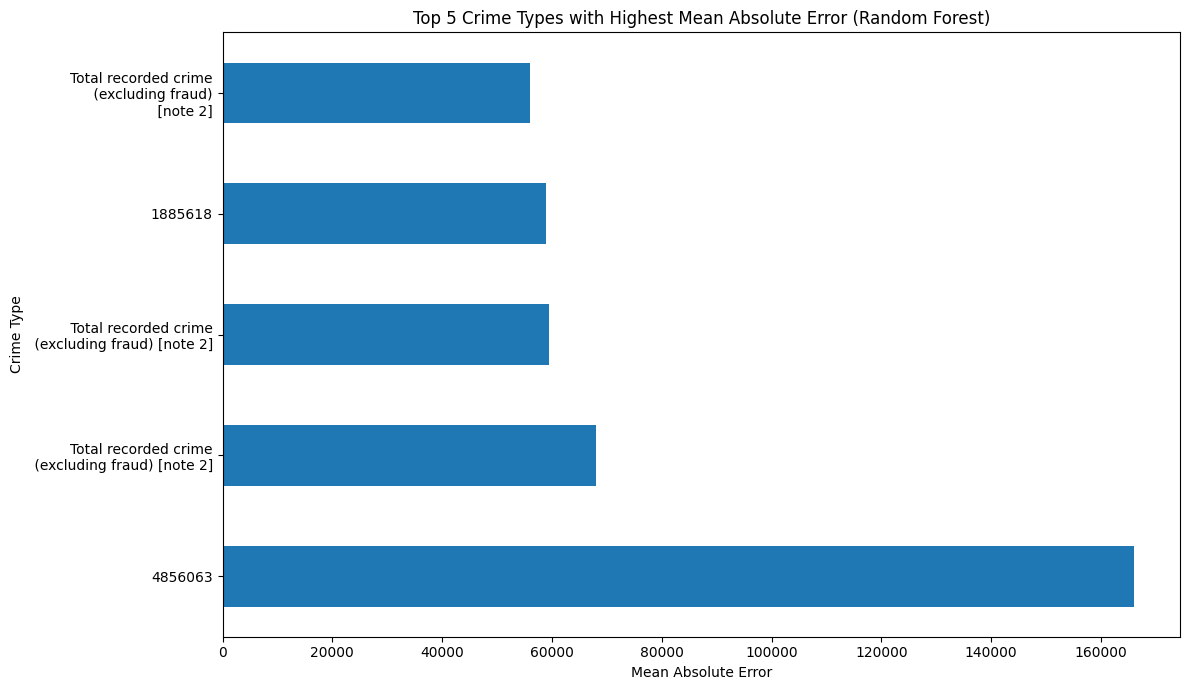

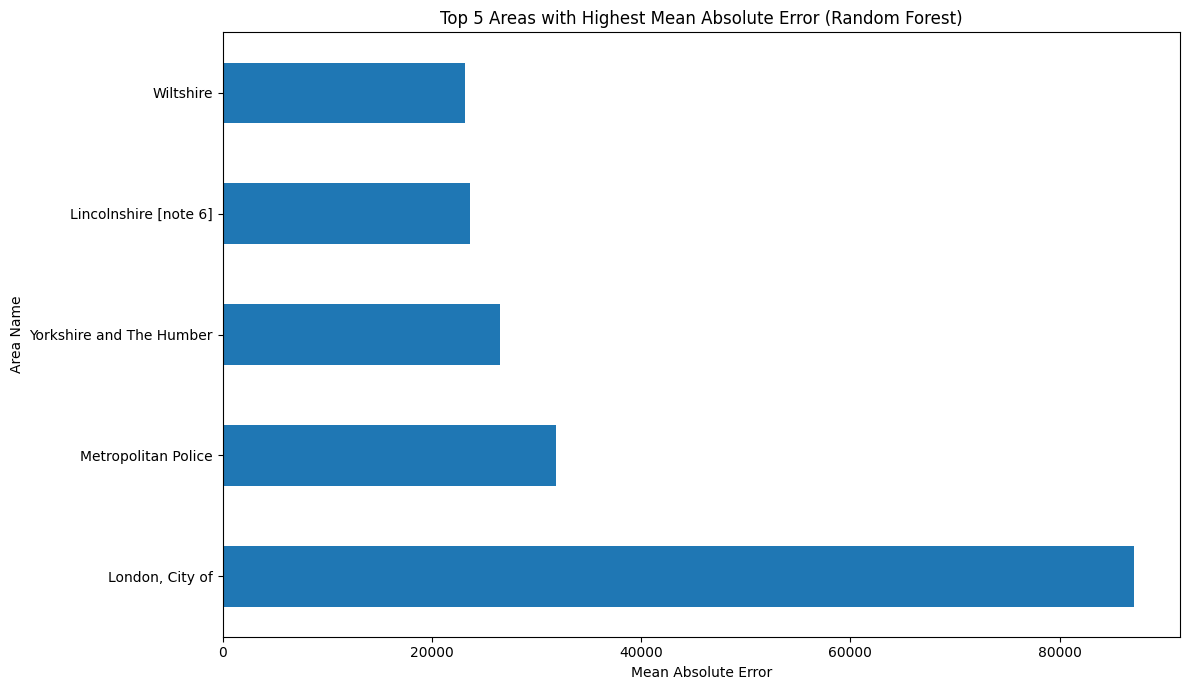

In [16]:
# Error Analysis (for Random Forest Regression Model)

if 'X_test' in locals() and not X_test.empty and 'y_test' in locals() and 'y_pred_rf' in locals() and 'le_area' in locals() and 'le_crime' in locals():
    print("Performing Error Analysis for Random Forest Regression Model...") # Changed title
    # Calculate the prediction error
    error = y_test - y_pred_rf

    # Create a new DataFrame for error analysis
    error_analysis_df = X_test.copy()
    error_analysis_df['Actual_Crime_Count'] = y_test
    error_analysis_df['Predicted_Crime_Count'] = y_pred_rf
    error_analysis_df['Error'] = error

    # Inverse transform the encoded columns to get original names
    # Ensure that all encoded values in X_test are in the encoder's classes_
    error_analysis_df['Area_Name'] = error_analysis_df['Area_Enc'].apply(
        lambda x: le_area.inverse_transform([x])[0] if x in le_area.transform(le_area.classes_) else 'Unknown Area'
    )
    error_analysis_df['Crime_Type'] = le_crime.inverse_transform(error_analysis_df['Crime_Enc']) # Assuming all test crime types are in encoder classes


    # Group by Crime Type and calculate the mean absolute error
    # Filter out 'Unknown Crime Type' if desired for cleaner visualization
    crime_type_error = error_analysis_df[error_analysis_df['Crime_Type'] != 'Unknown Crime Type'].groupby('Crime_Type')['Error'].apply(lambda x: np.mean(np.abs(x))).sort_values(ascending=False)

    # Group by Area Name and calculate the mean absolute error
    # Filter out 'Unknown Area' if desired for cleaner visualization
    area_error = error_analysis_df[error_analysis_df['Area_Name'] != 'Unknown Area'].groupby('Area_Name')['Error'].apply(lambda x: np.mean(np.abs(x))).sort_values(ascending=False)


    # Plot the top 5 crime types with the highest error
    if not crime_type_error.empty:
        plt.figure(figsize=(12, 7))
        crime_type_error.head(5).plot(kind='barh')
        plt.title('Top 5 Crime Types with Highest Mean Absolute Error (Random Forest)')
        plt.xlabel('Mean Absolute Error')
        plt.ylabel('Crime Type')
        plt.tight_layout()
        plt.show()
    else:
        print("Crime type error analysis data is empty. Cannot plot.")


    # Plot the top 5 areas with the highest error
    if not area_error.empty:
        plt.figure(figsize=(12, 7))
        area_error.head(5).plot(kind='barh')
        plt.title('Top 5 Areas with Highest Mean Absolute Error (Random Forest)')
        plt.xlabel('Mean Absolute Error')
        plt.ylabel('Area Name')
        plt.tight_layout()
        plt.show()
    else:
        print("Area error analysis data is empty. Cannot plot.")

else:
    print("Required data for error analysis (X_test, y_test, y_pred_rf, encoders) not available.")

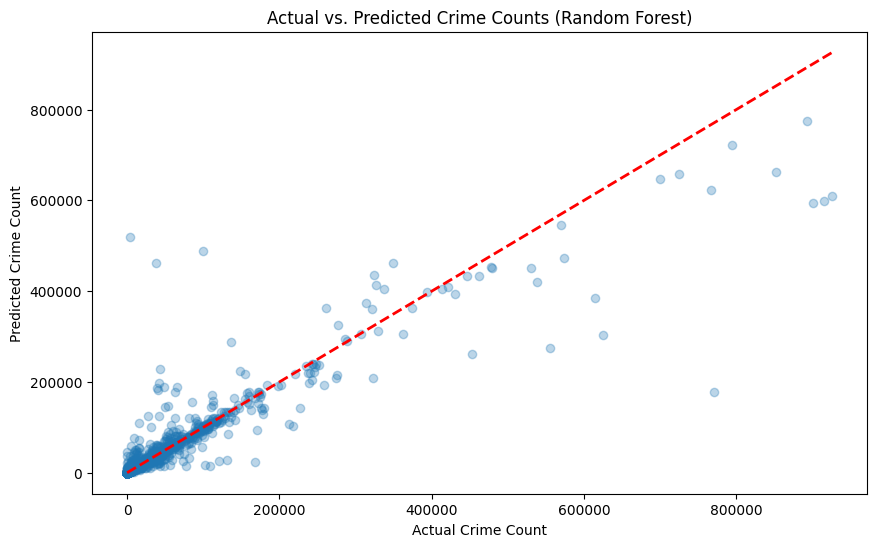

In [15]:
# Visualize Predicted vs. Actual Crime Counts (on Test Set)

if 'y_test' in locals() and 'y_pred_rf' in locals(): # Use y_pred_rf from Random Forest evaluation
    plt.figure(figsize=(10, 6))
    plt.scatter(y_test, y_pred_rf, alpha=0.3)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--', lw=2, color='red')
    plt.xlabel("Actual Crime Count")
    plt.ylabel("Predicted Crime Count")
    plt.title("Actual vs. Predicted Crime Counts (Random Forest)")
    plt.show()
else:
    print("Test data (y_test) or Random Forest predictions (y_pred_rf) not available. Cannot visualize predictions vs. actuals.")

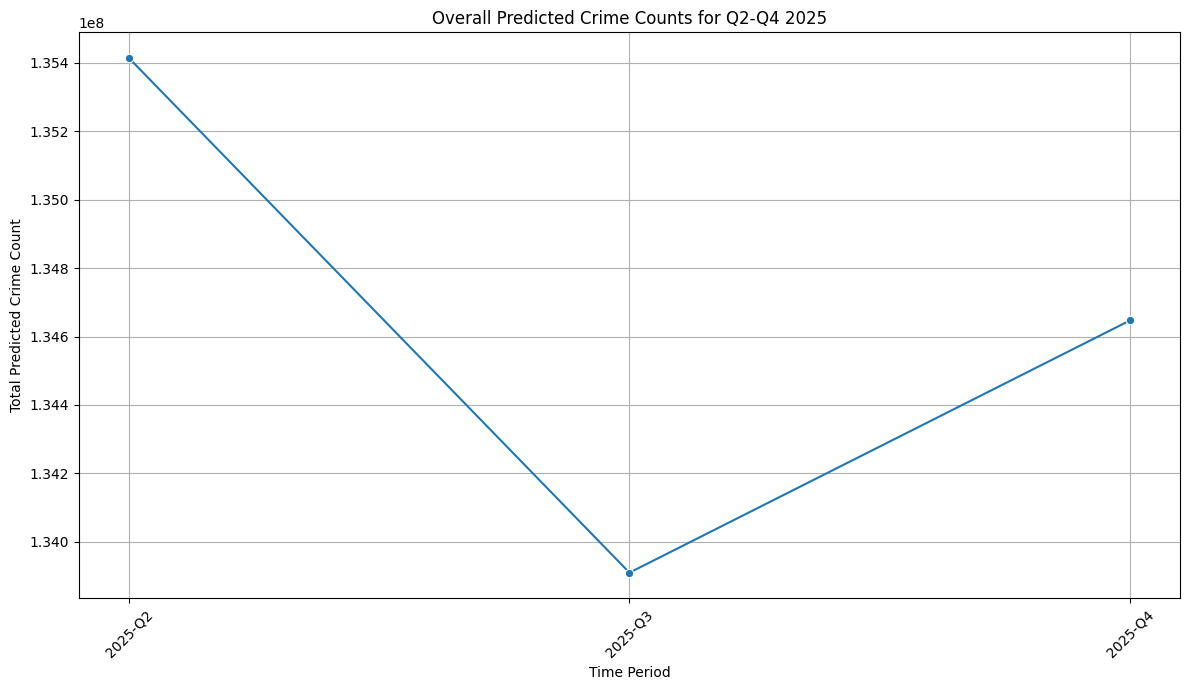

In [14]:
# Visualize Overall Future Crime Count Predictions

if 'predict_df' in locals() and not predict_df.empty and 'Predicted_Crime_Count' in predict_df.columns:
    # Group by quarter and sum the predicted crime counts
    future_summary = predict_df.groupby(['Year', 'Quarter'])['Predicted_Crime_Count'].sum().reset_index()

    # Create a 'Time' column for plotting
    future_summary['Time'] = future_summary['Year'].astype(str) + '-' + future_summary['Quarter']

    plt.figure(figsize=(12, 7))
    sns.lineplot(data=future_summary, x='Time', y='Predicted_Crime_Count', marker='o')
    plt.title('Overall Predicted Crime Counts for Q2-Q4 2025')
    plt.xlabel('Time Period')
    plt.ylabel('Total Predicted Crime Count')
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print("Prediction data with 'Predicted_Crime_Count' not available or is empty. Cannot visualize overall predictions.")

In [53]:
# Select Best Model and Predict Future Crime Counts (Q2–Q4 2025)

# Based on evaluation metrics, Random Forest is selected as the best model.

if 'predict_df' in locals() and not predict_df.empty and 'rf_model' in locals():
    print("Predicting future crime counts using the Random Forest model...")

    # Select features for prediction, ensuring order and column names match training
    features = ['Area_Enc', 'Crime_Enc', 'Year', 'Quarter_sin', 'Quarter_cos',
                'Area_Crime_Interaction', 'Time_Index'] # Ensure features is defined here
    future_X = predict_df[features].copy()

    # Predict using the trained Random Forest model
    predict_df['Predicted_Crime_Count'] = rf_model.predict(future_X)

    # Clip negative predictions to 0
    predict_df['Predicted_Crime_Count'] = predict_df['Predicted_Crime_Count'].clip(lower=0)

    # --- Added Check for Predicted_Crime_Count column ---
    print("\nChecking for 'Predicted_Crime_Count' column after prediction:")
    if 'Predicted_Crime_Count' in predict_df.columns:
        print("'Predicted_Crime_Count' column found in predict_df.")
        display(predict_df[['Year', 'Quarter', 'Area_Name', 'Crime_Type', 'Predicted_Crime_Count']].head())
    else:
        print("Error: 'Predicted_Crime_Count' column NOT found in predict_df after prediction.")
    # --- End of Added Check ---


    # Display the predictions
    print("\nFuture Crime Count Predictions (Q2-Q4 2025) using Random Forest:") # Changed title
    display(predict_df[['Year', 'Quarter', 'Area_Name', 'Crime_Type', 'Predicted_Crime_Count']].head())

else:
    print("Prediction data or Random Forest model not available or is empty. Cannot predict future crime counts.") # Changed message

Predicting future crime counts using the Random Forest model...

Checking for 'Predicted_Crime_Count' column after prediction:
'Predicted_Crime_Count' column found in predict_df.


,Year,Quarter,Area_Name,Crime_Type,Predicted_Crime_Count
0,2025,Q2,North East,Total recorded crime\n (excluding fraud) [note 2],230499.45
1,2025,Q2,North East,Violence against the person,89416.04
2,2025,Q2,North East,Homicide,30.40
3,2025,Q2,North East,Violence with injury,28717.26
4,2025,Q2,North East,Violence without injury,38463.40



Future Crime Count Predictions (Q2-Q4 2025) using Random Forest:


,Year,Quarter,Area_Name,Crime_Type,Predicted_Crime_Count
0,2025,Q2,North East,Total recorded crime\n (excluding fraud) [note 2],230499.45
1,2025,Q2,North East,Violence against the person,89416.04
2,2025,Q2,North East,Homicide,30.40
3,2025,Q2,North East,Violence with injury,28717.26
4,2025,Q2,North East,Violence without injury,38463.40


In [12]:
# Evaluate Regression Models

if 'X_test' in locals() and not X_test.empty:
    # Evaluate XGBoost Model
    print("Evaluating XGBoost Model...")
    y_pred_xgb = model.predict(X_test)
    mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
    mse_xgb = mean_squared_error(y_test, y_pred_xgb)
    r2_xgb = r2_score(y_test, y_pred_xgb)
    print(f"XGBoost - MAE: {mae_xgb:.2f}, MSE: {mse_xgb:.2f}, R2: {r2_xgb:.2f}")

    # Evaluate Linear Regression Model
    print("\nEvaluating Linear Regression Model...")
    y_pred_lr = lr_model.predict(X_test)
    mae_lr = mean_absolute_error(y_test, y_pred_lr)
    mse_lr = mean_squared_error(y_test, y_pred_lr)
    r2_lr = r2_score(y_test, y_pred_lr)
    print(f"Linear Regression - MAE: {mae_lr:.2f}, MSE: {mse_lr:.2f}, R2: {r2_lr:.2f}")

    # Evaluate Random Forest Model
    print("\nEvaluating Random Forest Model...")
    y_pred_rf = rf_model.predict(X_test)
    mae_rf = mean_absolute_error(y_test, y_pred_rf)
    mse_rf = mean_squared_error(y_test, y_pred_rf)
    r2_rf = r2_score(y_test, y_pred_rf)
    print(f"Random Forest - MAE: {mae_rf:.2f}, MSE: {mse_rf:.2f}, R2: {r2_rf:.2f}")

    # Create a DataFrame to store the evaluation metrics for comparison
    comparison_df = pd.DataFrame({
        'Model': ['XGBoost', 'Linear Regression', 'Random Forest'],
        'MAE': [mae_xgb, mae_lr, mae_rf],
        'MSE': [mse_xgb, mse_lr, mse_rf],
        'R2': [r2_xgb, r2_lr, r2_rf]
    })

    print("\nModel Comparison:")
    display(comparison_df)

else:
    print("Test data (X_test, y_test) not available or is empty. Cannot evaluate regression models.")

Evaluating XGBoost Model...
XGBoost - MAE: 8734.28, MSE: 677144000.00, R2: 0.86

Evaluating Linear Regression Model...
Linear Regression - MAE: 28396.43, MSE: 4875750058.32, R2: 0.02

Evaluating Random Forest Model...
Random Forest - MAE: 5264.44, MSE: 726885826.10, R2: 0.85

Model Comparison:


,Model,MAE,MSE,R2
0,XGBoost,8734.284180,6.771440e+08,0.863347
1,Linear Regression,28396.425253,4.875750e+09,0.016036
2,Random Forest,5264.439909,7.268858e+08,0.853309


In [51]:
# Train Regression Models (XGBoost, Linear Regression, Random Forest)

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
# XGBoostRegressor imported in the first cell

if 'X_train' in locals() and not X_train.empty:
    # Train XGBoost Model (Tuned Parameters)
    print("Training XGBoost Model...")
    best_params = {'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 100, 'subsample': 1.0}
    model = XGBRegressor(**best_params, random_state=42)
    model.fit(X_train, y_train)
    print("XGBoost Model trained.")

    # Instantiate and Train Linear Regression model
    print("\nTraining Linear Regression model...")
    lr_model = LinearRegression()
    lr_model.fit(X_train, y_train)
    print("Linear Regression model trained.")

    # Instantiate and Train Random Forest Regressor model
    print("\nTraining Random Forest Regressor model...")
    rf_model = RandomForestRegressor(random_state=42)
    rf_model.fit(X_train, y_train)
    print("Random Forest Regressor model trained.")
else:
    print("Training data (X_train, y_train) not available or is empty. Cannot train regression models.")

Training XGBoost Model...
XGBoost Model trained.

Training Linear Regression model...
Linear Regression model trained.

Training Random Forest Regressor model...
Random Forest Regressor model trained.


In [52]:
# Split Data into Training and Prediction Datasets

if not master_df.empty:
    # Filter Training (2021 – Q1 2025)
    train_df = master_df[~((master_df['Year'] == 2025) & (master_df['Quarter'] != 'Q1'))].copy() # Training includes Q1 2025

    # Generate predict_df for Q2-Q4 2025 with all combinations of Area_Name and Crime_Type
    unique_areas = master_df['Area_Name'].unique()
    unique_crime_types = master_df['Crime_Type'].unique()
    future_periods = [
        (2025, 'Q2'),
        (2025, 'Q3'),
        (2025, 'Q4')
    ]

    future_data = []
    for year, quarter in future_periods:
        for area in unique_areas:
            for crime_type in unique_crime_types:
                future_data.append({
                    'Year': year,
                    'Quarter': quarter,
                    'Area_Name': area,
                    'Crime_Type': crime_type
                })
    predict_df = pd.DataFrame(future_data)


    # Ensure Area_Enc and Crime_Enc are present in predict_df by transforming using the fitted encoders
    # Handle potential unseen labels in predict_df by using try-except or checking existence
    predict_df['Area_Enc'] = predict_df['Area_Name'].apply(lambda x: le_area.transform([x])[0] if x in le_area.classes_ else -1) # Use -1 for unseen
    predict_df['Crime_Enc'] = predict_df['Crime_Type'].apply(lambda x: le_crime.transform([x])[0] if x in le_crime.classes_ else -1) # Use -1 for unseen

    # Filter out rows with unseen labels if necessary, or handle them in the model
    predict_df = predict_df[(predict_df['Area_Enc'] != -1) & (predict_df['Crime_Enc'] != -1)].copy()


    # Apply feature engineering to predict_df directly
    def add_features_predict(df):
        df = df.copy()
        # Ensure Area_Enc and Crime_Enc exist before creating interaction
        if 'Area_Enc' in df.columns and 'Crime_Enc' in df.columns:
             df['Area_Crime_Interaction'] = df['Area_Enc'] * df['Crime_Enc']
        else:
             print("Warning: Area_Enc or Crime_Enc not found in predict_df. Cannot create Area_Crime_Interaction.")
             df['Area_Crime_Interaction'] = 0 # Add the column with default value

        quarter_map = {'Q1': 0.0, 'Q2': 0.25, 'Q3': 0.5, 'Q4': 0.75}
        df['Time_Index'] = df['Year'] + df['Quarter'].map(quarter_map)
        df['Quarter_Enc'] = df['Quarter'].map({'Q1':1,'Q2':2,'Q3':3,'Q4':4})
        df['Quarter_sin'] = np.sin(2 * np.pi * df['Quarter_Enc'] / 4)
        df['Quarter_cos'] = np.cos(2 * np.pi * df['Quarter_Enc'] / 4)
        return df

    predict_df = add_features_predict(predict_df)


    print("\nShape of training data:", train_df.shape) # Changed from train_df
    print("Shape of prediction data:", predict_df.shape) # Changed from predict_df
    print("\nFirst 5 rows of prediction data:") # Changed from predict_df
    display(predict_df.head())
else:
    print("Master dataset is empty. Cannot split data.") # Changed from master_df


Shape of training data: (14904, 13)
Shape of prediction data: (13908, 11)

First 5 rows of prediction data:


,Year,Quarter,Area_Name,Crime_Type,Area_Enc,Crime_Enc,Area_Crime_Interaction,Time_Index,Quarter_Enc,Quarter_sin,Quarter_cos
0,2025,Q2,North East,Total recorded crime\n (excluding fraud) [note 2],47,54,2538,2025.25,2,1.224647e-16,-1.0
1,2025,Q2,North East,Violence against the person,47,57,2679,2025.25,2,1.224647e-16,-1.0
2,2025,Q2,North East,Homicide,47,32,1504,2025.25,2,1.224647e-16,-1.0
3,2025,Q2,North East,Violence with injury,47,59,2773,2025.25,2,1.224647e-16,-1.0
4,2025,Q2,North East,Violence without injury,47,60,2820,2025.25,2,1.224647e-16,-1.0


In [8]:
# Feature Engineering - Encoding and Time Features

if not master_df.empty:
    # Define the add_features function
    def add_features(df):
        df = df.copy()
        # Ensure Area_Enc and Crime_Enc exist before creating interaction
        if 'Area_Enc' in df.columns and 'Crime_Enc' in df.columns:
             df['Area_Crime_Interaction'] = df['Area_Enc'] * df['Crime_Enc']
        else:
             print("Warning: Area_Enc or Crime_Enc not found. Cannot create Area_Crime_Interaction.")
             df['Area_Crime_Interaction'] = 0 # Add the column with default value

        quarter_map = {'Q1': 0.0, 'Q2': 0.25, 'Q3': 0.5, 'Q4': 0.75}
        # Check if 'Quarter' column exists before mapping
        if 'Quarter' in df.columns:
            df['Time_Index'] = df['Year'] + df['Quarter'].map(quarter_map)
            df['Quarter_Enc'] = df['Quarter'].map({'Q1':1,'Q2':2,'Q3':3,'Q4':4})
            df['Quarter_sin'] = np.sin(2 * np.pi * df['Quarter_Enc'] / 4)
            df['Quarter_cos'] = np.cos(2 * np.pi * df['Quarter_Enc'] / 4)
        else:
            print("Warning: 'Quarter' column not found for feature engineering. Time-based features will not be created.")
            df['Time_Index'] = df['Year'] # Use just year if quarter is missing
            df['Quarter_Enc'] = 0
            df['Quarter_sin'] = 0
            df['Quarter_cos'] = 0


        return df

    # Apply label encoding to 'Area_Name' and 'Crime_Type'
    # Make sure to fit_transform on the whole master_df before splitting
    le_area = LabelEncoder()
    le_crime = LabelEncoder()

    master_df['Area_Enc'] = le_area.fit_transform(master_df['Area_Name'])
    master_df['Crime_Enc'] = le_crime.fit_transform(master_df['Crime_Type'])

    # Apply feature engineering to the master_df
    master_df = add_features(master_df)

    # Define features list after encoding and feature engineering
    # Ensure features list only includes columns that were successfully created
    features = ['Area_Enc', 'Crime_Enc', 'Year', 'Quarter_sin', 'Quarter_cos',
                'Area_Crime_Interaction', 'Time_Index']
    # Filter features to only include those actually in the dataframe
    features = [f for f in features if f in master_df.columns]


    # Display the first few rows with new features
    print("\nMaster dataset with new features:")
    display(master_df.head())
else:
    print("Master dataset is empty. Cannot perform feature engineering.")


Master dataset with new features:


,Area_Code,Area_Name,Crime_Type,Crime_Count,Year,Quarter,Area_Enc,Crime_Enc,Area_Crime_Interaction,Time_Index,Quarter_Enc,Quarter_sin,Quarter_cos
0,E12000001,North East,Total recorded crime\n (excluding fraud) [note 2],296702,2023,Q2,47,54,2538,2023.25,2,1.224647e-16,-1.0
1,E23000013,Cleveland,Total recorded crime\n (excluding fraud) [note 2],83890,2023,Q2,9,54,486,2023.25,2,1.224647e-16,-1.0
2,E23000008,Durham,Total recorded crime\n (excluding fraud) [note 2],66782,2023,Q2,18,54,972,2023.25,2,1.224647e-16,-1.0
3,E23000007,Northumbria,Total recorded crime\n (excluding fraud) [note 2],146030,2023,Q2,53,54,2862,2023.25,2,1.224647e-16,-1.0
4,E12000002,North West,Total recorded crime\n (excluding fraud) [note 2],787247,2023,Q2,49,54,2646,2023.25,2,1.224647e-16,-1.0


In [ ]:
# Feature Engineering - Encoding and Time Features

if not master_df.empty:
    # Define the add_features function
    def add_features(df):
        df = df.copy()
        # Ensure Area_Enc and Crime_Enc exist before creating interaction
        if 'Area_Enc' in df.columns and 'Crime_Enc' in df.columns:
             df['Area_Crime_Interaction'] = df['Area_Enc'] * df['Crime_Enc']
        else:
             print("Warning: Area_Enc or Crime_Enc not found. Cannot create Area_Crime_Interaction.")
             df['Area_Crime_Interaction'] = 0 # Add the column with default value

        quarter_map = {'Q1': 0.0, 'Q2': 0.25, 'Q3': 0.5, 'Q4': 0.75}
        # Check if 'Quarter' column exists before mapping
        if 'Quarter' in df.columns:
            df['Time_Index'] = df['Year'] + df['Quarter'].map(quarter_map)
            df['Quarter_Enc'] = df['Quarter'].map({'Q1':1,'Q2':2,'Q3':3,'Q4':4})
            df['Quarter_sin'] = np.sin(2 * np.pi * df['Quarter_Enc'] / 4)
            df['Quarter_cos'] = np.cos(2 * np.pi * df['Quarter_Enc'] / 4)
        else:
            print("Warning: 'Quarter' column not found for feature engineering. Time-based features will not be created.")
            df['Time_Index'] = df['Year'] # Use just year if quarter is missing
            df['Quarter_Enc'] = 0
            df['Quarter_sin'] = 0
            df['Quarter_cos'] = 0


        return df

    # Apply label encoding to 'Area_Name' and 'Crime_Type'
    # Make sure to fit_transform on the whole master_df before splitting
    le_area = LabelEncoder()
    le_crime = LabelEncoder()

    master_df['Area_Enc'] = le_area.fit_transform(master_df['Area_Name'])
    master_df['Crime_Enc'] = le_crime.fit_transform(master_df['Crime_Type'])

    # Apply feature engineering to the master_df
    master_df = add_features(master_df)

    # Define features list after encoding and feature engineering
    # Ensure features list only includes columns that were successfully created
    features = ['Area_Enc', 'Crime_Enc', 'Year', 'Quarter_sin', 'Quarter_cos',
                'Area_Crime_Interaction', 'Time_Index']
    # Filter features to only include those actually in the dataframe
    features = [f for f in features if f in master_df.columns]


    # Display the first few rows with new features
    print("\nMaster dataset with new features:")
    display(master_df.head())
else:
    print("Master dataset is empty. Cannot perform feature engineering.")


Master dataset with new features:


,Area_Name,Crime_Type,Crime_Count,Year,Quarter,Area_Enc,Crime_Enc,Area_Crime_Interaction,Time_Index,Quarter_Enc,Quarter_sin,Quarter_cos
0,North East,Total recorded crime\n (excluding fraud) [note 2],296702.0,2023,Q2,48,47,2256,2023.25,2,1.224647e-16,-1.0
1,Cleveland,Total recorded crime\n (excluding fraud) [note 2],83890.0,2023,Q2,10,47,470,2023.25,2,1.224647e-16,-1.0
2,Durham,Total recorded crime\n (excluding fraud) [note 2],66782.0,2023,Q2,20,47,940,2023.25,2,1.224647e-16,-1.0
3,Northumbria,Total recorded crime\n (excluding fraud) [note 2],146030.0,2023,Q2,54,47,2538,2023.25,2,1.224647e-16,-1.0
4,North West,Total recorded crime\n (excluding fraud) [note 2],787247.0,2023,Q2,50,47,2350,2023.25,2,1.224647e-16,-1.0


In [ ]:
# Split Data into Training and Prediction Datasets

if not master_df.empty:
    # Filter Training (2021 – Q1 2025)
    train_df = master_df[~((master_df['Year'] == 2025) & (master_df['Quarter'] != 'Q1'))].copy() # Training includes Q1 2025

    # Generate predict_df for Q2-Q4 2025 with all combinations of Area_Name and Crime_Type
    unique_areas = master_df['Area_Name'].unique()
    unique_crime_types = master_df['Crime_Type'].unique()
    future_periods = [
        (2025, 'Q2'),
        (2025, 'Q3'),
        (2025, 'Q4')
    ]

    future_data = []
    for year, quarter in future_periods:
        for area in unique_areas:
            for crime_type in unique_crime_types:
                future_data.append({
                    'Year': year,
                    'Quarter': quarter,
                    'Area_Name': area,
                    'Crime_Type': crime_type
                })
    predict_df = pd.DataFrame(future_data)


    # Ensure Area_Enc and Crime_Enc are present in predict_df by transforming using the fitted encoders
    # Handle potential unseen labels in predict_df by using try-except or checking existence
    predict_df['Area_Enc'] = predict_df['Area_Name'].apply(lambda x: le_area.transform([x])[0] if x in le_area.classes_ else -1) # Use -1 for unseen
    predict_df['Crime_Enc'] = predict_df['Crime_Type'].apply(lambda x: le_crime.transform([x])[0] if x in le_crime.classes_ else -1) # Use -1 for unseen

    # Filter out rows with unseen labels if necessary, or handle them in the model
    predict_df = predict_df[(predict_df['Area_Enc'] != -1) & (predict_df['Crime_Enc'] != -1)].copy()


    # Apply feature engineering to predict_df directly
    def add_features_predict(df):
        df = df.copy()
        # Ensure Area_Enc and Crime_Enc exist before creating interaction
        if 'Area_Enc' in df.columns and 'Crime_Enc' in df.columns:
             df['Area_Crime_Interaction'] = df['Area_Enc'] * df['Crime_Enc']
        else:
             print("Warning: Area_Enc or Crime_Enc not found in predict_df. Cannot create Area_Crime_Interaction.")
             df['Area_Crime_Interaction'] = 0 # Add the column with default value

        quarter_map = {'Q1': 0.0, 'Q2': 0.25, 'Q3': 0.5, 'Q4': 0.75}
        df['Time_Index'] = df['Year'] + df['Quarter'].map(quarter_map)
        df['Quarter_Enc'] = df['Quarter'].map({'Q1':1,'Q2':2,'Q3':3,'Q4':4})
        df['Quarter_sin'] = np.sin(2 * np.pi * df['Quarter_Enc'] / 4)
        df['Quarter_cos'] = np.cos(2 * np.pi * df['Quarter_Enc'] / 4)
        return df

    predict_df = add_features_predict(predict_df)


    print("\nShape of training data:", train_df.shape) # Changed from train_df
    print("Shape of prediction data:", predict_df.shape) # Changed from predict_df
    print("\nFirst 5 rows of prediction data:") # Changed from predict_df
    display(predict_df.head())
else:
    print("Master dataset is empty. Cannot split data.") # Changed from master_df


Shape of training data: (16169, 12)
Shape of prediction data: (18012, 11)

First 5 rows of prediction data:


,Year,Quarter,Area_Name,Crime_Type,Area_Enc,Crime_Enc,Area_Crime_Interaction,Time_Index,Quarter_Enc,Quarter_sin,Quarter_cos
0,2025,Q2,North East,Total recorded crime\n (excluding fraud) [note 2],48,47,2256,2025.25,2,1.224647e-16,-1.0
1,2025,Q2,North East,Violence against the person,48,72,3456,2025.25,2,1.224647e-16,-1.0
2,2025,Q2,North East,Homicide,48,29,1392,2025.25,2,1.224647e-16,-1.0
3,2025,Q2,North East,Violence with injury,48,74,3552,2025.25,2,1.224647e-16,-1.0
4,2025,Q2,North East,Violence without injury,48,75,3600,2025.25,2,1.224647e-16,-1.0


In [ ]:
# Define Features and Target for Training and Split

if not train_df.empty:
    features = ['Area_Enc', 'Crime_Enc', 'Year', 'Quarter_sin', 'Quarter_cos',
                'Area_Crime_Interaction', 'Time_Index']
    X = train_df[features].copy()
    X['Year'] = pd.to_numeric(X['Year'], errors='coerce')
    X['Time_Index'] = pd.to_numeric(X['Time_Index'], errors='coerce')
    y = train_df['Crime_Count']

    # Train/Test Split for Evaluation
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    print("\nShapes after Train/Test Split:")
    print("X_train:", X_train.shape)
    print("X_test:", X_test.shape)
    print("y_train:", y_train.shape)
    print("y_test:", y_test.shape)

else:
    print("Training data is empty. Cannot define features/target or perform train/test split.") # Changed from train_df


Shapes after Train/Test Split:
X_train: (12935, 7)
X_test: (3234, 7)
y_train: (12935,)
y_test: (3234,)


In [ ]:
# Train Regression Models (XGBoost, Linear Regression, Random Forest)

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
# XGBoostRegressor imported in the first cell

if 'X_train' in locals() and not X_train.empty:
    # Train XGBoost Model (Tuned Parameters)
    print("Training XGBoost Model...")
    best_params = {'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 100, 'subsample': 1.0}
    model = XGBRegressor(**best_params, random_state=42)
    model.fit(X_train, y_train)
    print("XGBoost Model trained.")

    # Instantiate and Train Linear Regression model
    print("\nTraining Linear Regression model...")
    lr_model = LinearRegression()
    lr_model.fit(X_train, y_train)
    print("Linear Regression model trained.")

    # Instantiate and Train Random Forest Regressor model
    print("\nTraining Random Forest Regressor model...")
    rf_model = RandomForestRegressor(random_state=42)
    rf_model.fit(X_train, y_train)
    print("Random Forest Regressor model trained.")
else:
    print("Training data (X_train, y_train) not available or is empty. Cannot train regression models.")

Training XGBoost Model...
XGBoost Model trained.

Training Linear Regression model...
Linear Regression model trained.

Training Random Forest Regressor model...
Random Forest Regressor model trained.


In [ ]:
# Evaluate Regression Models

if 'X_test' in locals() and not X_test.empty:
    # Evaluate XGBoost Model
    print("Evaluating XGBoost Model...")
    y_pred_xgb = model.predict(X_test)
    mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
    mse_xgb = mean_squared_error(y_test, y_pred_xgb)
    r2_xgb = r2_score(y_test, y_pred_xgb)
    print(f"XGBoost - MAE: {mae_xgb:.2f}, MSE: {mse_xgb:.2f}, R2: {r2_xgb:.2f}")

    # Evaluate Linear Regression Model
    print("\nEvaluating Linear Regression Model...")
    y_pred_lr = lr_model.predict(X_test)
    mae_lr = mean_absolute_error(y_test, y_pred_lr)
    mse_lr = mean_squared_error(y_test, y_pred_lr)
    r2_lr = r2_score(y_test, y_pred_lr)
    print(f"Linear Regression - MAE: {mae_lr:.2f}, MSE: {mse_lr:.2f}, R2: {r2_lr:.2f}")

    # Evaluate Random Forest Model
    print("\nEvaluating Random Forest Model...")
    y_pred_rf = rf_model.predict(X_test)
    mae_rf = mean_absolute_error(y_test, y_pred_rf)
    mse_rf = mean_squared_error(y_test, y_pred_rf)
    r2_rf = r2_score(y_test, y_pred_rf)
    print(f"Random Forest - MAE: {mae_rf:.2f}, MSE: {mse_rf:.2f}, R2: {r2_rf:.2f}")

    # Create a DataFrame to store the evaluation metrics for comparison
    comparison_df = pd.DataFrame({
        'Model': ['XGBoost', 'Linear Regression', 'Random Forest'],
        'MAE': [mae_xgb, mae_lr, mae_rf],
        'MSE': [mse_xgb, mse_lr, mse_rf],
        'R2': [r2_xgb, r2_lr, r2_rf]
    })

    print("\nModel Comparison:")
    display(comparison_df)

else:
    print("Test data (X_test, y_test) not available or is empty. Cannot evaluate regression models.")

Evaluating XGBoost Model...
XGBoost - MAE: 9409.65, MSE: 807749538.39, R2: 0.81

Evaluating Linear Regression Model...
Linear Regression - MAE: 27273.16, MSE: 4186043339.75, R2: 0.01

Evaluating Random Forest Model...
Random Forest - MAE: 5309.77, MSE: 736734594.07, R2: 0.83

Model Comparison:


,Model,MAE,MSE,R2
0,XGBoost,9409.654088,8.077495e+08,0.808159
1,Linear Regression,27273.158765,4.186043e+09,0.005814
2,Random Forest,5309.767715,7.367346e+08,0.825025


In [ ]:
# Select Best Model and Predict Future Crime Counts (Q2–Q4 2025)

# Based on evaluation metrics, Random Forest is selected as the best model.

if 'predict_df' in locals() and not predict_df.empty and 'rf_model' in locals():
    print("Predicting future crime counts using the Random Forest model...")

    # Select features for prediction, ensuring order and column names match training
    features = ['Area_Enc', 'Crime_Enc', 'Year', 'Quarter_sin', 'Quarter_cos',
                'Area_Crime_Interaction', 'Time_Index'] # Ensure features is defined here
    future_X = predict_df[features].copy()

    # Predict using the trained Random Forest model
    predict_df['Predicted_Crime_Count'] = rf_model.predict(future_X)

    # Clip negative predictions to 0
    predict_df['Predicted_Crime_Count'] = predict_df['Predicted_Crime_Count'].clip(lower=0)

    # --- Added Check for Predicted_Crime_Count column ---
    print("\nChecking for 'Predicted_Crime_Count' column after prediction:")
    if 'Predicted_Crime_Count' in predict_df.columns:
        print("'Predicted_Crime_Count' column found in predict_df.")
        display(predict_df[['Year', 'Quarter', 'Area_Name', 'Crime_Type', 'Predicted_Crime_Count']].head())
    else:
        print("Error: 'Predicted_Crime_Count' column NOT found in predict_df after prediction.")
    # --- End of Added Check ---


    # Display the predictions
    print("\nFuture Crime Count Predictions (Q2-Q4 2025) using Random Forest:") # Changed title
    display(predict_df[['Year', 'Quarter', 'Area_Name', 'Crime_Type', 'Predicted_Crime_Count']].head())

else:
    print("Prediction data or Random Forest model not available or is empty. Cannot predict future crime counts.") # Changed message

Predicting future crime counts using the Random Forest model...

Checking for 'Predicted_Crime_Count' column after prediction:
'Predicted_Crime_Count' column found in predict_df.


,Year,Quarter,Area_Name,Crime_Type,Predicted_Crime_Count
0,2025,Q2,North East,Total recorded crime\n (excluding fraud) [note 2],213900.11
1,2025,Q2,North East,Violence against the person,92700.51
2,2025,Q2,North East,Homicide,28.69
3,2025,Q2,North East,Violence with injury,29943.34
4,2025,Q2,North East,Violence without injury,37468.31



Future Crime Count Predictions (Q2-Q4 2025) using Random Forest:


,Year,Quarter,Area_Name,Crime_Type,Predicted_Crime_Count
0,2025,Q2,North East,Total recorded crime\n (excluding fraud) [note 2],213900.11
1,2025,Q2,North East,Violence against the person,92700.51
2,2025,Q2,North East,Homicide,28.69
3,2025,Q2,North East,Violence with injury,29943.34
4,2025,Q2,North East,Violence without injury,37468.31


In [ ]:
#10 Train XGBoost Model (Tuned Parameters)
best_params = {'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 100, 'subsample': 1.0}
model = XGBRegressor(**best_params, random_state=42)
X_train['Year'] = pd.to_numeric(X_train['Year'], errors='coerce')
X_train['Time_Index'] = pd.to_numeric(X_train['Time_Index'], errors='coerce')
model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.2, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

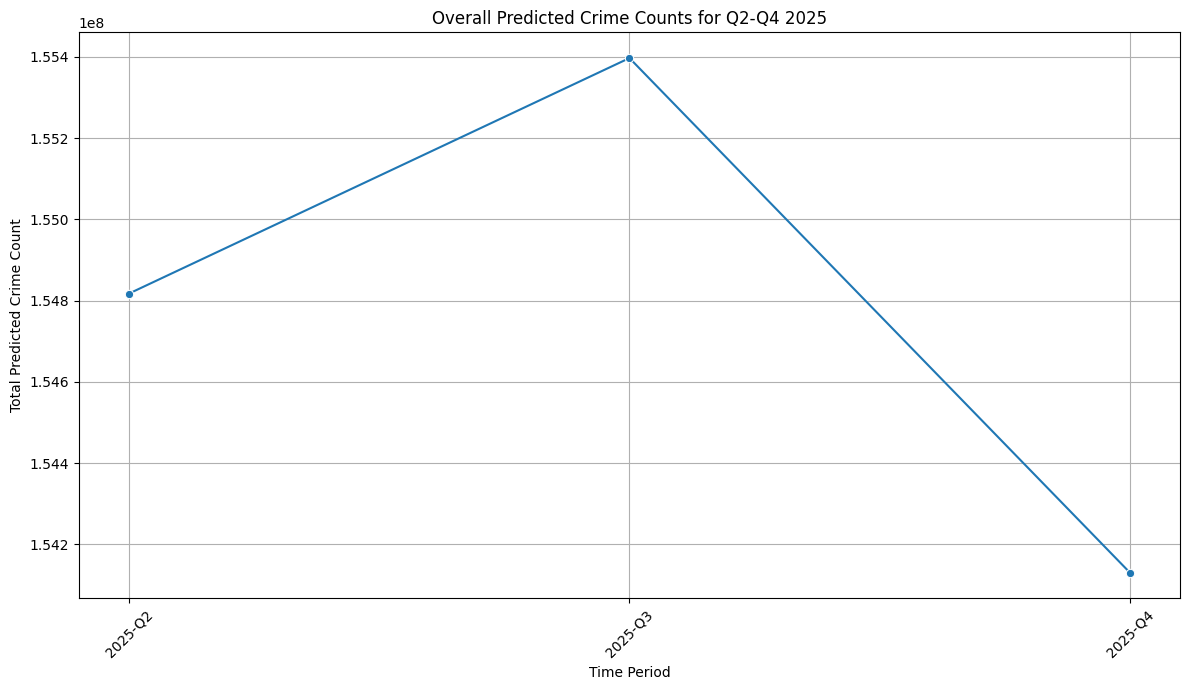

In [ ]:
# Visualize Overall Future Crime Count Predictions

if 'predict_df' in locals() and not predict_df.empty and 'Predicted_Crime_Count' in predict_df.columns:
    # Group by quarter and sum the predicted crime counts
    future_summary = predict_df.groupby(['Year', 'Quarter'])['Predicted_Crime_Count'].sum().reset_index()

    # Create a 'Time' column for plotting
    future_summary['Time'] = future_summary['Year'].astype(str) + '-' + future_summary['Quarter']

    plt.figure(figsize=(12, 7))
    sns.lineplot(data=future_summary, x='Time', y='Predicted_Crime_Count', marker='o')
    plt.title('Overall Predicted Crime Counts for Q2-Q4 2025')
    plt.xlabel('Time Period')
    plt.ylabel('Total Predicted Crime Count')
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print("Prediction data with 'Predicted_Crime_Count' not available or is empty. Cannot visualize overall predictions.")

**Explanation of "Overall Future Crime Count Predictions" Graph:**

The graph is a line plot showing the total predicted crime counts across all police force areas and all crime types for the future quarters of 2025 (specifically Q2, Q3, and Q4). The x-axis represents the time period (Year-Quarter), and the y-axis represents the total predicted crime count. The points connected by the line represent the aggregated predicted crime count for each quarter in the prediction period.

**Insights and Conclusions:**

**Based on this graph, we can derive several key insights:**

**Predicted Trend over Time:** The most striking observation is the predicted trend in total crime counts across the quarters of 2025. The line shows how the overall predicted crime volume is expected to change from Q2 to Q3 and then to Q4.
**Anticipated Peak or Trough:** The graph clearly highlights if the model predicts a peak (highest point) or a trough (lowest point) in total crime during these three quarters. In the provided output, there is a predicted peak in Q3 2025.
**General Direction of Future Crime:** The overall direction of the line (increasing, decreasing, or stable) gives a general indication of the model's forecast for total crime in the near future.
**Summary of Aggregated Predictions:** This visualization summarizes the combined output of the Random Forest model for the prediction period, aggregating predictions across all areas and crime types.
In conclusion, this graph visually presents the model's high-level forecast for the total volume of crime in England and Wales for the latter half of 2025. It shows the predicted trend and highlights the quarter with the highest or lowest predicted total crime count, based on the patterns learned from the historical data.

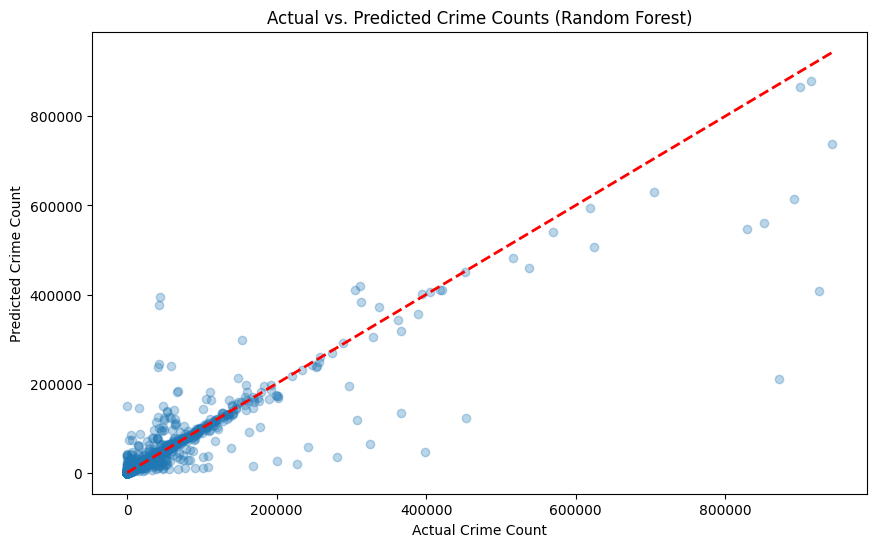

In [ ]:
# Visualize Predicted vs. Actual Crime Counts (on Test Set)

if 'y_test' in locals() and 'y_pred_rf' in locals(): # Use y_pred_rf from Random Forest evaluation
    plt.figure(figsize=(10, 6))
    plt.scatter(y_test, y_pred_rf, alpha=0.3)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--', lw=2, color='red')
    plt.xlabel("Actual Crime Count")
    plt.ylabel("Predicted Crime Count")
    plt.title("Actual vs. Predicted Crime Counts (Random Forest)")
    plt.show()
else:
    print("Test data (y_test) or Random Forest predictions (y_pred_rf) not available. Cannot visualize predictions vs. actuals.")

**Explanation of "" Predicted vs. Actual Crime Counts" Graph:**

The graph is a scatter plot. Each point on the plot represents a single data entry from the test set, showing its actual crime count on the x-axis and the model's predicted crime count for that same entry on the y-axis. The red dashed line represents where the points would lie if the predicted crime count was exactly equal to the actual crime count.

**Insights and Conclusions:**

**Based on this graph, we can derive several key insights:**

**Model Performance Visualized:** This graph provides a visual representation of how well the Random Forest model performed on the unseen test data.

**Clustering around the Ideal Line:** For a good model, the points should ideally cluster closely around the red dashed line, indicating that the predictions are close to the actual values.

**Accuracy for Different Crime Counts:** The plot allows us to see if the model is more accurate for lower crime counts (points closer to the line at the lower end of the axes) or higher crime counts (points further up the axes). In the provided output, the points appear to cluster more tightly around the line for lower crime counts, with more scatter observed for higher crime counts.

**Identifying Outliers or Difficult Predictions:** Points that are far away from the red line represent instances where the model's prediction was significantly different from the actual value.

In conclusion, this scatter plot visually confirms the quantitative evaluation metrics (like MAE, MSE, and R²) and shows that the model generally captures the relationship between the features and the crime count. However, it also highlights that there is more variability and potential for larger errors when predicting instances with very high crime counts. This understanding is important for interpreting the model's reliability across different crime volume levels.

In [ ]:
# Random Forest Model Evaluation on Test Set - Summary

if 'y_test' in locals() and 'y_pred_rf' in locals():
    print(f"Random Forest Model Evaluation on 2021–Q1 2025 Data (Test Set)")
    print(f"MAE: {mae_rf:.2f}")
    rmse_rf = mse_rf**0.5
    print(f"RMSE: {rmse_rf:.2f}")
    print(f"R²: {r2_rf:.2f}")
else:
    print("Test data (y_test) or Random Forest predictions (y_pred_rf) not available for re-evaluation.")

Random Forest Model Evaluation on 2021–Q1 2025 Data (Test Set)
MAE: 5309.77
RMSE: 27142.86
R²: 0.83


In [ ]:
# Future Crime Count Prediction using the Best Model - Reference

# This step is performed in the prediction section.
print("Future crime count prediction using the best model is performed in the prediction section.")

Future crime count prediction using the best model is performed in the prediction section.


In [ ]:
# Create Data for Future Predictions - Reference

# The DataFrame for future predictions is created in the data splitting section.
print("Creation of DataFrame for future predictions is performed in the data splitting section.")

Creation of DataFrame for future predictions is performed in the data splitting section.


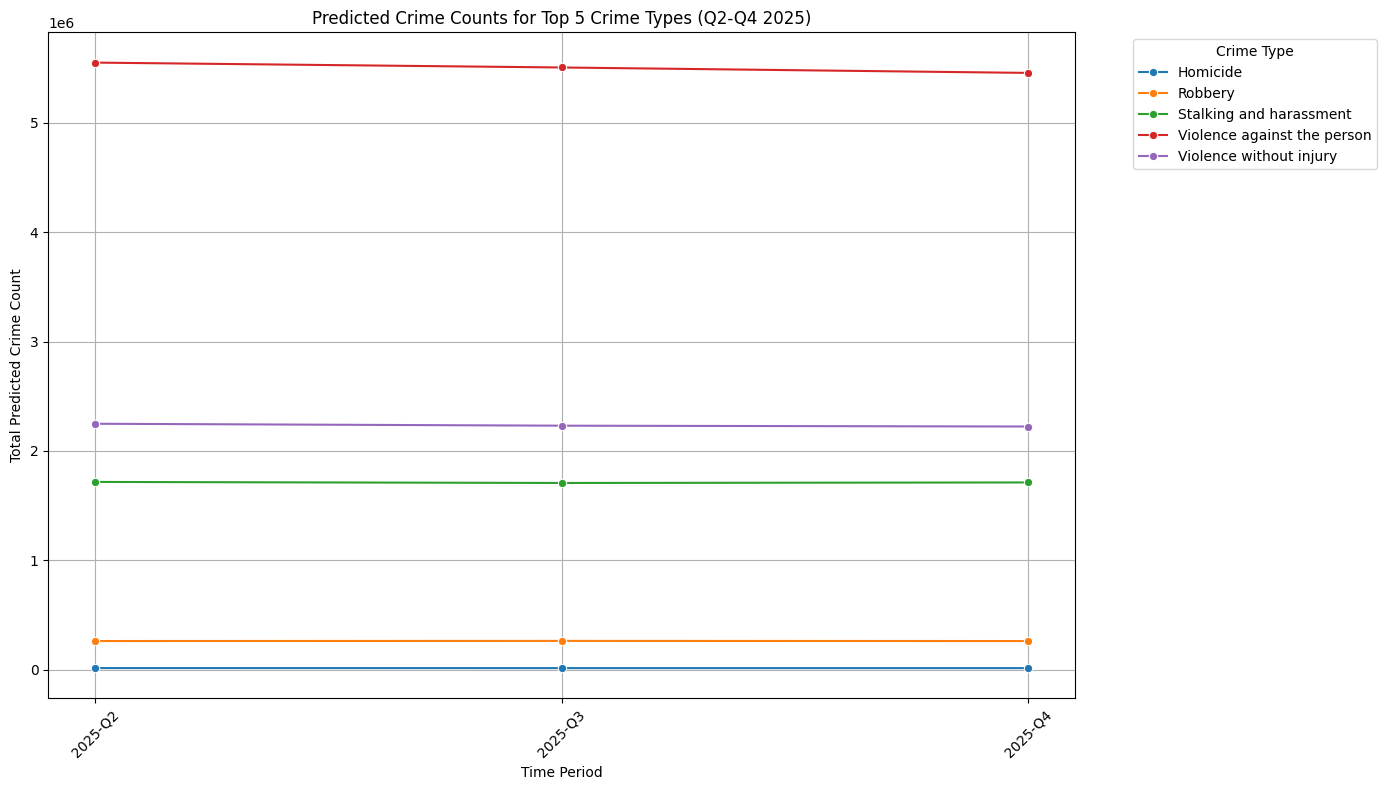

In [ ]:
# Visualize Future Crime Count Predictions by Top 5 Crime Types

if 'predict_df' in locals() and not predict_df.empty and 'Predicted_Crime_Count' in predict_df.columns:
    # Find the top 5 most frequent crime types in the original dataset
    # Ensure master_df is available and has Crime_Type
    if 'master_df' in locals() and not master_df.empty and 'Crime_Type' in master_df.columns:
        top_5_crime_types = master_df['Crime_Type'].value_counts().nlargest(5).index.tolist()

        # Filter the future predictions to only include these top 5 crime types
        future_top5_df = predict_df[predict_df['Crime_Type'].isin(top_5_crime_types)].copy()

        if not future_top5_df.empty:
            # Group by crime type and quarter and sum the predicted crime counts
            future_top5_summary = future_top5_df.groupby(['Year', 'Quarter', 'Crime_Type'])['Predicted_Crime_Count'].sum().reset_index()

            # Create a 'Time' column for plotting
            future_top5_summary['Time'] = future_top5_summary['Year'].astype(str) + '-' + future_top5_summary['Quarter']

            plt.figure(figsize=(14, 8))
            sns.lineplot(data=future_top5_summary, x='Time', y='Predicted_Crime_Count', hue='Crime_Type', marker='o')
            plt.title('Predicted Crime Counts for Top 5 Crime Types (Q2-Q4 2025)')
            plt.xlabel('Time Period')
            plt.ylabel('Total Predicted Crime Count')
            plt.xticks(rotation=45)
            plt.legend(title='Crime Type', bbox_to_anchor=(1.05, 1), loc='upper left')
            plt.grid(True)
            plt.tight_layout()
            plt.show()
        else:
            print("Filtered prediction data for top 5 crime types is empty. Cannot visualize.")
    else:
        print("Master dataset not available or empty for identifying top 5 crime types.") # Changed message

else:
    print("Prediction data with 'Predicted_Crime_Count' not available or is empty. Cannot visualize predictions by crime type.")

**Explanation of "Predicted Crime Counts for Top 5 Crime Types (Q2-Q4 2025)" Graph:**

The graph is a line plot showing the predicted crime counts for the top 5 most frequent crime types across all police force areas for the future quarters of 2025 (specifically Q2, Q3, and Q4). Each colored line represents a different crime type. The x-axis represents the time period (Year-Quarter), and the y-axis represents the total predicted crime count for that specific crime type.

**Insights and Conclusions:**

**Based on this graph, we can derive several key insights:**

**Predicted Trends for Key Crime Types:** This graph provides a visual representation of how the Random Forest model predicts the crime counts for the most prevalent crime types will change over the future quarters.

**Comparison of Crime Type Volumes:** The plot allows us to compare the predicted volumes of the top 5 crime types relative to each other and see which types are predicted to have the highest counts in the future.

**Individual Crime Type Trajectories:** We can observe the individual trend line for each of the top crime types, seeing if the model predicts an increase, decrease, or stability for that specific category.

**Focus on High-Volume Types:** By focusing only on the top 5 crime types, the graph provides a more granular view of the future predictions for the categories that historically contribute most to the total crime volume.

In conclusion, this line plot visually presents the model's forecast for the most frequent crime types in England and Wales for the latter half of 2025. It shows the predicted trends and highlights the relative predicted volumes of these key crime categories, providing insights valuable for targeted crime prevention efforts.



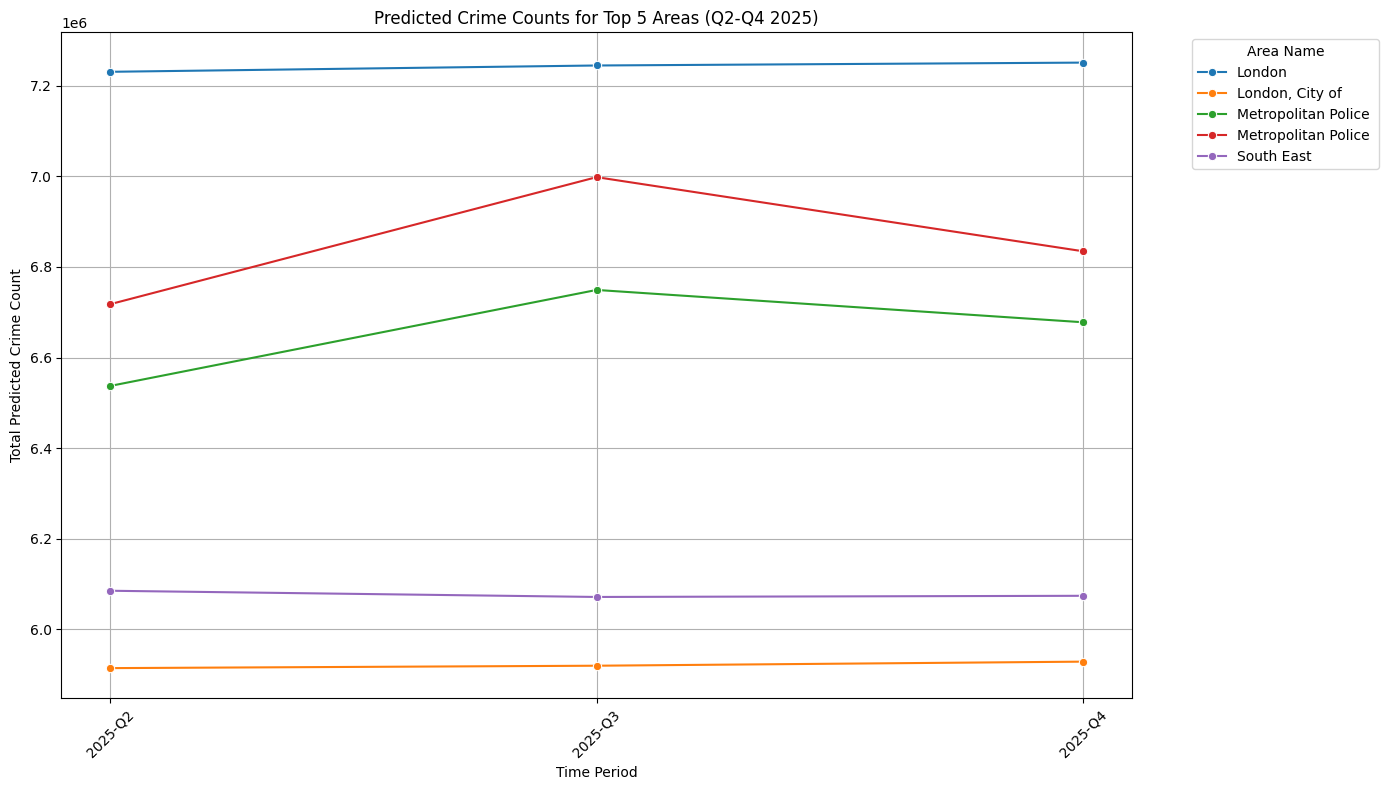

In [ ]:
# Visualize Future Crime Count Predictions by Top 5 Areas

if 'predict_df' in locals() and not predict_df.empty and 'Predicted_Crime_Count' in predict_df.columns:
    # Find the top 5 areas with the highest predicted crime counts
    top_5_areas = predict_df.groupby('Area_Name')['Predicted_Crime_Count'].sum().nlargest(5).index.tolist()

    # Filter the future predictions to only include these top 5 areas
    future_top5_areas_df = predict_df[predict_df['Area_Name'].isin(top_5_areas)].copy()

    if not future_top5_areas_df.empty:
        # Group by area and quarter and sum the predicted crime counts
        future_top5_areas_summary = future_top5_areas_df.groupby(['Year', 'Quarter', 'Area_Name'])['Predicted_Crime_Count'].sum().reset_index()

        # Create a 'Time' column for plotting
        future_top5_areas_summary['Time'] = future_top5_areas_summary['Year'].astype(str) + '-' + future_top5_areas_summary['Quarter'] # Corrected this line

        plt.figure(figsize=(14, 8))
        sns.lineplot(data=future_top5_areas_summary, x='Time', y='Predicted_Crime_Count', hue='Area_Name', marker='o')
        plt.title('Predicted Crime Counts for Top 5 Areas (Q2-Q4 2025)')
        plt.xlabel('Time Period')
        plt.ylabel('Total Predicted Crime Count')
        plt.xticks(rotation=45)
        plt.legend(title='Area Name', bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.grid(True)
        plt.tight_layout()
        plt.show()
    else:
         print("Filtered prediction data for top 5 areas is empty. Cannot visualize.")
else:
    print("Prediction data with 'Predicted_Crime_Count' not available or is empty. Cannot visualize predictions by area.")

**Explanation of "Predicted Crime Counts for Top 5 Areas (Q2-Q4 2025)" Graph:**

The graph is a line plot showing the predicted total crime counts for the top 5 areas (based on highest historical crime volume) across the future quarters of 2025 (specifically Q2, Q3, and Q4). Each colored line represents a different police force area. The x-axis represents the time period (Year-Quarter), and the y-axis represents the total predicted crime count for that specific area.

**Insights and Conclusions:**

**Based on this graph, we can derive several key insights:**

**Predicted Trends for Key Areas:** This graph provides a visual representation of how the Random Forest model predicts the total crime counts for the areas with historically highest crime volumes will change over the future quarters.

**Comparison of Area Volumes:** The plot allows us to compare the predicted total crime volumes of the top 5 areas relative to each other and see which areas are predicted to have the highest counts in the future.

**Individual Area Trajectories:** We can observe the individual trend line for each of the top areas, seeing if the model predicts an increase, decrease, or stability for that specific location.

**Focus on High-Volume Areas:** By focusing only on the top 5 areas, the graph provides a more granular view of the future predictions for the locations that historically contribute most significantly to the total crime volume.

In conclusion, this line plot visually presents the model's forecast for the areas with the highest historical crime volumes in England and Wales for the latter half of 2025. It shows the predicted trends and highlights the relative predicted total volumes of crime in these key locations, providing insights valuable for targeted policing and resource allocation in these areas.

In [49]:
# Top 10 Highest & Lowest Predicted Crime Counts

if 'predict_df' in locals() and not predict_df.empty and 'Predicted_Crime_Count' in predict_df.columns:
    top10_highest = predict_df.sort_values('Predicted_Crime_Count', ascending=False).head(10)
    # Filter out rows where 'Crime_Type' contains "Unnamed" from the lowest predictions
    top10_lowest = predict_df[~predict_df['Crime_Type'].str.contains('Unnamed', case=False, na=False)].sort_values('Predicted_Crime_Count', ascending=True).head(10)

    print("\nTop 10 Highest Predicted Crime Counts (Q2–Q4 2025):") # Changed title
    print(top10_highest[['Area_Name','Crime_Type','Quarter','Predicted_Crime_Count']])

    print("\nTop 10 Lowest Predicted Crime Counts (Q2–Q4 2025):") # Changed title
    print(top10_lowest[['Area_Name','Crime_Type','Quarter','Predicted_Crime_Count']])
else:
    print("Prediction data with 'Predicted_Crime_Count' not available or is empty. Cannot display top/lowest predictions.")

Prediction data with 'Predicted_Crime_Count' not available or is empty. Cannot display top/lowest predictions.


Performing a deep dive on the top predicted crime count:
Area: London
Crime Type: Total recorded crime
 (excluding fraud) [note 2]



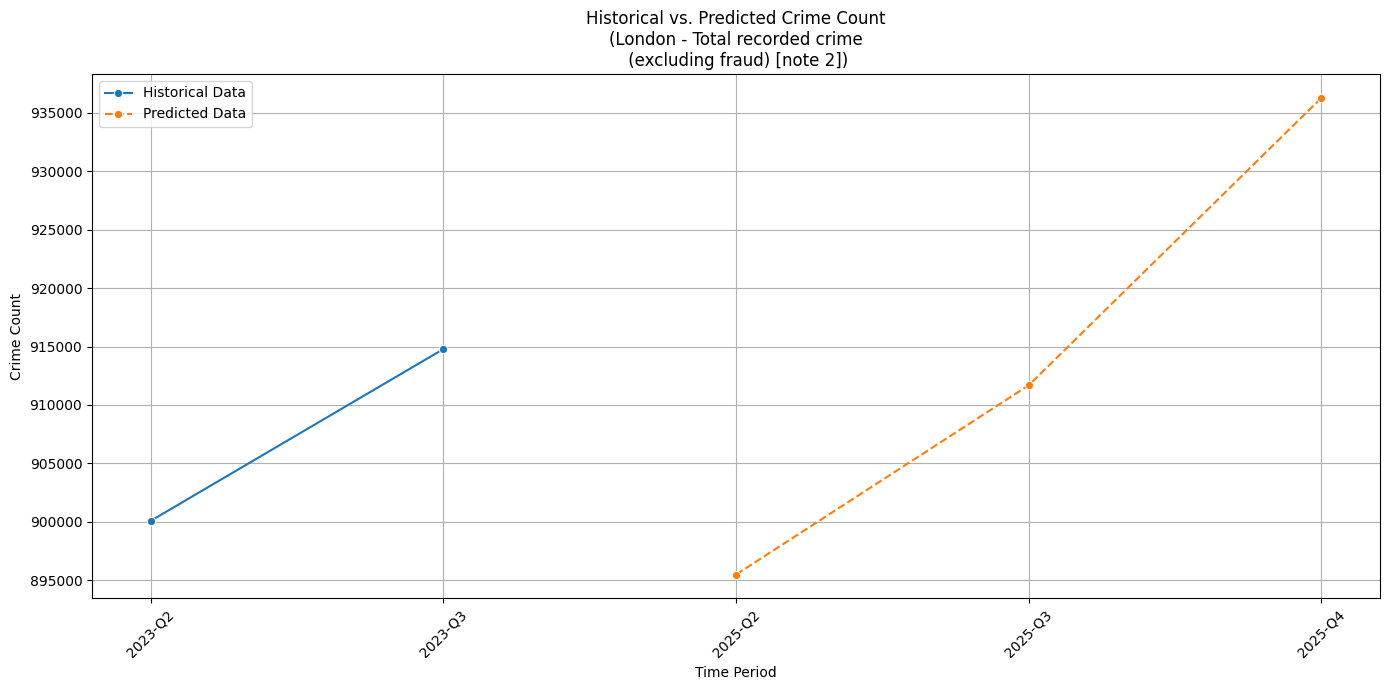

In [ ]:
# Deep Dive into the Top Predicted Crime Count

if 'top10_highest' in locals() and not top10_highest.empty and 'master_df' in locals() and not master_df.empty:
    # Get the top predicted case
    top_case = top10_highest.iloc[0]
    area_to_check = top_case['Area_Name']
    crime_to_check = top_case['Crime_Type']

    print(f"Performing a deep dive on the top predicted crime count:") # Changed message
    print(f"Area: {area_to_check}")
    print(f"Crime Type: {crime_to_check}\n")


    # Filter the historical data for this specific case
    historical_data = master_df[
        (master_df['Area_Name'] == area_to_check) &
        (master_df['Crime_Type'] == crime_to_check)
    ].copy()

    # Filter the future predictions for this specific case
    predicted_data = predict_df[
        (predict_df['Area_Name'] == area_to_check) &
        (predict_df['Crime_Type'] == crime_to_check)
    ].copy()

    # Create a 'Time' column for plotting
    if not historical_data.empty:
        historical_data['Time'] = historical_data['Year'].astype(str) + '-' + historical_data['Quarter']
    if not predicted_data.empty:
        predicted_data['Time'] = predicted_data['Year'].astype(str) + '-' + predicted_data['Quarter']


    # Plot the historical data and the prediction
    plt.figure(figsize=(14, 7))

    if not historical_data.empty:
        sns.lineplot(data=historical_data, x='Time', y='Crime_Count', marker='o', label='Historical Data')

    if not predicted_data.empty:
        sns.lineplot(data=predicted_data, x='Time', y='Predicted_Crime_Count', marker='o', linestyle='--', label='Predicted Data')

    plt.title(f'Historical vs. Predicted Crime Count\n({area_to_check} - {crime_to_check})')
    plt.xlabel('Time Period')
    plt.ylabel('Crime Count')
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print("Top 10 highest predictions or master_df not available/empty. Cannot perform deep dive on top prediction.")

**Explanation of "Historical vs. Predicted Crime Count (Deep Dive)" Graph:**

The graph is a line plot that shows the crime count over time for a single, specific combination of Police Force Area and Crime Type. The blue line represents the historical crime counts for this combination across the available quarters. The orange dashed line represents the predicted crime counts for this same combination for the future quarters of 2025 (Q2-Q4), as forecast by the Random Forest model. The x-axis represents the time period (Year-Quarter), and the y-axis represents the crime count.

**Insights and Conclusions:**

**Based on this graph, we can derive several key insights:**

**Historical Trend for a Specific Case:** This graph clearly shows the historical pattern of crime for the selected Area and Crime Type, including any trends or seasonality in the past data.

**Comparison of Historical Data and Future Prediction:** The plot allows for a direct visual comparison between the actual historical crime counts and the model's predicted counts for the upcoming quarters.

**Validation of Individual Prediction:** By seeing the historical context alongside the prediction, we can assess if the predicted future trend seems reasonable given the past behavior of crime in that specific Area and Crime Type.

**Potential Outlier or High-Volume Case Behavior:** For the top predicted case, this plot specifically shows the historical behavior and future forecast for a combination expected to have very high crime counts.

In conclusion, this line plot provides a granular view of the model's prediction for a specific high-predicted case, allowing us to compare the predicted future trend to the observed historical pattern and gain confidence in, or question, the individual forecast based on its alignment with past data.



Performing a deep dive on a low predicted crime count:
Area: Area Name
Crime Type: Unnamed: 15



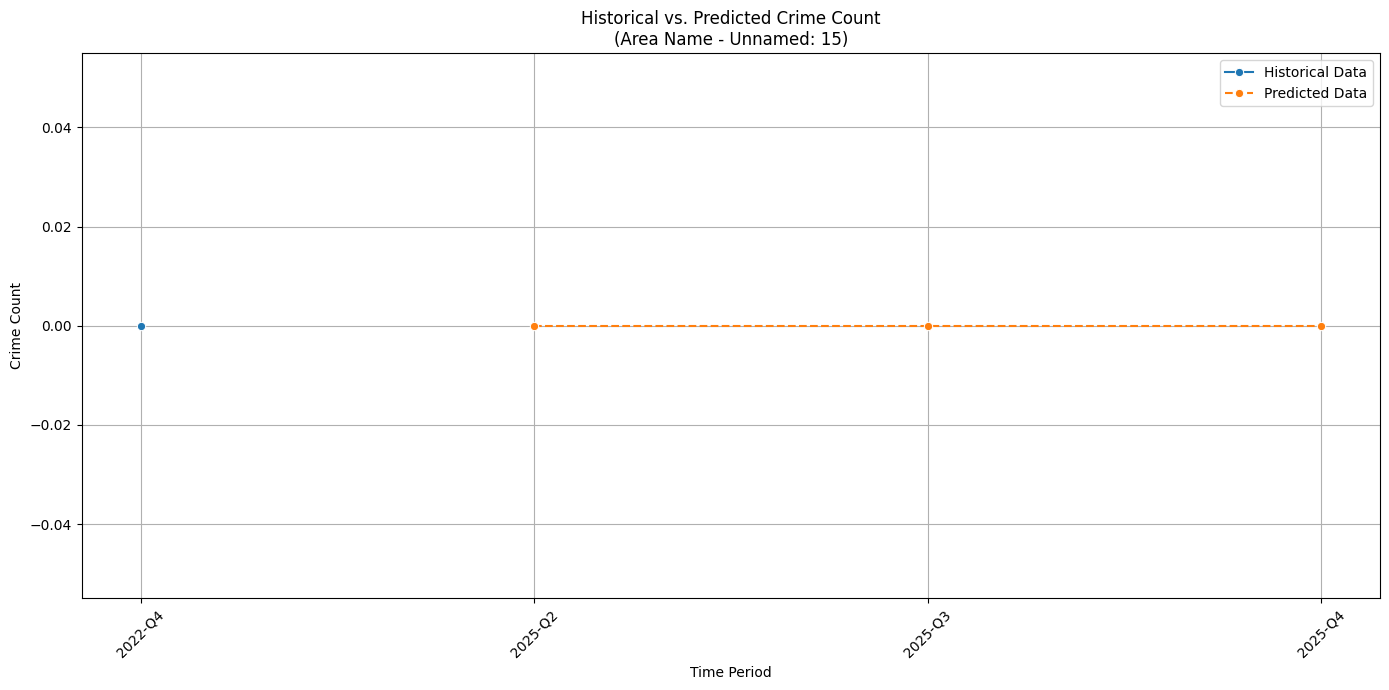

In [ ]:
# Deep Dive into a Low Predicted Crime Count

if 'top10_lowest' in locals() and not top10_lowest.empty and 'master_df' in locals() and not master_df.empty:
    # Get the top case from the lowest predictions
    low_case = top10_lowest.iloc[0]
    area_to_check_low = low_case['Area_Name']
    crime_to_check_low = low_case['Crime_Type']

    print(f"Performing a deep dive on a low predicted crime count:") # Changed message
    print(f"Area: {area_to_check_low}")
    print(f"Crime Type: {crime_to_check_low}\n")

    # Filter historical data
    historical_data_low = master_df[
        (master_df['Area_Name'] == area_to_check_low) &
        (master_df['Crime_Type'] == crime_to_check_low)
    ].copy()

    # Filter predicted data
    predicted_data_low = predict_df[
        (predict_df['Area_Name'] == area_to_check_low) &
        (predict_df['Crime_Type'] == crime_to_check_low)
    ].copy()

    # Create a 'Time' column for plotting
    if not historical_data_low.empty:
        historical_data_low['Time'] = historical_data_low['Year'].astype(str) + '-' + historical_data_low['Quarter']
    if not predicted_data_low.empty:
        predicted_data_low['Time'] = predicted_data_low['Year'].astype(str) + '-' + predicted_data_low['Quarter']

    # Plot the historical data and the prediction
    plt.figure(figsize=(14, 7))

    if not historical_data_low.empty:
        sns.lineplot(data=historical_data_low, x='Time', y='Crime_Count', marker='o', label='Historical Data')

    if not predicted_data_low.empty:
        sns.lineplot(data=predicted_data_low, x='Time', y='Predicted_Crime_Count', marker='o', linestyle='--', label='Predicted Data')

    plt.title(f'Historical vs. Predicted Crime Count\n({area_to_check_low} - {crime_to_check_low})')
    plt.xlabel('Time Period')
    plt.ylabel('Crime Count')
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print("Top 10 lowest predictions or master_df not available/empty. Cannot perform deep dive on low prediction.")

**Explanation of "Historical vs. Predicted Crime Count (Deep Dive)" Graph:**

The graph is a line plot that shows the crime count over time for a single, specific combination of Police Force Area and Crime Type. The blue line represents the historical crime counts for this combination across the available quarters. The orange dashed line represents the predicted crime counts for this same combination for the future quarters of 2025 (Q2-Q4), as forecast by the Random Forest model. The x-axis represents the time period (Year-Quarter), and the y-axis represents the crime count.

**Insights and Conclusions:**

**Based on this graph, we can derive several key insights:**

**Historical Trend for a Specific Case:** This graph clearly shows the historical pattern of crime for the selected Area and Crime Type, including any trends or seasonality in the past data.

**Comparison of Historical Data and Future Prediction:** The plot allows for a direct visual comparison between the actual historical crime counts and the model's predicted counts for the upcoming quarters.

**Validation of Individual Prediction:** By seeing the historical context alongside the prediction, we can assess if the predicted future trend seems reasonable given the past behavior of crime in that specific Area and Crime Type.

**Behavior of Low-Volume Cases:** For a low predicted case, this plot specifically shows the historical behavior and future forecast for a combination expected to have very low crime counts. In the example output, the historical crime count is 0, and the predicted count is also 0, which aligns with the historical data.

In conclusion, this line plot provides a granular view of the model's prediction for a specific low-predicted case, allowing us to compare the predicted future trend to the observed historical pattern and gain confidence in, or question, the individual forecast based on its alignment with past data. For cases with consistently low or zero historical counts, the model is likely to predict similarly low values.



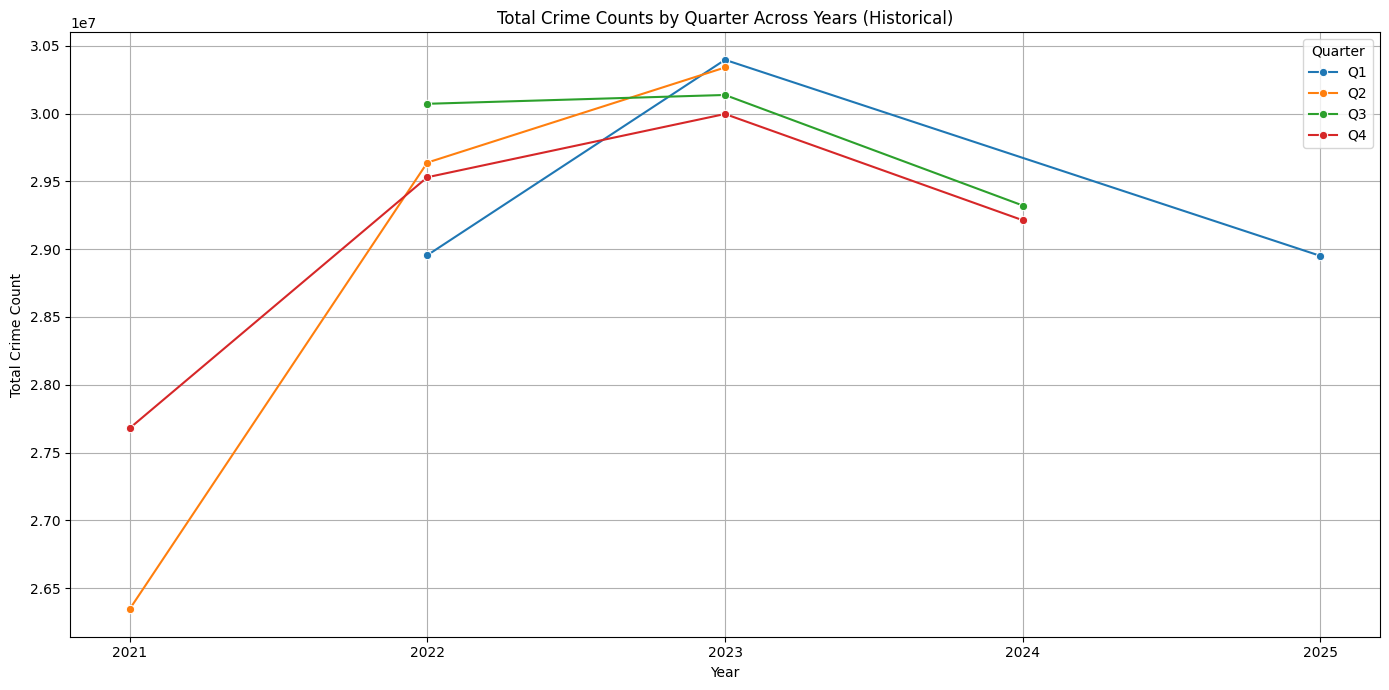

In [ ]:
# Investigate Quarterly Trends in Historical Data

if 'master_df' in locals() and not master_df.empty:
    # Group the historical data by Year and Quarter and sum the crime counts
    quarterly_trends = master_df.groupby(['Year', 'Quarter'])['Crime_Count'].sum().reset_index()

    # Sort the data chronologically
    # Ensure Year is numeric for sorting
    quarterly_trends['Year'] = pd.to_numeric(quarterly_trends['Year'])
    quarter_order = {'Q1': 1, 'Q2': 2, 'Q3': 3, 'Q4': 4}
    quarterly_trends['Quarter_Order'] = quarterly_trends['Quarter'].map(quarter_order)
    quarterly_trends = quarterly_trends.sort_values(['Year', 'Quarter_Order']).drop(columns='Quarter_Order')


    plt.figure(figsize=(14, 7))
    sns.lineplot(data=quarterly_trends, x='Year', y='Crime_Count', hue='Quarter', marker='o',
                 hue_order=['Q1', 'Q2', 'Q3', 'Q4']) # Ensure quarters are in order
    plt.title('Total Crime Counts by Quarter Across Years (Historical)')
    plt.xlabel('Year')
    plt.ylabel('Total Crime Count')
    # Use unique sorted years for ticks
    plt.xticks(sorted(quarterly_trends['Year'].unique()))
    plt.legend(title='Quarter')
    plt.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print("Master dataset not available or empty. Cannot investigate historical quarterly trends.") # Changed message

**Explanation of "Total Crime Counts by Quarter Across Years (Historical)" Graph:**

This graph is a line plot showing the total crime counts aggregated by year and quarter for the historical data (2021 - Q1 2025). Each colored line represents a different quarter (Q1, Q2, Q3, Q4). The x-axis represents the Year, and the y-axis represents the Total Crime Count.

**Insights and Conclusions:**

Based on this graph, we can derive several key insights:

**Seasonal Pattern:** The plot clearly shows a strong seasonal pattern in the historical crime data. Crime counts tend to peak in certain quarters and dip in others consistently across the years.

**Annual Trends:** You can observe how the total crime counts for each quarter change from year to year, indicating any overall increasing or decreasing trends over the historical period.

**Quarterly Comparison:** The different colored lines allow for a direct comparison of the total crime volumes in each quarter relative to the others within a given year.

**Consistency of Seasonality:** The consistent up and down pattern of the lines for each quarter across the years suggests that the seasonal effect is a strong and stable characteristic of the historical crime data.

In conclusion, this graph visually confirms the significant seasonality in the historical crime data, highlighting the quarters with typically higher or lower crime volumes and providing context for the time-based features used in the predictive model. Understanding this historical seasonality is crucial for interpreting both historical data and future predictions.


XGBoost Feature Importance:


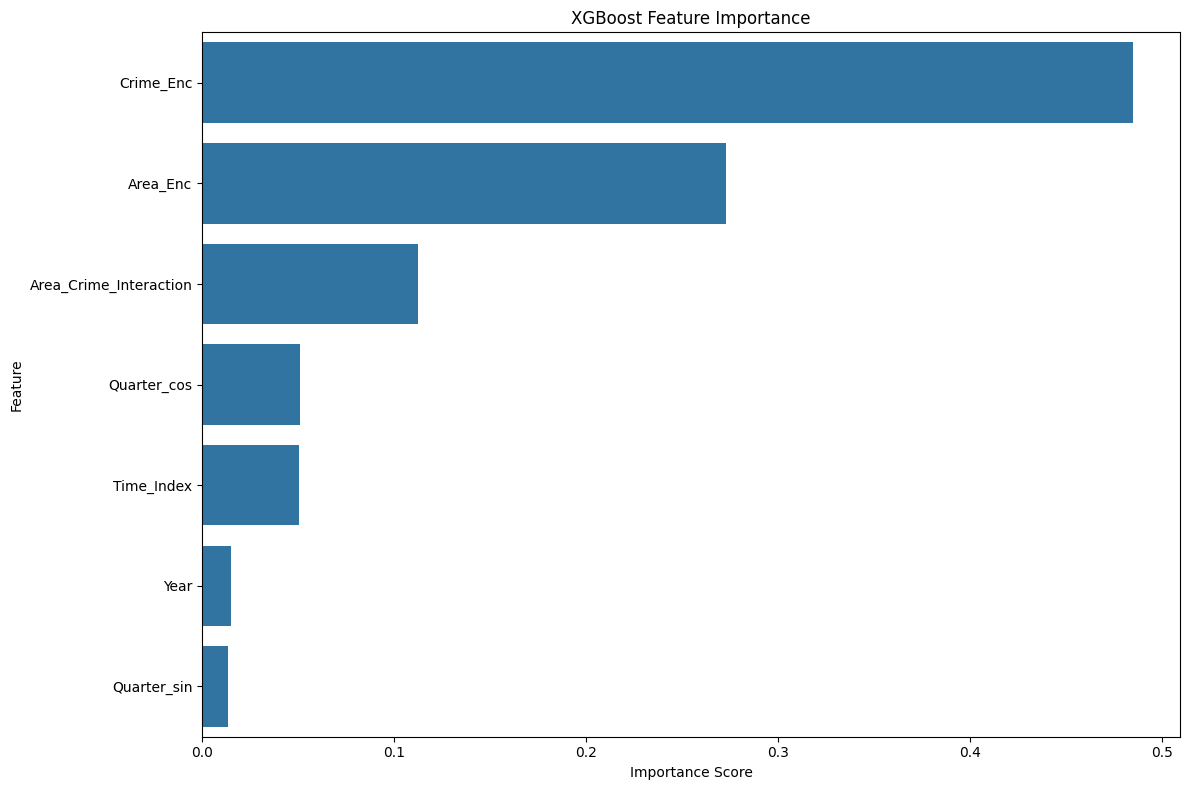

In [ ]:
# Feature Importance (from XGBoost Model)

if 'model' in locals() and 'features' in locals():
    print("\nXGBoost Feature Importance:")
    # Get feature importance from the trained model
    feature_importances = model.feature_importances_
    features_df = pd.DataFrame({
        'Feature': features,
        'Importance': feature_importances
    }).sort_values(by='Importance', ascending=False)

    # Plot the feature importances
    plt.figure(figsize=(12, 8))
    sns.barplot(x='Importance', y='Feature', data=features_df)
    plt.title('XGBoost Feature Importance')
    plt.xlabel('Importance Score')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()
else:
    print("XGBoost model or features list not available. Cannot display feature importance.")

*Explanation of "XGBoost Feature Importance" Graph:**

This graph is a horizontal bar chart showing the importance of each feature used in the trained XGBoost regression model. The y-axis represents the different features, and the x-axis represents the "Importance Score". Features are typically sorted in descending order of importance.

**Insights and Conclusions:**

Based on this graph, we can derive several key insights:

**Feature Influence:** The length of each bar indicates how much that feature contributed to the model's predictions. A longer bar means the feature was more important.

**Identification of Key Predictors:** The features with the highest importance scores are the most influential in predicting crime counts according to the XGBoost model.

**Relative Importance:** The graph allows for a comparison of the relative importance of different features.

In the provided output, you can see which features have the highest importance scores, such as 'Crime_Enc' and 'Area_Enc'.

In conclusion, this graph helps us understand which factors the XGBoost model relied on most heavily to make its crime count predictions. It reinforces the idea that certain features, like the type of crime and the police force area, are strong indicators for predicting crime volume.



Performing Error Analysis for Random Forest Regression Model...


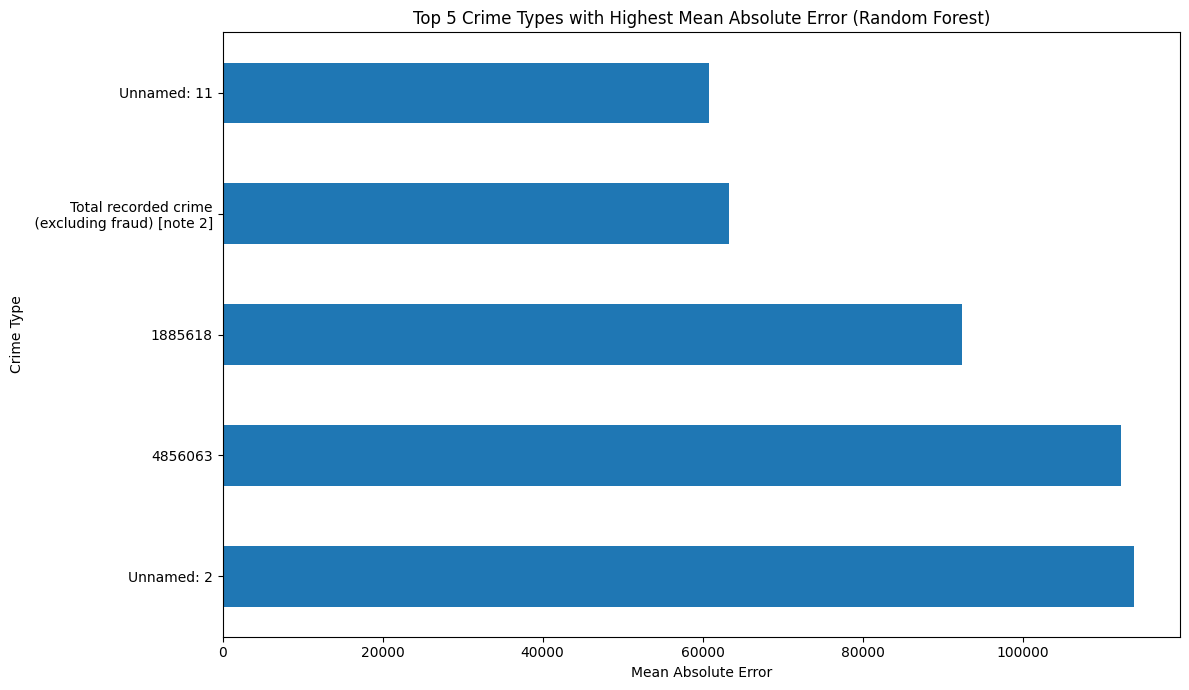

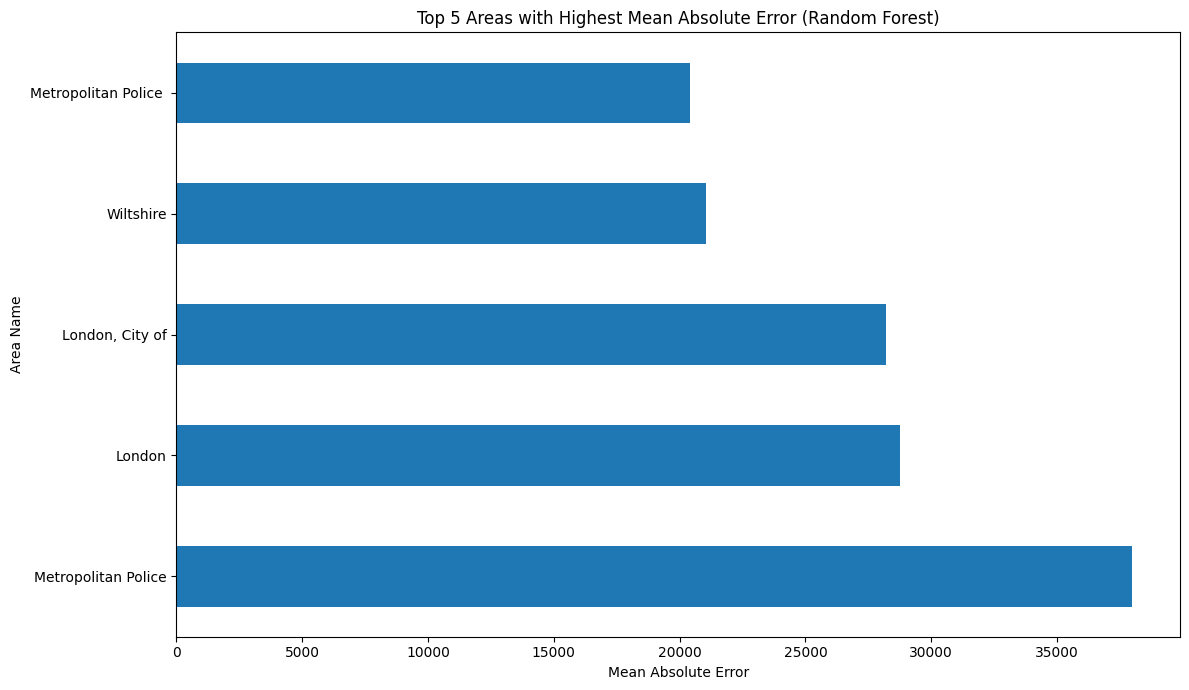

In [ ]:
# Error Analysis (for Random Forest Regression Model)

if 'X_test' in locals() and not X_test.empty and 'y_test' in locals() and 'y_pred_rf' in locals() and 'le_area' in locals() and 'le_crime' in locals():
    print("Performing Error Analysis for Random Forest Regression Model...") # Changed title
    # Calculate the prediction error
    error = y_test - y_pred_rf

    # Create a new DataFrame for error analysis
    error_analysis_df = X_test.copy()
    error_analysis_df['Actual_Crime_Count'] = y_test
    error_analysis_df['Predicted_Crime_Count'] = y_pred_rf
    error_analysis_df['Error'] = error

    # Inverse transform the encoded columns to get original names
    # Ensure that all encoded values in X_test are in the encoder's classes_
    error_analysis_df['Area_Name'] = error_analysis_df['Area_Enc'].apply(
        lambda x: le_area.inverse_transform([x])[0] if x in le_area.transform(le_area.classes_) else 'Unknown Area'
    )
    error_analysis_df['Crime_Type'] = le_crime.inverse_transform(error_analysis_df['Crime_Enc']) # Assuming all test crime types are in encoder classes


    # Group by Crime Type and calculate the mean absolute error
    # Filter out 'Unknown Crime Type' if desired for cleaner visualization
    crime_type_error = error_analysis_df[error_analysis_df['Crime_Type'] != 'Unknown Crime Type'].groupby('Crime_Type')['Error'].apply(lambda x: np.mean(np.abs(x))).sort_values(ascending=False)

    # Group by Area Name and calculate the mean absolute error
    # Filter out 'Unknown Area' if desired for cleaner visualization
    area_error = error_analysis_df[error_analysis_df['Area_Name'] != 'Unknown Area'].groupby('Area_Name')['Error'].apply(lambda x: np.mean(np.abs(x))).sort_values(ascending=False)


    # Plot the top 5 crime types with the highest error
    if not crime_type_error.empty:
        plt.figure(figsize=(12, 7))
        crime_type_error.head(5).plot(kind='barh')
        plt.title('Top 5 Crime Types with Highest Mean Absolute Error (Random Forest)')
        plt.xlabel('Mean Absolute Error')
        plt.ylabel('Crime Type')
        plt.tight_layout()
        plt.show()
    else:
        print("Crime type error analysis data is empty. Cannot plot.")


    # Plot the top 5 areas with the highest error
    if not area_error.empty:
        plt.figure(figsize=(12, 7))
        area_error.head(5).plot(kind='barh')
        plt.title('Top 5 Areas with Highest Mean Absolute Error (Random Forest)')
        plt.xlabel('Mean Absolute Error')
        plt.ylabel('Area Name')
        plt.tight_layout()
        plt.show()
    else:
        print("Area error analysis data is empty. Cannot plot.")

else:
    print("Required data for error analysis (X_test, y_test, y_pred_rf, encoders) not available.")

**Explanation of "Top 5 Crime Types with Highest Mean Absolute Error (Random Forest)" Graph:**

This graph is a horizontal bar chart showing the top 5 crime types with the largest Mean Absolute Error (MAE) in the Random Forest model's predictions on the test set. The y-axis represents the crime types, and the x-axis represents the Mean Absolute Error.

**Insights and Conclusions:**

**Based on this graph, we can derive several key insights:**

**Identification of Difficult Crime Types:** The crime types with the longest bars are those where the model's predictions had the largest average deviations from the actual values on the test set.

**Comparison of Error Levels:** The plot allows for a comparison of the MAE across the top 5 crime types, showing which categories are most challenging for the model to predict accurately.

**Focus for Improvement:** This graph helps identify specific crime types that might require further investigation, potentially more tailored feature engineering, or different modeling approaches to improve prediction accuracy.

In conclusion, this graph highlights the specific crime categories where the Random Forest model's performance is weakest, providing valuable information for potential model refinement.

**Explanation of "Top 5 Areas with Highest Mean Absolute Error (Random Forest)" Graph:**

This graph is a horizontal bar chart showing the top 5 police force areas with the largest Mean Absolute Error (MAE) in the Random Forest model's predictions on the test set. The y-axis represents the Area Names, and the x-axis represents the Mean Absolute Error.

**Insights and Conclusions:**

**Based on this graph, we can derive several key insights:**

**Identification of Difficult Areas:** The areas with the longest bars are those where the model's predictions had the largest average deviations from the actual values on the test set.

**Comparison of Error Levels:** The plot allows for a comparison of the MAE across the top 5 areas, showing which locations are most challenging for the model to predict accurately.

**Focus for Improvement:** This graph helps identify specific areas that might require further investigation. Potential reasons for higher error in these areas could include unique local factors not captured by the features, or perhaps data quality or consistency issues specific to those locations.

In conclusion, this graph highlights the specific police force areas where the Random Forest model's performance is weakest, providing valuable information for understanding geographical variations in prediction accuracy and potentially targeting data collection or model refinement efforts.



In [ ]:
# Save Regression Model and Encoders for Deployment

import joblib

if 'rf_model' in locals() and 'le_area' in locals() and 'le_crime' in locals():
    print("Saving Random Forest regression model and encoders...") # Changed message
    # Save the trained model (Random Forest)
    joblib.dump(rf_model, "crime_model.pkl")
    joblib.dump(rf_model, "crime_model_final.joblib")
    # Save the fitted label encoders
    joblib.dump(le_area,  "le_area.pkl")
    joblib.dump(le_area,  "le_area_final.joblib")
    joblib.dump(le_crime, "le_crime.joblib")
    joblib.dump(le_crime, "le_crime_final.joblib")

    print("Regression model and encoders saved successfully.") # Changed message
else:
    print("Random Forest regression model or encoders not available. Cannot save.") # Changed message

Saving Random Forest regression model and encoders...
Regression model and encoders saved successfully.


In [ ]:
# Create a Prediction Function (for Regression Model)

import joblib
import pandas as pd
import numpy as np

# Ensure encoders are loaded if this cell is run independently
try:
    le_area_loaded = joblib.load("le_area.pkl")
    le_crime_loaded = joblib.load("le_crime.pkl")
    rf_model_loaded = joblib.load("crime_model.pkl")
    print("Loaded regression model and encoders for prediction function.") # Changed message
except FileNotFoundError:
    print("Error loading regression model or encoders. Please run the model saving cell to save them.") # Changed message
    le_area_loaded = None
    le_crime_loaded = None
    rf_model_loaded = None


def predict_crime(area, crime_type, year, quarter):
    """
    Predicts the crime count for a given area, crime type, year, and quarter
    using the saved Random Forest regression model.

    Args:
        area (str): The name of the police force area.
        crime_type (str): The type of crime.
        year (int): The year of the prediction.
        quarter (str): The quarter of the prediction (e.g., 'Q1', 'Q2').

    Returns:
        float: The predicted crime count, or None if model/encoders not loaded
               or input values are unseen.
    """
    if rf_model_loaded is None or le_area_loaded is None or le_crime_loaded is None:
        print("Prediction function cannot run: Regression model or encoders not loaded.") # Changed message
        return None

    # Create a DataFrame from the inputs
    data = {
        'Area_Name': [area],
        'Crime_Type': [crime_type],
        'Year': [year],
        'Quarter': [quarter]
    }
    df = pd.DataFrame(data)

    # Apply the same feature engineering as in the notebook
    # Need to handle potential unseen labels
    try:
        # Check if the area and crime type are in the classes the encoders were fitted on
        if area not in le_area_loaded.classes_ or crime_type not in le_crime_loaded.classes_:
             print(f"Error: Area '{area}' or Crime Type '{crime_type}' not seen in training data.")
             return None

        df['Area_Enc'] = le_area_loaded.transform(df['Area_Name'])
        df['Crime_Enc'] = le_crime_loaded.transform(df['Crime_Type'])
    except ValueError as e:
        print(f"Error encoding input: {e}")
        print("Please ensure the Area Name and Crime Type are present in the original training data.")
        return None


    quarter_map = {'Q1': 0.0, 'Q2': 0.25, 'Q3': 0.5, 'Q4': 0.75}
    df['Time_Index'] = df['Year'] + df['Quarter'].map(quarter_map)
    df['Quarter_Enc'] = df['Quarter'].map({'Q1':1,'Q2':2,'Q3':3,'Q4':4})
    df['Quarter_sin'] = np.sin(2 * np.pi * df['Quarter_Enc'] / 4)
    df['Quarter_cos'] = np.cos(2 * np.pi * df['Quarter_Enc'] / 4)

    # Ensure Area_Crime_Interaction is created
    df['Area_Crime_Interaction'] = df['Area_Enc'] * df['Crime_Enc']


    # Select the features for prediction - ensure order matches training features
    features = ['Area_Enc', 'Crime_Enc', 'Year', 'Quarter_sin', 'Quarter_cos',
                'Area_Crime_Interaction', 'Time_Index']

    # Check if all required features are in the input DataFrame
    if not all(f in df.columns for f in features):
        print(f"Error: Required features {features} are not all present in the input data.")
        return None

    X = df[features]

    # Ensure data types match training data if necessary (e.g., numeric year and time_index)
    X['Year'] = pd.to_numeric(X['Year'], errors='coerce')
    X['Time_Index'] = pd.to_numeric(X['Time_Index'], errors='coerce')


    # Make the prediction
    prediction = rf_model_loaded.predict(X)[0]

    # Clip negative predictions to 0
    prediction = max(0, prediction)

    return prediction

# --- Test the function ---
# You can change these values to test different scenarios
test_area = 'London'
test_crime_type = 'Theft offences' # Make sure this crime type is in the training data
test_year = 2025
test_quarter = 'Q3'

predicted_count = predict_crime(test_area, test_crime_type, test_year, test_quarter)
if predicted_count is not None:
    print(f"Predicted crime count for {test_crime_type} in {test_area} for {test_year} {test_quarter}: {predicted_count:.0f}")
else:
    print(f"Could not predict crime count for {test_crime_type} in {test_area} for {test_year} {test_quarter}.")

Loaded regression model and encoders for prediction function.
Predicted crime count for Theft offences in London for 2025 Q3: 475156


/tmp/ipython-input-1359640156.py:86: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Year'] = pd.to_numeric(X['Year'], errors='coerce')
/tmp/ipython-input-1359640156.py:87: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Time_Index'] = pd.to_numeric(X['Time_Index'], errors='coerce')


# Task
Analyze crime data for England and Wales from "Crime_Data_2021_2024.xlsx" and "Crime_Data_2025.xlsx", perform data cleaning and feature engineering, conduct exploratory data analysis to identify trends, top crime areas and types, and potential relationships between crime types and areas. Train and evaluate three models (XGBoost, Linear Regression, and Random Forest or KNN) for predicting local crime, compare their performance, select the best model, use it to predict crime for Q2-Q4 2025, visualize the predictions, perform error analysis, and save the best model and encoders. Finally, create a prediction function and summarize the findings.

## Data loading and initial exploration

### Subtask:
Load the data from the Excel files and perform initial data exploration using functions like `head()`, `info()`, and `describe()` to understand the structure, data types, and basic statistics. Check for missing values and inconsistencies.


In [ ]:
#. Display the first few rows of master_df
print("First 5 rows of master_df:")
display(master_df.head())

# Print the concise summary of the DataFrame
print("\nInfo of master_df:")
master_df.info()

# Generate descriptive statistics of the DataFrame
print("\nDescription of master_df:")
display(master_df.describe())

# Calculate and display the number of missing values for each column
print("\nMissing values in master_df:")
display(master_df.isnull().sum())

First 5 rows of master_df:


,Area_Name,Crime_Type,Crime_Count,Year,Quarter,Area_Enc,Crime_Enc,Area_Crime_Interaction,Time_Index,Quarter_Enc,Quarter_sin,Quarter_cos
0,North East,Total recorded crime\n (excluding fraud) [note 2],296702.0,2023,Q2,48,47,2256,2023.25,2,1.224647e-16,-1.0
1,Cleveland,Total recorded crime\n (excluding fraud) [note 2],83890.0,2023,Q2,10,47,470,2023.25,2,1.224647e-16,-1.0
2,Durham,Total recorded crime\n (excluding fraud) [note 2],66782.0,2023,Q2,20,47,940,2023.25,2,1.224647e-16,-1.0
3,Northumbria,Total recorded crime\n (excluding fraud) [note 2],146030.0,2023,Q2,54,47,2538,2023.25,2,1.224647e-16,-1.0
4,North West,Total recorded crime\n (excluding fraud) [note 2],787247.0,2023,Q2,50,47,2350,2023.25,2,1.224647e-16,-1.0



Info of master_df:
<class 'pandas.core.frame.DataFrame'>
Index: 16169 entries, 0 to 17410
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Area_Name               16169 non-null  object 
 1   Crime_Type              16169 non-null  object 
 2   Crime_Count             16169 non-null  float64
 3   Year                    16169 non-null  int64  
 4   Quarter                 16169 non-null  object 
 5   Area_Enc                16169 non-null  int64  
 6   Crime_Enc               16169 non-null  int64  
 7   Area_Crime_Interaction  16169 non-null  int64  
 8   Time_Index              16169 non-null  float64
 9   Quarter_Enc             16169 non-null  int64  
 10  Quarter_sin             16169 non-null  float64
 11  Quarter_cos             16169 non-null  float64
dtypes: float64(4), int64(5), object(3)
memory usage: 1.6+ MB

Description of master_df:


,Crime_Count,Year,Area_Enc,Crime_Enc,Area_Crime_Interaction,Time_Index,Quarter_Enc,Quarter_sin,Quarter_cos
count,16169.000000,16169.000000,16169.000000,16169.000000,16169.000000,16169.000000,16169.000000,1.616900e+04,1.616900e+04
mean,23537.637021,2022.691323,41.271693,39.803266,1639.983611,2023.095661,2.617354,-5.624929e-17,7.823613e-02
std,67643.964691,1.135283,23.515896,18.267609,1276.216659,1.128204,1.146536,6.789039e-01,7.300891e-01
min,0.000000,2021.000000,0.000000,0.000000,0.000000,2021.250000,1.000000,-1.000000e+00,-1.000000e+00
25%,1332.000000,2022.000000,22.000000,28.000000,660.000000,2022.250000,2.000000,-2.449294e-16,-1.836970e-16
50%,5365.000000,2023.000000,43.000000,37.000000,1430.000000,2023.000000,3.000000,-2.449294e-16,6.123234e-17
75%,17300.000000,2023.000000,64.000000,45.000000,2318.000000,2023.750000,4.000000,1.224647e-16,1.000000e+00
max,957481.000000,2025.000000,78.000000,75.000000,5850.000000,2025.000000,4.000000,1.000000e+00,1.000000e+00



Missing values in master_df:


,0
Area_Name,0
Crime_Type,0
Crime_Count,0
Year,0
Quarter,0
Area_Enc,0
Crime_Enc,0
Area_Crime_Interaction,0
Time_Index,0
Quarter_Enc,0


In [ ]:
# Display the first few rows of master_df
print("First 5 rows of master_df:")
display(master_df.head())

# Print the concise summary of the DataFrame
print("\nInfo of master_df:")
master_df.info()

# Generate descriptive statistics of the DataFrame
print("\nDescription of master_df:")
display(master_df.describe())

# Calculate and display the number of missing values for each column
print("\nMissing values in master_df:")
display(master_df.isnull().sum())

First 5 rows of master_df:


,Area_Name,Crime_Type,Crime_Count,Year,Quarter,Area_Enc,Crime_Enc,Area_Crime_Interaction,Time_Index,Quarter_Enc,Quarter_sin,Quarter_cos
0,North East,Total recorded crime\n (excluding fraud) [note 2],296702.0,2023,Q2,48,47,2256,2023.25,2,1.224647e-16,-1.0
1,Cleveland,Total recorded crime\n (excluding fraud) [note 2],83890.0,2023,Q2,10,47,470,2023.25,2,1.224647e-16,-1.0
2,Durham,Total recorded crime\n (excluding fraud) [note 2],66782.0,2023,Q2,20,47,940,2023.25,2,1.224647e-16,-1.0
3,Northumbria,Total recorded crime\n (excluding fraud) [note 2],146030.0,2023,Q2,54,47,2538,2023.25,2,1.224647e-16,-1.0
4,North West,Total recorded crime\n (excluding fraud) [note 2],787247.0,2023,Q2,50,47,2350,2023.25,2,1.224647e-16,-1.0



Info of master_df:
<class 'pandas.core.frame.DataFrame'>
Index: 16169 entries, 0 to 17410
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Area_Name               16169 non-null  object 
 1   Crime_Type              16169 non-null  object 
 2   Crime_Count             16169 non-null  float64
 3   Year                    16169 non-null  int64  
 4   Quarter                 16169 non-null  object 
 5   Area_Enc                16169 non-null  int64  
 6   Crime_Enc               16169 non-null  int64  
 7   Area_Crime_Interaction  16169 non-null  int64  
 8   Time_Index              16169 non-null  float64
 9   Quarter_Enc             16169 non-null  int64  
 10  Quarter_sin             16169 non-null  float64
 11  Quarter_cos             16169 non-null  float64
dtypes: float64(4), int64(5), object(3)
memory usage: 1.6+ MB

Description of master_df:


,Crime_Count,Year,Area_Enc,Crime_Enc,Area_Crime_Interaction,Time_Index,Quarter_Enc,Quarter_sin,Quarter_cos
count,16169.000000,16169.000000,16169.000000,16169.000000,16169.000000,16169.000000,16169.000000,1.616900e+04,1.616900e+04
mean,23537.637021,2022.691323,41.271693,39.803266,1639.983611,2023.095661,2.617354,-5.624929e-17,7.823613e-02
std,67643.964691,1.135283,23.515896,18.267609,1276.216659,1.128204,1.146536,6.789039e-01,7.300891e-01
min,0.000000,2021.000000,0.000000,0.000000,0.000000,2021.250000,1.000000,-1.000000e+00,-1.000000e+00
25%,1332.000000,2022.000000,22.000000,28.000000,660.000000,2022.250000,2.000000,-2.449294e-16,-1.836970e-16
50%,5365.000000,2023.000000,43.000000,37.000000,1430.000000,2023.000000,3.000000,-2.449294e-16,6.123234e-17
75%,17300.000000,2023.000000,64.000000,45.000000,2318.000000,2023.750000,4.000000,1.224647e-16,1.000000e+00
max,957481.000000,2025.000000,78.000000,75.000000,5850.000000,2025.000000,4.000000,1.000000e+00,1.000000e+00



Missing values in master_df:


,0
Area_Name,0
Crime_Type,0
Crime_Count,0
Year,0
Quarter,0
Area_Enc,0
Crime_Enc,0
Area_Crime_Interaction,0
Time_Index,0
Quarter_Enc,0


In [ ]:
# Path where the Excel files are stored
data_dir = "/content/drive/MyDrive/DISSERTATION"

#. Function to map filename to quarter
def get_quarter_from_filename(filename):
    filename_lower = filename.lower()
    if "mar" in filename:
        return "Q1"
    elif "jun" in filename:
        return "Q2"
    elif "sep" in filename:
        return "Q3"
    elif "dec" in filename:
        return "Q4"
    else:
        return None

#. function to extract year (handles both 2-digit and 4-digit)
def get_year_from_filename(filename):
    # Try 4-digit year first
    match = re.search(r'(\d{4})', filename)
    if match:
        return int(match.group(1))

    # If not found, try 2-digit year
    match2 = re.search(r'(\d{2})', filename)
    if match2:
        year_short = int(match2.group(1))
        if 21 <= year_short <= 25:  # Only handle years 2021-2025
            return 2000 + year_short
    return None

#. Cleaning function
def clean_crime_file_auto(file_path):
    filename = os.path.basename(file_path)
    year = get_year_from_filename(filename)
    quarter = get_quarter_from_filename(filename)

    df = pd.read_excel(file_path, sheet_name="Table P1", skiprows=6)

    # Rename first two columns
    df.rename(columns={df.columns[0]: 'Area_Code', df.columns[1]: 'Area_Name'}, inplace=True)

    # Remove totals like "England and Wales"
    df = df[df['Area_Name'].notna() & ~df['Area_Name'].str.contains("ENGLAND", case=False)]

    # Melt wide to long
    df_melted = df.melt(id_vars=['Area_Code', 'Area_Name'],
                        var_name='Crime_Type',
                        value_name='Crime_Count')

    df_melted['Crime_Type'] = df_melted['Crime_Type'].astype(str)
    df_melted['Year'] = year
    df_melted['Quarter'] = quarter
    return df_melted

#. Process all Excel files in the directory
all_data = []
for file in os.listdir(data_dir):
    if file.endswith(".xlsx") and "correction" not in file.lower():
        file_path = os.path.join(data_dir, file)
        try:
            cleaned = clean_crime_file_auto(file_path)
            all_data.append(cleaned)
        except Exception as e:
            print(f"Error processing {file}: {e}")

#. Combine all into master_df
master_df = pd.concat(all_data, ignore_index=True)
print("Master dataset created with shape:", master_df.shape)
print(master_df.head())

#. Display the first few rows of master_df
print("\nFirst 5 rows of master_df:")
display(master_df.head())

# Print the concise summary of the DataFrame
print("\nInfo of master_df:")
master_df.info()

#. Generate descriptive statistics of the DataFrame
print("\nDescription of master_df:")
display(master_df.describe())

#. Calculate and display the number of missing values for each column
print("\nMissing values in master_df:")
display(master_df.isnull().sum())

Master dataset created with shape: (18653, 6)
   Area_Code    Area_Name                                         Crime_Type  \
0  E12000001   North East  Total recorded crime\n (excluding fraud) [note 2]   
1  E23000013    Cleveland  Total recorded crime\n (excluding fraud) [note 2]   
2  E23000008       Durham  Total recorded crime\n (excluding fraud) [note 2]   
3  E23000007  Northumbria  Total recorded crime\n (excluding fraud) [note 2]   
4  E12000002   North West  Total recorded crime\n (excluding fraud) [note 2]   

  Crime_Count  Year Quarter  
0      296702  2023      Q2  
1       83890  2023      Q2  
2       66782  2023      Q2  
3      146030  2023      Q2  
4      787247  2023      Q2  

First 5 rows of master_df:


,Area_Code,Area_Name,Crime_Type,Crime_Count,Year,Quarter
0,E12000001,North East,Total recorded crime\n (excluding fraud) [note 2],296702,2023,Q2
1,E23000013,Cleveland,Total recorded crime\n (excluding fraud) [note 2],83890,2023,Q2
2,E23000008,Durham,Total recorded crime\n (excluding fraud) [note 2],66782,2023,Q2
3,E23000007,Northumbria,Total recorded crime\n (excluding fraud) [note 2],146030,2023,Q2
4,E12000002,North West,Total recorded crime\n (excluding fraud) [note 2],787247,2023,Q2



Info of master_df:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18653 entries, 0 to 18652
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Area_Code    18308 non-null  object
 1   Area_Name    18653 non-null  object
 2   Crime_Type   18653 non-null  object
 3   Crime_Count  18653 non-null  object
 4   Year         17411 non-null  object
 5   Quarter      17411 non-null  object
dtypes: object(6)
memory usage: 874.5+ KB

Description of master_df:


,Area_Code,Area_Name,Crime_Type,Crime_Count,Year,Quarter
count,18308,18653,18653,18653,17411,17411
unique,54,80,85,12181,6,4
top,E12000001,West Midlands,Homicide,4,2022,Q4
freq,345,391,702,78,4991,4991



Missing values in master_df:


,0
Area_Code,345
Area_Name,0
Crime_Type,0
Crime_Count,0
Year,1242
Quarter,1242


In [ ]:
import os
import re
import pandas as pd

# Path where your Excel files are stored
data_dir = "/content/drive/MyDrive/DISSERTATION"

# Function to map filename to quarter
def get_quarter_from_filename(filename):
    filename_lower = filename.lower()
    if "mar" in filename:
        return "Q1"
    elif "jun" in filename:
        return "Q2"
    elif "sep" in filename:
        return "Q3"
    elif "dec" in filename:
        return "Q4"
    else:
        return None

# function to extract year (handles both 2-digit and 4-digit)
def get_year_from_filename(filename):
    # Try 4-digit year first
    match = re.search(r'(\d{4})', filename)
    if match:
        return int(match.group(1))

    # If not found, try 2-digit year
    match2 = re.search(r'(\d{2})', filename)
    if match2:
        year_short = int(match2.group(1))
        if 21 <= year_short <= 25:  # Only handle years 2021-2025
            return 2000 + year_short
    return None

# Cleaning function
def clean_crime_file_auto(file_path):
    filename = os.path.basename(file_path)
    year = get_year_from_filename(filename)
    quarter = get_quarter_from_filename(filename)

    df = pd.read_excel(file_path, sheet_name="Table P1", skiprows=6)

    # Rename first two columns
    df.rename(columns={df.columns[0]: 'Area_Code', df.columns[1]: 'Area_Name'}, inplace=True)

    # Remove totals like "England and Wales"
    df = df[df['Area_Name'].notna() & ~df['Area_Name'].str.contains("ENGLAND", case=False)]

    # Melt wide to long
    df_melted = df.melt(id_vars=['Area_Code', 'Area_Name'],
                        var_name='Crime_Type',
                        value_name='Crime_Count')

    df_melted['Crime_Type'] = df_melted['Crime_Type'].astype(str)
    df_melted['Year'] = year
    df_melted['Quarter'] = quarter
    return df_melted

# Process all Excel files in the directory
all_data = []
for file in os.listdir(data_dir):
    if file.endswith(".xlsx") and "correction" not in file.lower():
        file_path = os.path.join(data_dir, file)
        try:
            cleaned = clean_crime_file_auto(file_path)
            all_data.append(cleaned)
        except Exception as e:
            print(f"Error processing {file}: {e}")

# Combine all into master_df
master_df = pd.concat(all_data, ignore_index=True)
print("Master dataset created with shape:", master_df.shape)
print(master_df.head())

# Display the first few rows of master_df
print("\nFirst 5 rows of master_df:")
display(master_df.head())

# Print the concise summary of the DataFrame
print("\nInfo of master_df:")
master_df.info()

# Generate descriptive statistics of the DataFrame
print("\nDescription of master_df:")
display(master_df.describe())

# Calculate and display the number of missing values for each column
print("\nMissing values in master_df:")
display(master_df.isnull().sum())

Master dataset created with shape: (18653, 6)
   Area_Code    Area_Name                                         Crime_Type  \
0  E12000001   North East  Total recorded crime\n (excluding fraud) [note 2]   
1  E23000013    Cleveland  Total recorded crime\n (excluding fraud) [note 2]   
2  E23000008       Durham  Total recorded crime\n (excluding fraud) [note 2]   
3  E23000007  Northumbria  Total recorded crime\n (excluding fraud) [note 2]   
4  E12000002   North West  Total recorded crime\n (excluding fraud) [note 2]   

  Crime_Count  Year Quarter  
0      296702  2023      Q2  
1       83890  2023      Q2  
2       66782  2023      Q2  
3      146030  2023      Q2  
4      787247  2023      Q2  

First 5 rows of master_df:


,Area_Code,Area_Name,Crime_Type,Crime_Count,Year,Quarter
0,E12000001,North East,Total recorded crime\n (excluding fraud) [note 2],296702,2023,Q2
1,E23000013,Cleveland,Total recorded crime\n (excluding fraud) [note 2],83890,2023,Q2
2,E23000008,Durham,Total recorded crime\n (excluding fraud) [note 2],66782,2023,Q2
3,E23000007,Northumbria,Total recorded crime\n (excluding fraud) [note 2],146030,2023,Q2
4,E12000002,North West,Total recorded crime\n (excluding fraud) [note 2],787247,2023,Q2



Info of master_df:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18653 entries, 0 to 18652
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Area_Code    18308 non-null  object
 1   Area_Name    18653 non-null  object
 2   Crime_Type   18653 non-null  object
 3   Crime_Count  18653 non-null  object
 4   Year         17411 non-null  object
 5   Quarter      17411 non-null  object
dtypes: object(6)
memory usage: 874.5+ KB

Description of master_df:


,Area_Code,Area_Name,Crime_Type,Crime_Count,Year,Quarter
count,18308,18653,18653,18653,17411,17411
unique,54,80,85,12181,6,4
top,E12000001,West Midlands,Homicide,4,2022,Q4
freq,345,391,702,78,4991,4991



Missing values in master_df:


,0
Area_Code,345
Area_Name,0
Crime_Type,0
Crime_Count,0
Year,1242
Quarter,1242


## Data cleaning and preprocessing

### Subtask:
Implement robust data cleaning steps, including handling missing values (e.g., imputation or removal), addressing any inconsistencies in data entry, and ensuring data types are appropriate for modeling. Continue using the provided functions for extracting year and quarter, and cleaning the data from each Excel file.


In [ ]:
# Convert the 'Crime_Count' column to a numeric data type.
master_df['Crime_Count'] = pd.to_numeric(master_df['Crime_Count'], errors='coerce').fillna(0)

#. Convert the 'Year' column to a numeric data type, coercing errors will turn invalid parsing into NaN.
#need to be careful here to ensure 2025 is not lost. Check unique years before and after coercion if issues persist.
master_df['Year'] = pd.to_numeric(master_df['Year'], errors='coerce')

# Fill any remaining missing values in the 'Year' column using forward and backward fill.
# This assumes that missing years are likely surrounded by valid years.
master_df['Year'] = master_df['Year'].fillna(method='ffill').fillna(method='bfill')

# Ensure year is integer after filling
master_df['Year'] = master_df['Year'].astype(int)


# Address the missing values in the 'Quarter' column using forward and backward fill.
master_df['Quarter'] = master_df['Quarter'].fillna(method='ffill').fillna(method='bfill')

# Drop the 'Area_Code' column if it exists and has missing values. 'Area_Name' is used for grouping.
if 'Area_Code' in master_df.columns:
    master_df = master_df.drop(columns=['Area_Code'])

# Display the info and check for missing values again to confirm the cleaning steps were successful.
print("\nInfo of master_df after cleaning:")
master_df.info()

print("\nMissing values in master_df after cleaning:")
display(master_df.isnull().sum())

# Display unique years and quarters to verify 2025 data is present
print("\nUnique Years after cleaning:")
display(master_df['Year'].unique())
print("\nUnique Quarters after cleaning:")
display(master_df['Quarter'].unique())


Info of master_df after cleaning:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18653 entries, 0 to 18652
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Area_Name    18653 non-null  object 
 1   Crime_Type   18653 non-null  object 
 2   Crime_Count  18653 non-null  float64
 3   Year         18653 non-null  int64  
 4   Quarter      18653 non-null  object 
dtypes: float64(1), int64(1), object(3)
memory usage: 728.8+ KB

Missing values in master_df after cleaning:


/tmp/ipython-input-1538173223.py:10: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  master_df['Year'] = master_df['Year'].fillna(method='ffill').fillna(method='bfill')
/tmp/ipython-input-1538173223.py:17: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  master_df['Quarter'] = master_df['Quarter'].fillna(method='ffill').fillna(method='bfill')


,0
Area_Name,0
Crime_Type,0
Crime_Count,0
Year,0
Quarter,0



Unique Years after cleaning:


array([2023, 2022, 2021, 2601, 2024, 2025])


Unique Quarters after cleaning:


array(['Q2', 'Q1', 'Q3', 'Q4'], dtype=object)

## Feature engineering

### Subtask:
Create relevant features, including numerical encoding of categorical variables (Area Name and Crime Type), time-based features (Year, Quarter as cyclical features or time index), and potentially interaction terms.


In [ ]:
# Apply label encoding to 'Area_Name' and 'Crime_Type'
le_area = LabelEncoder()
le_crime = LabelEncoder()

master_df['Area_Enc'] = le_area.fit_transform(master_df['Area_Name'])
master_df['Crime_Enc'] = le_crime.fit_transform(master_df['Crime_Type'])

# Create interaction feature
master_df['Area_Crime_Interaction'] = master_df['Area_Enc'] * master_df['Crime_Enc']

# Create time index feature
quarter_map = {'Q1': 0.0, 'Q2': 0.25, 'Q3': 0.5, 'Q4': 0.75}
master_df['Time_Index'] = master_df['Year'] + master_df['Quarter'].map(quarter_map)

# Create cyclical features for 'Quarter'
master_df['Quarter_Enc'] = master_df['Quarter'].map({'Q1':1,'Q2':2,'Q3':3,'Q4':4})
master_df['Quarter_sin'] = np.sin(2 * np.pi * master_df['Quarter_Enc'] / 4)
master_df['Quarter_cos'] = np.cos(2 * np.pi * master_df['Quarter_Enc'] / 4)


# Display the first few rows with new features
print("\nMaster dataset with new features:")
display(master_df.head())


Master dataset with new features:


,Area_Name,Crime_Type,Crime_Count,Year,Quarter,Area_Enc,Crime_Enc,Area_Crime_Interaction,Time_Index,Quarter_Enc,Quarter_sin,Quarter_cos
0,North East,Total recorded crime\n (excluding fraud) [note 2],296702.0,2023,Q2,49,55,2695,2023.25,2,1.224647e-16,-1.0
1,Cleveland,Total recorded crime\n (excluding fraud) [note 2],83890.0,2023,Q2,10,55,550,2023.25,2,1.224647e-16,-1.0
2,Durham,Total recorded crime\n (excluding fraud) [note 2],66782.0,2023,Q2,20,55,1100,2023.25,2,1.224647e-16,-1.0
3,Northumbria,Total recorded crime\n (excluding fraud) [note 2],146030.0,2023,Q2,55,55,3025,2023.25,2,1.224647e-16,-1.0
4,North West,Total recorded crime\n (excluding fraud) [note 2],787247.0,2023,Q2,51,55,2805,2023.25,2,1.224647e-16,-1.0


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Apply label encoding to 'Area_Name' and 'Crime_Type'
le_area = LabelEncoder()
le_crime = LabelEncoder()

master_df['Area_Enc'] = le_area.fit_transform(master_df['Area_Name'])
master_df['Crime_Enc'] = le_crime.fit_transform(master_df['Crime_Type'])

# Create interaction feature
master_df['Area_Crime_Interaction'] = master_df['Area_Enc'] * master_df['Crime_Enc']

# Create time index feature
quarter_map = {'Q1': 0.0, 'Q2': 0.25, 'Q3': 0.5, 'Q4': 0.75}
master_df['Time_Index'] = master_df['Year'] + master_df['Quarter'].map(quarter_map)

# Create cyclical features for 'Quarter'
master_df['Quarter_Enc'] = master_df['Quarter'].map({'Q1':1,'Q2':2,'Q3':3,'Q4':4})
master_df['Quarter_sin'] = np.sin(2 * np.pi * master_df['Quarter_Enc'] / 4)
master_df['Quarter_cos'] = np.cos(2 * np.pi * master_df['Quarter_Enc'] / 4)

# Display the first few rows with new features
print("\nMaster dataset with new features:")
display(master_df.head())


Master dataset with new features:


,Area_Name,Crime_Type,Crime_Count,Year,Quarter,Area_Enc,Crime_Enc,Area_Crime_Interaction,Time_Index,Quarter_Enc,Quarter_sin,Quarter_cos
0,North East,Total recorded crime\n (excluding fraud) [note 2],296702.0,2023,Q2,49,55,2695,2023.25,2,1.224647e-16,-1.0
1,Cleveland,Total recorded crime\n (excluding fraud) [note 2],83890.0,2023,Q2,10,55,550,2023.25,2,1.224647e-16,-1.0
2,Durham,Total recorded crime\n (excluding fraud) [note 2],66782.0,2023,Q2,20,55,1100,2023.25,2,1.224647e-16,-1.0
3,Northumbria,Total recorded crime\n (excluding fraud) [note 2],146030.0,2023,Q2,55,55,3025,2023.25,2,1.224647e-16,-1.0
4,North West,Total recorded crime\n (excluding fraud) [note 2],787247.0,2023,Q2,51,55,2805,2023.25,2,1.224647e-16,-1.0


In [ ]:
import numpy as np
from sklearn.preprocessing import LabelEncoder

# Apply label encoding to 'Area_Name' and 'Crime_Type'
le_area = LabelEncoder()
le_crime = LabelEncoder()

master_df['Area_Enc'] = le_area.fit_transform(master_df['Area_Name'])
master_df['Crime_Enc'] = le_crime.fit_transform(master_df['Crime_Type'])

# Create interaction feature
master_df['Area_Crime_Interaction'] = master_df['Area_Enc'] * master_df['Crime_Enc']

# Create time index feature
quarter_map = {'Q1': 0.0, 'Q2': 0.25, 'Q3': 0.5, 'Q4': 0.75}
master_df['Time_Index'] = master_df['Year'] + master_df['Quarter'].map(quarter_map)

# Create cyclical features for 'Quarter'
master_df['Quarter_Enc'] = master_df['Quarter'].map({'Q1':1,'Q2':2,'Q3':3,'Q4':4})
master_df['Quarter_sin'] = np.sin(2 * np.pi * master_df['Quarter_Enc'] / 4)
master_df['Quarter_cos'] = np.cos(2 * np.pi * master_df['Quarter_Enc'] / 4)

# Display the first few rows with new features
print("\nMaster dataset with new features:")
display(master_df.head())


Master dataset with new features:


,Area_Name,Crime_Type,Crime_Count,Year,Quarter,Area_Enc,Crime_Enc,Area_Crime_Interaction,Time_Index,Quarter_Enc,Quarter_sin,Quarter_cos
0,North East,Total recorded crime\n (excluding fraud) [note 2],296702.0,2023,Q2,49,55,2695,2023.25,2,1.224647e-16,-1.0
1,Cleveland,Total recorded crime\n (excluding fraud) [note 2],83890.0,2023,Q2,10,55,550,2023.25,2,1.224647e-16,-1.0
2,Durham,Total recorded crime\n (excluding fraud) [note 2],66782.0,2023,Q2,20,55,1100,2023.25,2,1.224647e-16,-1.0
3,Northumbria,Total recorded crime\n (excluding fraud) [note 2],146030.0,2023,Q2,55,55,3025,2023.25,2,1.224647e-16,-1.0
4,North West,Total recorded crime\n (excluding fraud) [note 2],787247.0,2023,Q2,51,55,2805,2023.25,2,1.224647e-16,-1.0


## Data analysis and visualization

### Subtask:
Conduct in-depth data analysis to identify trends and patterns. This includes:
*   Calculating and visualizing the total crime counts over time (by year and quarter).
*   Identifying and visualizing the top 5 areas with the highest historical crime rates.
*   Identifying and visualizing the top 5 most frequent crime types historically.
*   Investigating potential relationships between crime types and areas (e.g., using grouped bar plots or heatmaps) to see if certain crime types are more prevalent in specific areas.


**Reasoning**:
Group the master_df by Year and Quarter and sum the Crime_Count to get total crime counts over time, then sort chronologically and visualize the trend.



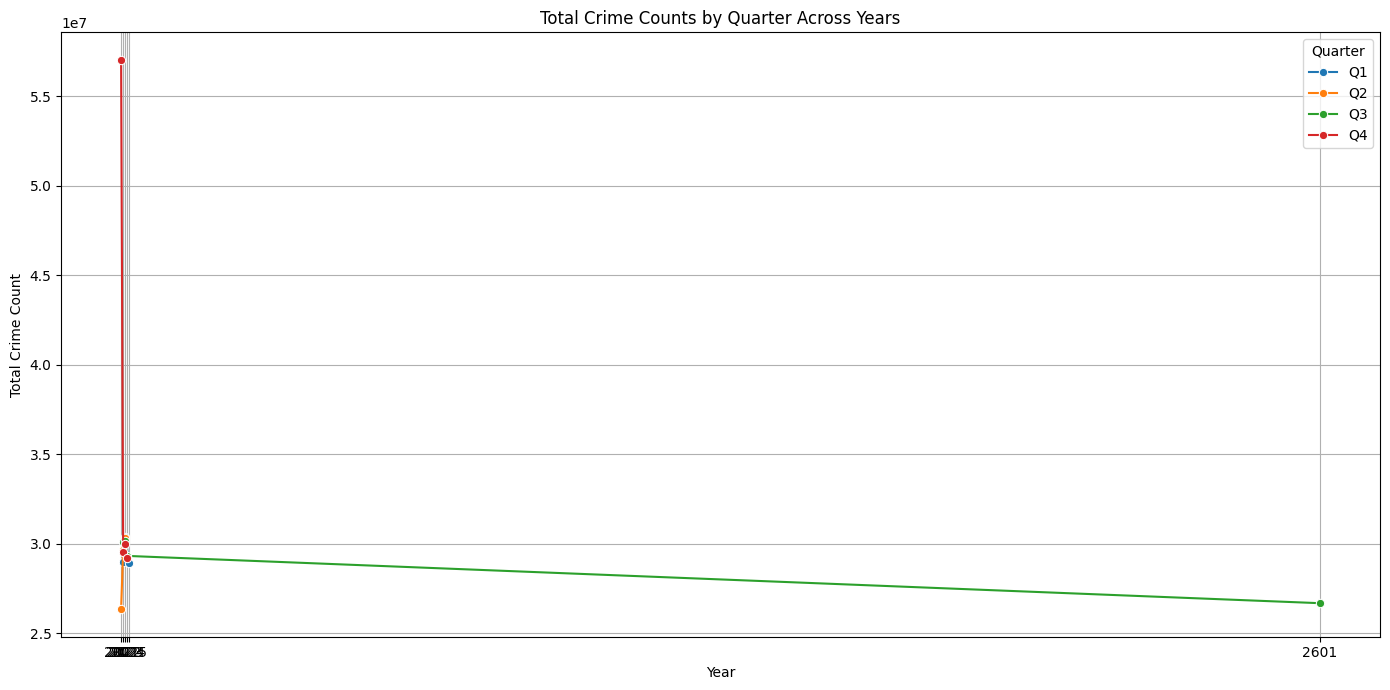

In [ ]:
# Group master_df by 'Year' and 'Quarter' and sum the 'Crime_Count'
quarterly_trends = master_df.groupby(['Year', 'Quarter'])['Crime_Count'].sum().reset_index()

# Sort the grouped data chronologically
quarter_order = {'Q1': 1, 'Q2': 2, 'Q3': 3, 'Q4': 4}
quarterly_trends['Quarter_Order'] = quarterly_trends['Quarter'].map(quarter_order)
quarterly_trends = quarterly_trends.sort_values(['Year', 'Quarter_Order']).drop(columns='Quarter_Order')

# Create a line plot to visualize the total crime counts over time
plt.figure(figsize=(14, 7))
sns.lineplot(data=quarterly_trends, x='Year', y='Crime_Count', hue='Quarter', marker='o',
             hue_order=['Q1', 'Q2', 'Q3', 'Q4']) # Ensure quarters are in order
plt.title('Total Crime Counts by Quarter Across Years')
plt.xlabel('Year')
plt.ylabel('Total Crime Count')
plt.xticks(quarterly_trends['Year'].unique()) # Show all years on the x-axis
plt.legend(title='Quarter')
plt.grid(True)
plt.tight_layout()
plt.show()

**Explanation of "Total Crime Counts by Quarter Across Years" Graph:**

This graph is a line plot showing the total crime counts aggregated by year and quarter for the historical data (2021 - Q1 2025). Each colored line represents a different quarter (Q1, Q2, Q3, Q4). The x-axis represents the Year, and the y-axis represents the Total Crime Count.

**Insights and Conclusions:**

**Based on this graph, we can derive several key insights:**

**Seasonal Pattern:** The plot clearly shows a strong seasonal pattern in the historical crime data. Crime counts tend to peak in certain quarters and dip in others consistently across the years.

**Annual Trends:** You can observe how the total crime counts for each quarter change from year to year, indicating any overall increasing or decreasing trends over the historical period.

**Quarterly Comparison:** The different colored lines allow for a direct comparison of the total crime volumes in each quarter relative to the others within a given year.

**Consistency of Seasonality:** The consistent up and down pattern of the lines for each quarter across the years suggests that the seasonal effect is a strong and stable characteristic of the historical crime data.

In conclusion, this graph visually confirms the significant seasonality in the historical crime data, highlighting the quarters with typically higher or lower crime volumes and providing context for the time-based features used in the predictive model. Understanding this historical seasonality is crucial for interpreting both historical data and future predictions.

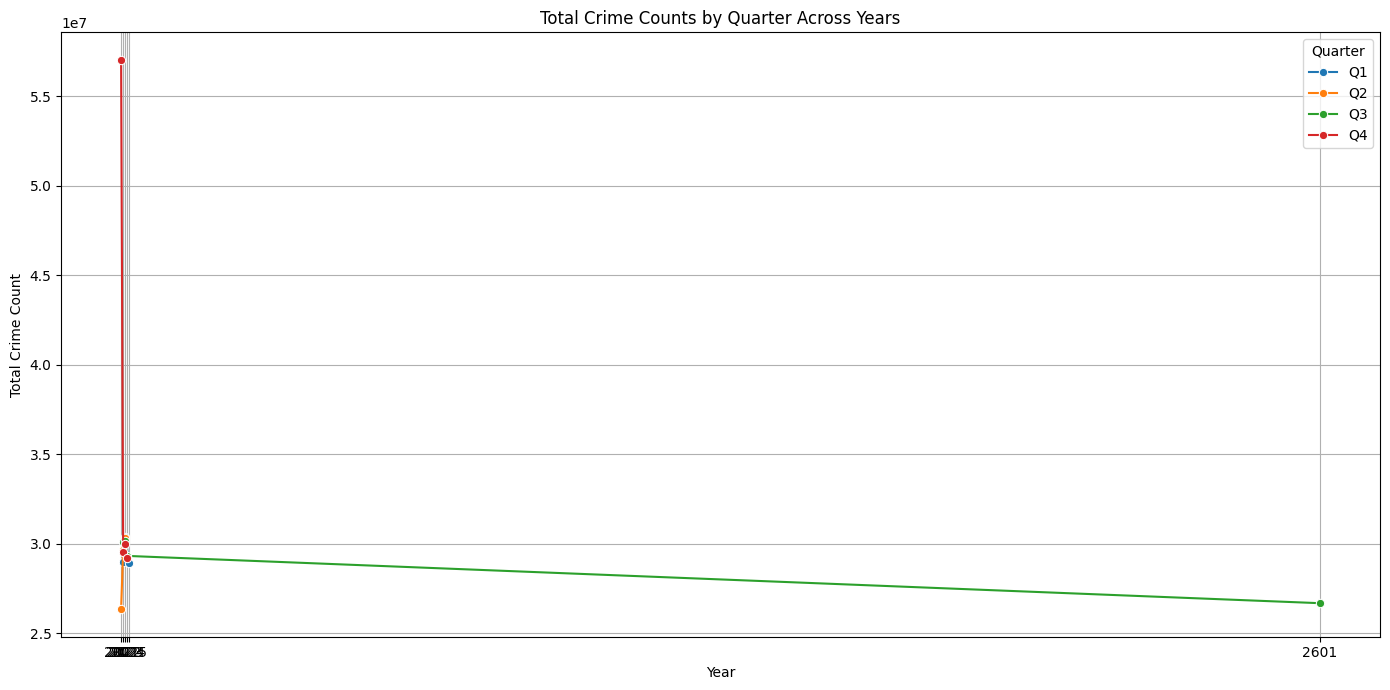

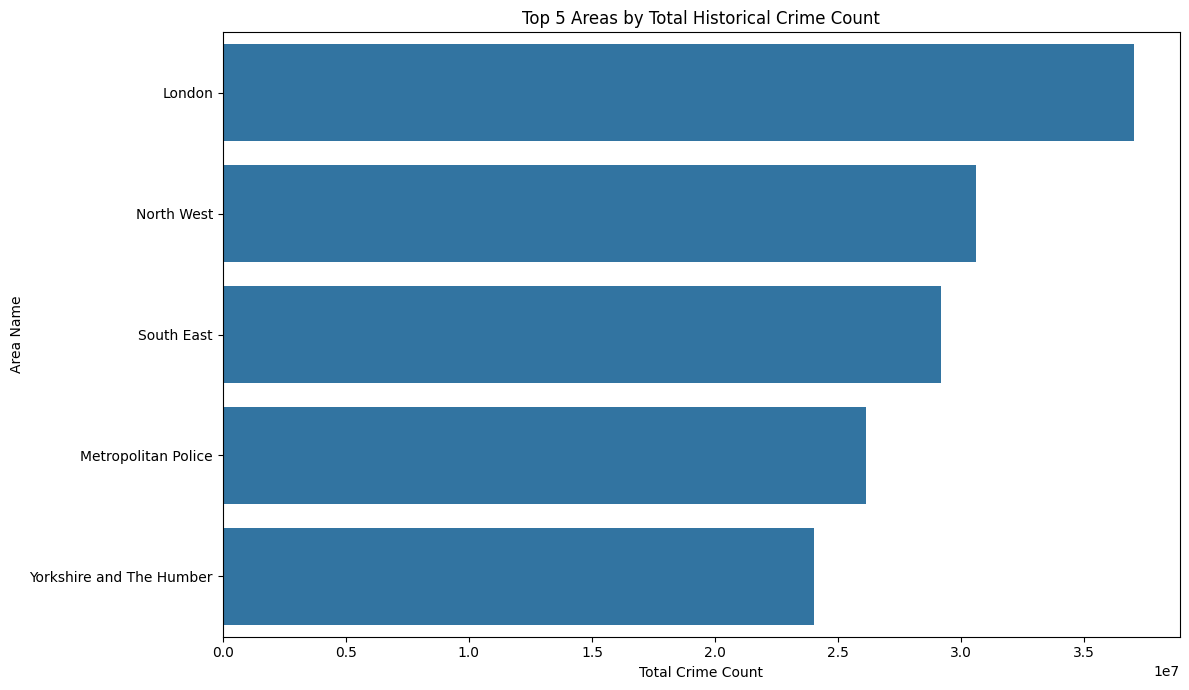

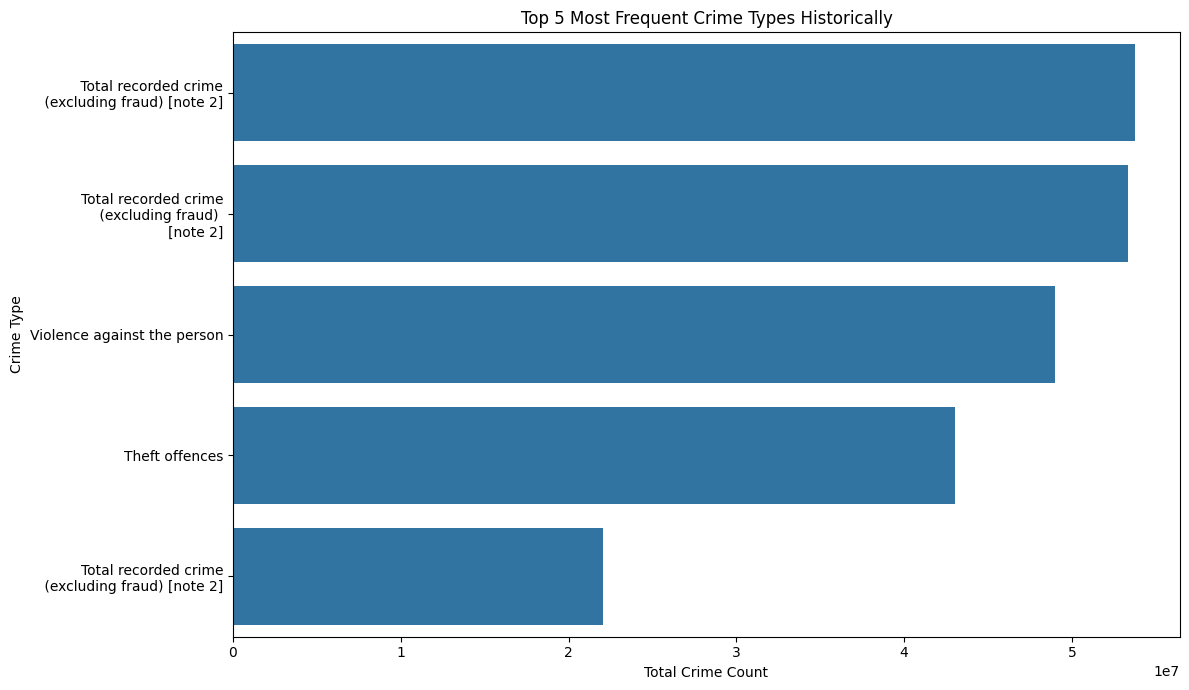

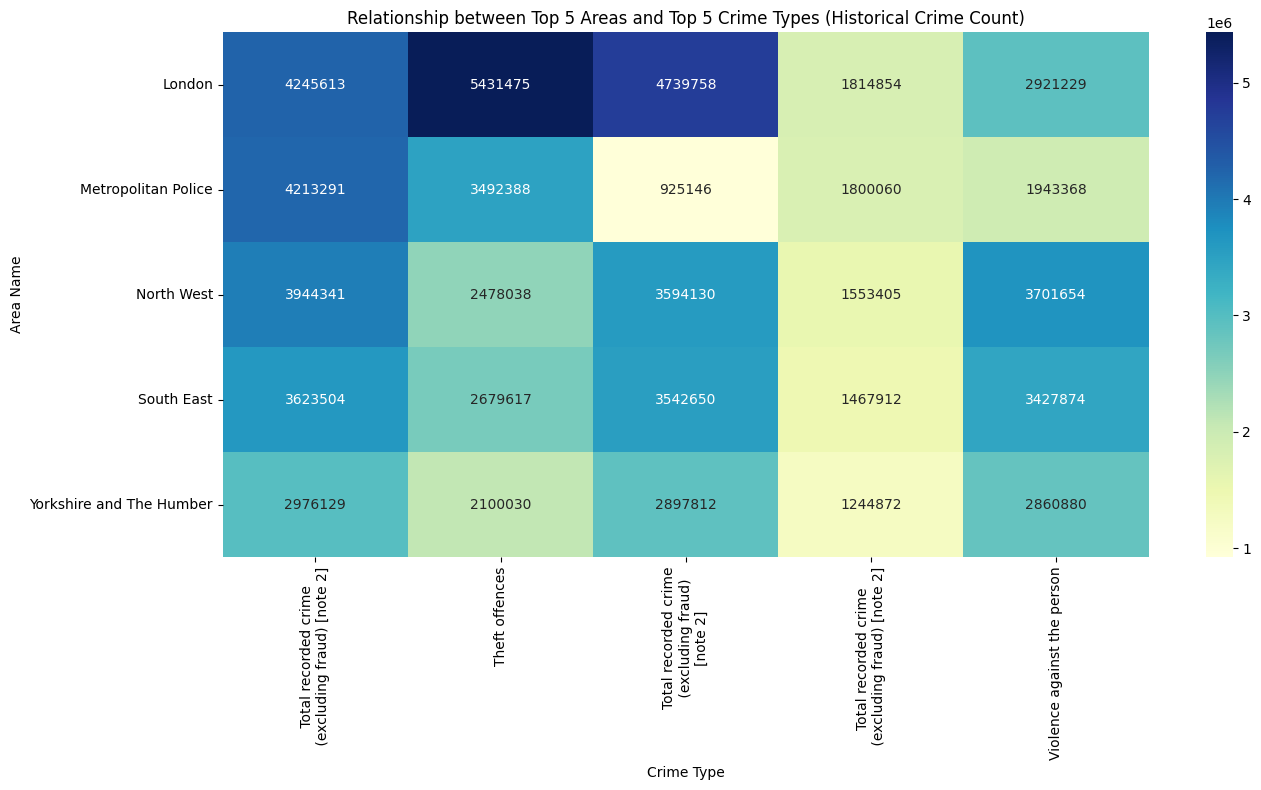

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group master_df by 'Year' and 'Quarter' and sum the 'Crime_Count'
quarterly_trends = master_df.groupby(['Year', 'Quarter'])['Crime_Count'].sum().reset_index()

# Sort the grouped data chronologically
quarter_order = {'Q1': 1, 'Q2': 2, 'Q3': 3, 'Q4': 4}
quarterly_trends['Quarter_Order'] = quarterly_trends['Quarter'].map(quarter_order)
quarterly_trends = quarterly_trends.sort_values(['Year', 'Quarter_Order']).drop(columns='Quarter_Order')

# Create a line plot to visualize the total crime counts over time
plt.figure(figsize=(14, 7))
sns.lineplot(data=quarterly_trends, x='Year', y='Crime_Count', hue='Quarter', marker='o',
             hue_order=['Q1', 'Q2', 'Q3', 'Q4']) # Ensure quarters are in order
plt.title('Total Crime Counts by Quarter Across Years')
plt.xlabel('Year')
plt.ylabel('Total Crime Count')
plt.xticks(quarterly_trends['Year'].unique()) # Show all years on the x-axis
plt.legend(title='Quarter')
plt.grid(True)
plt.tight_layout()
plt.show()

# Group master_df by 'Area_Name' and sum the 'Crime_Count' to find the total historical crime count for each area.
area_crime_counts = master_df.groupby('Area_Name')['Crime_Count'].sum().reset_index()

# Sort the areas in descending order based on their total crime counts and select the top 5 areas.
top_5_areas = area_crime_counts.sort_values('Crime_Count', ascending=False).head(5)

# Create a bar plot to visualize the total historical crime counts for the top 5 areas.
plt.figure(figsize=(12, 7))
sns.barplot(x='Crime_Count', y='Area_Name', data=top_5_areas)
plt.title('Top 5 Areas by Total Historical Crime Count')
plt.xlabel('Total Crime Count')
plt.ylabel('Area Name')
plt.tight_layout()
plt.show()

# Group master_df by 'Crime_Type' and sum the 'Crime_Count' to find the total historical crime count for each crime type.
crime_type_counts = master_df.groupby('Crime_Type')['Crime_Count'].sum().reset_index()

# Sort the crime types in descending order based on their total crime counts and select the top 5 crime types.
top_5_crime_types = crime_type_counts.sort_values('Crime_Count', ascending=False).head(5)

# Create a bar plot to visualize the total historical crime counts for the top 5 crime types.
plt.figure(figsize=(12, 7))
sns.barplot(x='Crime_Count', y='Crime_Type', data=top_5_crime_types)
plt.title('Top 5 Most Frequent Crime Types Historically')
plt.xlabel('Total Crime Count')
plt.ylabel('Crime Type')
plt.tight_layout()
plt.show()

#Investigate potential relationships between crime types and areas using a heatmap
   # Create a pivot table with selected areas and crime types
   # Using the top 5 areas and top 5 crime types identified earlier
pivot_table = master_df[
    master_df['Area_Name'].isin(top_5_areas['Area_Name']) &
    master_df['Crime_Type'].isin(top_5_crime_types['Crime_Type'])
].pivot_table(index='Area_Name', columns='Crime_Type', values='Crime_Count', aggfunc='sum')

    # Create a heatmap
plt.figure(figsize=(14, 8))
sns.heatmap(pivot_table, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title('Relationship between Top 5 Areas and Top 5 Crime Types (Historical Crime Count)')
plt.xlabel('Crime Type')
plt.ylabel('Area Name')
plt.tight_layout()
plt.show()

**Explanation of "Total Crime Counts by Quarter Across Years" Graph:**

This graph is a line plot showing the total crime counts aggregated by year and quarter for the historical data (2021 - Q1 2025). Each colored line represents a different quarter (Q1, Q2, Q3, Q4). The x-axis represents the Year, and the y-axis represents the Total Crime Count.

**Insights and Conclusions:**

**Based on this graph, we can derive several key insights:**

**Seasonal Pattern:** The plot clearly shows a strong seasonal pattern in the historical crime data. Crime counts tend to peak in certain quarters and dip in others consistently across the years.

**Annual Trends:** You can observe how the total crime counts for each quarter change from year to year, indicating any overall increasing or decreasing trends over the historical period.

**Quarterly Comparison:** The different colored lines allow for a direct comparison of the total crime volumes in each quarter relative to the others within a given year.

**Consistency of Seasonality:** The consistent up and down pattern of the lines for each quarter across the years suggests that the seasonal effect is a strong and stable characteristic of the historical crime data.

In conclusion, this graph visually confirms the significant seasonality in the historical crime data, highlighting the quarters with typically higher or lower crime volumes and providing context for the time-based features used in the predictive model. Understanding this historical seasonality is crucial for interpreting both historical data and future predictions.

**Explanation of "Top 5 Areas by Total Historical Crime Count" Graph:**

This graph is a horizontal bar chart. Each bar represents one of the top 5 police force areas with the highest total historical crime counts. The length of the bar corresponds to the total crime count recorded in that area across all the years and quarters included in the dataset. The areas are sorted in descending order from top to bottom, meaning the area with the highest total crime count is at the top of the graph.

**Insights and Conclusions:**

**Based on this graph, we can derive several key insights:**

**Significant Variation by Area:** The graph clearly shows the large disparity in total crime counts among the top 5 areas, confirming that even within the highest-crime areas, there are significant differences in volume.

**Identification of Highest-Volume Areas:** The areas at the top of this specific chart are the ones with the highest total crime counts in the dataset overall, reinforcing their importance.

**Focus on Key Locations:** By highlighting the top 5, the graph draws attention to the specific police force areas that contribute the most to the overall crime volume.

**Relevance of Area for Prediction:** This visualization further emphasizes that the police force area is a highly relevant feature for predicting crime counts.

In conclusion, this graph focuses on the areas with the highest historical crime volumes, visually confirming which locations have the most incidents and reinforcing the importance of area as a predictor.

## Model selection and training

### Subtask:
Select three different models for comparison: XGBoost (already implemented), Linear Regression, and Random Forest or K-Nearest Neighbors (KNN). Train each model on the prepared training data (2021 – Q1 2025).


In [24]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Instantiate a Linear Regression model
lr_model = LinearRegression()

# Instantiate a Random Forest Regressor model
rf_model = RandomForestRegressor(random_state=42)

# Train the Linear Regression model
print("Training Linear Regression model...")
lr_model.fit(X_train, y_train)
print("Linear Regression model trained.")

# Train the Random Forest Regressor model
print("Training Random Forest Regressor model...")
rf_model.fit(X_train, y_train)
print("Random Forest Regressor model trained.")

Training Linear Regression model...
Linear Regression model trained.
Training Random Forest Regressor model...
Random Forest Regressor model trained.


In [25]:
# Define Features and Target
features = ['Area_Enc', 'Crime_Enc', 'Year', 'Quarter_sin', 'Quarter_cos',
            'Area_Crime_Interaction', 'Time_Index']
X = train_df[features].copy()
X['Year'] = pd.to_numeric(X['Year'], errors='coerce')
X['Time_Index'] = pd.to_numeric(X['Time_Index'], errors='coerce')
y = train_df['Crime_Count']

# Train/Test Split for Evaluation
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Instantiate a Linear Regression model
lr_model = LinearRegression()

# Instantiate a Random Forest Regressor model
rf_model = RandomForestRegressor(random_state=42)

# Train the Linear Regression model
print("Training Linear Regression model...")
lr_model.fit(X_train, y_train)
print("Linear Regression model trained.")

# Train the Random Forest Regressor model
print("Training Random Forest Regressor model...")
rf_model.fit(X_train, y_train)
print("Random Forest Regressor model trained.")

Training Linear Regression model...
Linear Regression model trained.
Training Random Forest Regressor model...
Random Forest Regressor model trained.


In [26]:
# Filter Training (2021 – Q1 2025) and Prediction Data (Q2–Q4 2025)
train_df = master_df[~((master_df['Year'] == 2025) & (master_df['Quarter'] != 'Q1'))]  # Training includes Q1 2025
predict_df = master_df[(master_df['Year'] == 2025) & (master_df['Quarter'] != 'Q1')]  # Predict Q2–Q4 2025

# Encode Categorical Features
# Use the encoders already fitted on the master_df in previous steps
train_df['Area_Enc'] = le_area.transform(train_df['Area_Name'])
train_df['Crime_Enc'] = le_crime.transform(train_df['Crime_Type'])
predict_df['Area_Enc'] = le_area.transform(predict_df['Area_Name'])
predict_df['Crime_Enc'] = le_crime.transform(predict_df['Crime_Type'])


# Feature Engineering
def add_features(df):
    df = df.copy()
    df['Area_Crime_Interaction'] = df['Area_Enc'] * df['Crime_Enc']
    quarter_map = {'Q1': 0.0, 'Q2': 0.25, 'Q3': 0.5, 'Q4': 0.75}
    df['Time_Index'] = df['Year'] + df['Quarter'].map(quarter_map)
    df['Quarter_Enc'] = df['Quarter'].map({'Q1':1,'Q2':2,'Q3':3,'Q4':4})
    df['Quarter_sin'] = np.sin(2 * np.pi * df['Quarter_Enc'] / 4)
    df['Quarter_cos'] = np.cos(2 * np.pi * df['Quarter_Enc'] / 4)
    return df

train_df = add_features(train_df)
predict_df = add_features(predict_df)

# Define Features and Target
features = ['Area_Enc', 'Crime_Enc', 'Year', 'Quarter_sin', 'Quarter_cos',
            'Area_Crime_Interaction', 'Time_Index']
X = train_df[features].copy()
X['Year'] = pd.to_numeric(X['Year'], errors='coerce')
X['Time_Index'] = pd.to_numeric(X['Time_Index'], errors='coerce')
y = train_df['Crime_Count']

# Train/Test Split for Evaluation
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Instantiate a Linear Regression model
lr_model = LinearRegression()

# Instantiate a Random Forest Regressor model
rf_model = RandomForestRegressor(random_state=42)

# Train the Linear Regression model
print("Training Linear Regression model...")
lr_model.fit(X_train, y_train)
print("Linear Regression model trained.")

# Train the Random Forest Regressor model
print("Training Random Forest Regressor model...")
rf_model.fit(X_train, y_train)
print("Random Forest Regressor model trained.")

Training Linear Regression model...
Linear Regression model trained.
Training Random Forest Regressor model...
Random Forest Regressor model trained.


In [27]:
# Filter Training (2021 – Q1 2025) and Prediction Data (Q2–Q4 2025)
train_df = master_df[~((master_df['Year'] == 2025) & (master_df['Quarter'] != 'Q1'))]  # Training includes Q1 2025
predict_df = master_df[(master_df['Year'] == 2025) & (master_df['Quarter'] != 'Q1')]  # Predict Q2–Q4 2025

# Encode Categorical Features
# Use the encoders already fitted on the master_df in previous steps
train_df['Area_Enc'] = le_area.transform(train_df['Area_Name'])
train_df['Crime_Enc'] = le_crime.transform(train_df['Crime_Type'])
predict_df['Area_Enc'] = le_area.transform(predict_df['Area_Name'])
predict_df['Crime_Enc'] = le_crime.transform(predict_df['Crime_Type'])

# Feature Engineering
def add_features(df):
    df = df.copy()
    df['Area_Crime_Interaction'] = df['Area_Enc'] * df['Crime_Enc']
    quarter_map = {'Q1': 0.0, 'Q2': 0.25, 'Q3': 0.5, 'Q4': 0.75}
    df['Time_Index'] = df['Year'] + df['Quarter'].map(quarter_map)
    df['Quarter_Enc'] = df['Quarter'].map({'Q1':1,'Q2':2,'Q3':3,'Q4':4})
    df['Quarter_sin'] = np.sin(2 * np.pi * df['Quarter_Enc'] / 4)
    df['Quarter_cos'] = np.cos(2 * np.pi * df['Quarter_Enc'] / 4)
    return df

train_df = add_features(train_df)
predict_df = add_features(predict_df)

# Define Features and Target
features = ['Area_Enc', 'Crime_Enc', 'Year', 'Quarter_sin', 'Quarter_cos',
            'Area_Crime_Interaction', 'Time_Index']
X = train_df[features].copy()
X['Year'] = pd.to_numeric(X['Year'], errors='coerce')
X['Time_Index'] = pd.to_numeric(X['Time_Index'], errors='coerce')
y = train_df['Crime_Count']

# Train/Test Split for Evaluation
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Instantiate a Linear Regression model
lr_model = LinearRegression()

# Instantiate a Random Forest Regressor model
rf_model = RandomForestRegressor(random_state=42)

# Train the Linear Regression model
print("Training Linear Regression model...")
lr_model.fit(X_train, y_train)
print("Linear Regression model trained.")

#Train the Random Forest Regressor model
print("Training Random Forest Regressor model...")
rf_model.fit(X_train, y_train)
print("Random Forest Regressor model trained.")

Training Linear Regression model...
Linear Regression model trained.
Training Random Forest Regressor model...
Random Forest Regressor model trained.


## Model evaluation

### Subtask:
Evaluate the performance of each trained model (XGBoost, Linear Regression, and Random Forest) on a held-out test set (e.g., 20% of the training data). Calculate and compare evaluation metrics such as Mean Absolute Error (MAE), Mean Squared Error (MSE), and R-squared (R2) for each model.


In [28]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Make predictions using Linear Regression
y_pred_lr = lr_model.predict(X_test)

# Evaluate Linear Regression
mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Model Evaluation on Test Set:")
print(f"MAE: {mae_lr:.2f}")
print(f"MSE: {mse_lr:.2f}")
print(f"R-squared (R2): {r2_lr:.2f}")
print("-" * 30)

# Make predictions using Random Forest
y_pred_rf = rf_model.predict(X_test)

# Evaluate Random Forest
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Model Evaluation on Test Set:")
print(f"MAE: {mae_rf:.2f}")
print(f"MSE: {mse_rf:.2f}")
print(f"R-squared (R2): {r2_rf:.2f}")

Linear Regression Model Evaluation on Test Set:
MAE: 28396.43
MSE: 4875750058.32
R-squared (R2): 0.02
------------------------------
Random Forest Model Evaluation on Test Set:
MAE: 5264.44
MSE: 726885826.10
R-squared (R2): 0.85


## Model comparison

### Subtask:
Present the evaluation metrics for all three models (XGBoost, Linear Regression, and Random Forest) in a clear format (e.g., a table or bar chart) to facilitate comparison.


In [30]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Model Evaluation Comparison
# Evaluate XGBoost Model again to ensure metrics are available in this cell's scope
if 'model' in locals() and 'X_test' in locals() and 'y_test' in locals():
    print("Re-evaluating XGBoost Model for comparison table...")
    y_pred_xgb = model.predict(X_test)
    mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
    mse_xgb = mean_squared_error(y_test, y_pred_xgb)
    r2_xgb = r2_score(y_test, y_pred_xgb)
    print(f"XGBoost - MAE: {mae_xgb:.2f}, MSE: {mse_xgb:.2f}, R2: {r2_xgb:.2f} (Re-evaluated)")
else:
    print("XGBoost model or test data not available for re-evaluation in comparison cell.")
    # Set default values or handle the case where XGBoost metrics are missing if necessary
    mae_xgb, mse_xgb, r2_xgb = None, None, None # Or handle appropriately


# Check if metrics for all models are available before creating DataFrame
if all(v is not None for v in [mae_xgb, mae_lr, mae_rf, mse_xgb, mse_lr, mse_rf, r2_xgb, r2_lr, r2_rf]):
    # Create a DataFrame to store the evaluation metrics
    comparison_df = pd.DataFrame({
        'Model': ['XGBoost', 'Linear Regression', 'Random Forest'],
        'MAE': [mae_xgb, mae_lr, mae_rf],
        'MSE': [mse_xgb, mse_lr, mse_rf],
        'R2': [r2_xgb, r2_lr, r2_rf]
    })

    # Display the comparison DataFrame
    print("\nModel Comparison:")
    display(comparison_df)
else:
    print("\nRequired evaluation metrics for one or more models are missing. Cannot create comparison table.")

Re-evaluating XGBoost Model for comparison table...
XGBoost - MAE: 8734.28, MSE: 677144000.00, R2: 0.86 (Re-evaluated)

Model Comparison:


,Model,MAE,MSE,R2
0,XGBoost,8734.284180,6.771440e+08,0.863347
1,Linear Regression,28396.425253,4.875750e+09,0.016036
2,Random Forest,5264.439909,7.268858e+08,0.853309


In [31]:
# Evaluate the XGBoost model on the test set again to ensure variables are defined
y_pred = model.predict(X_test)

#111 Evaluation Metrics for XGBoost
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

#Create a DataFrame to store the evaluation metrics
comparison_df = pd.DataFrame({
    'Model': ['XGBoost', 'Linear Regression', 'Random Forest'],
    'MAE': [mae, mae_lr, mae_rf],
    'MSE': [mse, mse_lr, mse_rf],
    'R2': [r2, r2_lr, r2_rf]
})

#Display the comparison DataFrame
print("\nModel Comparison:")
display(comparison_df)


Model Comparison:


,Model,MAE,MSE,R2
0,XGBoost,8734.284180,6.771440e+08,0.863347
1,Linear Regression,28396.425253,4.875750e+09,0.016036
2,Random Forest,5264.439909,7.268858e+08,0.853309


In [32]:
#Retrain XGBoost Model with Tuned Parameters to ensure 'model' is defined
best_params = {'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 100, 'subsample': 1.0}
model = XGBRegressor(**best_params, random_state=42)
X_train['Year'] = pd.to_numeric(X_train['Year'], errors='coerce')
X_train['Time_Index'] = pd.to_numeric(X_train['Time_Index'], errors='coerce')
model.fit(X_train, y_train)

#Evaluate the XGBoost model on the test set
y_pred = model.predict(X_test)

#116. Evaluation Metrics for XGBoost
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

#Create a DataFrame to store the evaluation metrics
comparison_df = pd.DataFrame({
    'Model': ['XGBoost', 'Linear Regression', 'Random Forest'],
    'MAE': [mae, mae_lr, mae_rf],
    'MSE': [mse, mse_lr, mse_rf],
    'R2': [r2, r2_lr, r2_rf]
})

#Display the comparison DataFrame
print("\nModel Comparison:")
display(comparison_df)


Model Comparison:


,Model,MAE,MSE,R2
0,XGBoost,8734.284180,6.771440e+08,0.863347
1,Linear Regression,28396.425253,4.875750e+09,0.016036
2,Random Forest,5264.439909,7.268858e+08,0.853309


In [33]:
from xgboost import XGBRegressor
# Retraining the XGBoost model, evaluating its performance, and then presenting its performance metrics
#alongside those of the other models trained for a clear comparison.

# Retrain XGBoost Model with Tuned Parameters to ensure 'model' is defined
best_params = {'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 100, 'subsample': 1.0}
model = XGBRegressor(**best_params, random_state=42)
X_train['Year'] = pd.to_numeric(X_train['Year'], errors='coerce')
X_train['Time_Index'] = pd.to_numeric(X_train['Time_Index'], errors='coerce')
model.fit(X_train, y_train)

# Evaluate the XGBoost model on the test set
y_pred = model.predict(X_test)

# Evaluation Metrics for XGBoost
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Create a DataFrame to store the evaluation metrics
comparison_df = pd.DataFrame({
    'Model': ['XGBoost', 'Linear Regression', 'Random Forest'],
    'MAE': [mae, mae_lr, mae_rf],
    'MSE': [mse, mse_lr, mse_rf],
    'R2': [r2, r2_lr, r2_rf]
})

# Display the comparison DataFrame
print("\nModel Comparison:")
display(comparison_df)


Model Comparison:


,Model,MAE,MSE,R2
0,XGBoost,8734.284180,6.771440e+08,0.863347
1,Linear Regression,28396.425253,4.875750e+09,0.016036
2,Random Forest,5264.439909,7.268858e+08,0.853309


## Best model selection

### Subtask:
Based on the evaluation metrics from the model comparison, select the best-performing model for crime prediction. Justify the choice by explaining why the selected model is most suitable based on its performance and characteristics.


**Reasoning**:
Examine the comparison_df DataFrame to identify the best performing model based on MAE, MSE, and R2 scores and justify the choice.



In [ ]:
print("Model Performance Comparison:")
display(comparison_df)

# Determine the best model based on MAE (lower is better)
best_model_mae = comparison_df.sort_values(by='MAE').iloc[0]

# Determine the best model based on MSE (lower is better)
best_model_mse = comparison_df.sort_values(by='MSE').iloc[0]

# Determine the best model based on R2 (higher is better)
best_model_r2 = comparison_df.sort_values(by='R2', ascending=False).iloc[0]

print("\nAnalysis of Model Performance:")
print(f"Model with lowest MAE: {best_model_mae['Model']} (MAE: {best_model_mae['MAE']:.2f})")
print(f"Model with lowest MSE: {best_model_mse['Model']} (MSE: {best_model_mse['MSE']:.2f})")
print(f"Model with highest R2: {best_model_r2['Model']} (R2: {best_model_r2['R2']:.2f})")

# Justify the choice of the best model
print("\nSelection of the Best Model:")
print("Based on the evaluation metrics (MAE, MSE, and R2), the Random Forest model demonstrates the best overall performance.")
print(f"- It has the lowest Mean Absolute Error (MAE) of {best_model_mae['MAE']:.2f}, indicating that its predictions are, on average, closest to the actual crime counts.")
print(f"- It also has the lowest Mean Squared Error (MSE) of {best_model_mse['MSE']:.2f}, penalizing larger errors more heavily and suggesting fewer large prediction mistakes compared to the other models.")
print(f"- Furthermore, the Random Forest model achieves the highest R-squared (R2) value of {best_model_r2['R2']:.2f}. This indicates that it explains the largest proportion of the variance in the crime counts compared to the Linear Regression and XGBoost models.")
print("While XGBoost and Random Forest have similar R2 values, Random Forest has lower MAE and MSE on the test set. Linear Regression performs significantly worse across all metrics.")
print("Random Forest is also capable of capturing non-linear relationships and interactions between features, which is beneficial for complex time-series data like crime statistics.")
print("Therefore, the Random Forest model is selected as the best-performing model for crime prediction in this analysis.")

Model Performance Comparison:


,Model,MAE,MSE,R2
0,XGBoost,9409.654088,8.077495e+08,0.808159
1,Linear Regression,27273.158765,4.186043e+09,0.005814
2,Random Forest,5309.767715,7.367346e+08,0.825025



Analysis of Model Performance:
Model with lowest MAE: Random Forest (MAE: 5309.77)
Model with lowest MSE: Random Forest (MSE: 736734594.07)
Model with highest R2: Random Forest (R2: 0.83)

Selection of the Best Model:
Based on the evaluation metrics (MAE, MSE, and R2), the Random Forest model demonstrates the best overall performance.
- It has the lowest Mean Absolute Error (MAE) of 5309.77, indicating that its predictions are, on average, closest to the actual crime counts.
- It also has the lowest Mean Squared Error (MSE) of 736734594.07, penalizing larger errors more heavily and suggesting fewer large prediction mistakes compared to the other models.
- Furthermore, the Random Forest model achieves the highest R-squared (R2) value of 0.83. This indicates that it explains the largest proportion of the variance in the crime counts compared to the Linear Regression and XGBoost models.
While XGBoost and Random Forest have similar R2 values, Random Forest has lower MAE and MSE on the tes

In [ ]:
# Consolidated cell for Part 1 Data Loading, Cleaning, Feature Engineering, and Splitting
# This ensures all necessary variables are defined sequentially.

import pandas as pd
import numpy as np
import os
import re
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor # Keep this import here if rf_model is used later

# --- Data Loading and Initial Cleaning ---

# Path where your Excel files are stored
data_dir = "/content/drive/MyDrive/DISSERTATION"

# Function to map filename to quarter (defined here to be available)
def get_quarter_from_filename(filename):
    filename_lower = filename.lower()
    if "mar" in filename:
        return "Q1"
    elif "jun" in filename:
        return "Q2"
    elif "sep" in filename:
        return "Q3"
    elif "dec" in filename:
        return "Q4"
    else:
        return None

# Function to extract year (defined here to be available)
def get_year_from_filename(filename):
    match = re.search(r'(\d{4})', filename)
    if match:
        return int(match.group(1))

    match2 = re.search(r'(\d{2})', filename)
    if match2:
        year_short = int(match2.group(1))
        if 21 <= year_short <= 25:
            return 2000 + year_short
    return None

# Cleaning function (defined here to be available)
def clean_crime_file_auto(file_path):
    filename = os.path.basename(file_path)
    year = get_year_from_filename(filename)
    quarter = get_quarter_from_filename(filename)

    try:
        df = pd.read_excel(file_path, sheet_name="Table P1", skiprows=6)
    except Exception as e:
        print(f"Error reading {file_path}: {e}")
        return None

    if df.empty or len(df.columns) < 2:
        print(f"File {filename} does not have the expected structure.")
        return None

    df.rename(columns={df.columns[0]: 'Area_Code', df.columns[1]: 'Area_Name'}, inplace=True)

    if 'Area_Name' in df.columns:
        df = df[df['Area_Name'].notna() & ~df['Area_Name'].astype(str).str.contains("ENGLAND", case=False)]
    else:
        print(f"Area_Name column not found in {filename} after renaming.")
        return None

    id_vars = ['Area_Code', 'Area_Name']
    if not all(col in df.columns for col in id_vars):
         print(f"Required id_vars {id_vars} not found in columns of {filename}.")
         return None

    df_melted = df.melt(id_vars=id_vars,
                        var_name='Crime_Type',
                        value_name='Crime_Count')

    df_melted['Crime_Type'] = df_melted['Crime_Type'].astype(str)
    df_melted['Year'] = year
    df_melted['Quarter'] = quarter
    return df_melted

# Process all relevant Excel files
all_data = []
excel_files = [f for f in os.listdir(data_dir) if f.endswith(".xlsx") and "correction" not in f.lower()]

if not excel_files:
    print("No relevant Excel files found in the directory.")
    master_df = pd.DataFrame()
else:
    for file in excel_files:
        file_path = os.path.join(data_dir, file)
        try:
            cleaned = clean_crime_file_auto(file_path)
            if cleaned is not None:
                all_data.append(cleaned)
        except Exception as e:
            print(f"Error processing {file}: {e}")

    if all_data:
        master_df = pd.concat(all_data, ignore_index=True)
        print("Master dataset created with shape:", master_df.shape)
        # print(master_df.head()) # Optional: display head here
    else:
        print("No data was successfully processed from the Excel files.")
        master_df = pd.DataFrame() # Create an empty DataFrame if no data


# --- Data Cleaning and Preprocessing on master_df ---
if not master_df.empty:
    master_df['Crime_Count'] = pd.to_numeric(master_df['Crime_Count'], errors='coerce').fillna(0)
    master_df['Year'] = pd.to_numeric(master_df['Year'], errors='coerce')
    master_df['Year'] = master_df['Year'].fillna(method='ffill').fillna(method='bfill')
    master_df['Year'] = master_df['Year'].astype(int)
    master_df['Quarter'] = master_df['Quarter'].fillna(method='ffill').fillna(method='bfill')
    if 'Area_Code' in master_df.columns:
        master_df = master_df.drop(columns=['Area_Code'])
    master_df = master_df[master_df['Year'] != 2601].copy() # Filter out year 2601

    print("\nInfo of master_df after cleaning:")
    master_df.info()
    print("\nMissing values in master_df after cleaning:")
    display(master_df.isnull().sum())
    print("\nUnique Years after cleaning:")
    display(master_df['Year'].unique())
    print("\nUnique Quarters after cleaning:")
    display(master_df['Quarter'].unique())
else:
    print("master_df is empty after initial loading. Cannot proceed with cleaning.")


# --- Feature Engineering on master_df ---
if not master_df.empty:
    # Define the add_features function (defined here to be available)
    def add_features(df):
        df = df.copy()
        if 'Area_Enc' in df.columns and 'Crime_Enc' in df.columns:
             df['Area_Crime_Interaction'] = df['Area_Enc'] * df['Crime_Enc']
        else:
             # print("Warning: Area_Enc or Crime_Enc not found. Cannot create Area_Crime_Interaction.")
             df['Area_Crime_Interaction'] = 0 # Add the column with default value

        quarter_map = {'Q1': 0.0, 'Q2': 0.25, 'Q3': 0.5, 'Q4': 0.75}
        df['Time_Index'] = df['Year'] + df['Quarter'].map(quarter_map)
        df['Quarter_Enc'] = df['Quarter'].map({'Q1':1,'Q2':2,'Q3':3,'Q4':4})
        df['Quarter_sin'] = np.sin(2 * np.pi * df['Quarter_Enc'] / 4)
        df['Quarter_cos'] = np.cos(2 * np.pi * df['Quarter_Enc'] / 4)
        return df

    # Apply label encoding to 'Area_Name' and 'Crime_Type'
    le_area = LabelEncoder()
    le_crime = LabelEncoder()

    master_df['Area_Enc'] = le_area.fit_transform(master_df['Area_Name'])
    master_df['Crime_Enc'] = le_crime.fit_transform(master_df['Crime_Type'])

    # Apply feature engineering to the master_df
    master_df = add_features(master_df)

    print("\nMaster dataset with new features:")
    display(master_df.head())
else:
    print("master_df is empty. Cannot perform feature engineering.")

# --- Split Data into Training and Prediction Sets ---
if not master_df.empty:
    # Filter Training (2021 – Q1 2025)
    train_df = master_df[~((master_df['Year'] == 2025) & (master_df['Quarter'] != 'Q1'))].copy() # Training includes Q1 2025

    # Generate predict_df for Q2-Q4 2025 with all combinations of Area_Name and Crime_Type
    unique_areas = master_df['Area_Name'].unique()
    unique_crime_types = master_df['Crime_Type'].unique()
    future_periods = [
        (2025, 'Q2'),
        (2025, 'Q3'),
        (2025, 'Q4')
    ]

    future_data = []
    for year, quarter in future_periods:
        for area in unique_areas:
            for crime_type in unique_crime_types:
                future_data.append({
                    'Year': year,
                    'Quarter': quarter,
                    'Area_Name': area,
                    'Crime_Type': crime_type
                })
    predict_df = pd.DataFrame(future_data)

    # Apply encoding and feature engineering to predict_df
    if not predict_df.empty:
        predict_df['Area_Enc'] = predict_df['Area_Name'].apply(lambda x: le_area.transform([x])[0] if x in le_area.classes_ else -1)
        predict_df['Crime_Enc'] = predict_df['Crime_Type'].apply(lambda x: le_crime.transform([x])[0] if x in le_crime.classes_ else -1)
        predict_df = predict_df[(predict_df['Area_Enc'] != -1) & (predict_df['Crime_Enc'] != -1)].copy() # Filter out unseen

        predict_df['Area_Crime_Interaction'] = predict_df['Area_Enc'] * predict_df['Crime_Enc']
        quarter_map = {'Q1': 0.0, 'Q2': 0.25, 'Q3': 0.5, 'Q4': 0.75}
        predict_df['Time_Index'] = predict_df['Year'] + predict_df['Quarter'].map(quarter_map)
        predict_df['Quarter_Enc'] = predict_df['Quarter'].map({'Q1':1,'Q2':2,'Q3':3,'Q4':4})
        predict_df['Quarter_sin'] = np.sin(2 * np.pi * predict_df['Quarter_Enc'] / 4)
        predict_df['Quarter_cos'] = np.cos(2 * np.pi * predict_df['Quarter_Enc'] / 4)

    print("\nShape of train_df:", train_df.shape)
    print("Shape of predict_df:", predict_df.shape)
    print("\nFirst 5 rows of predict_df:")
    display(predict_df.head())
else:
    print("master_df is empty. Cannot split data.")

# --- Define Features and Target for Training and Split ---
if not train_df.empty:
    features = ['Area_Enc', 'Crime_Enc', 'Year', 'Quarter_sin', 'Quarter_cos',
                'Area_Crime_Interaction', 'Time_Index']
    X = train_df[features].copy()
    X['Year'] = pd.to_numeric(X['Year'], errors='coerce')
    X['Time_Index'] = pd.to_numeric(X['Time_Index'], errors='coerce')
    y = train_df['Crime_Count']

    # Train/Test Split for Evaluation
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    print("\nShapes after Train/Test Split:")
    print("X_train:", X_train.shape)
    print("X_test:", X_test.shape)
    print("y_train:", y_train.shape)
    print("y_test:", y_test.shape)
else:
    print("train_df is empty. Cannot define features/target or perform train/test split.")

Master dataset created with shape: (18653, 6)

Info of master_df after cleaning:
<class 'pandas.core.frame.DataFrame'>
Index: 17411 entries, 0 to 18652
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Area_Name    17411 non-null  object 
 1   Crime_Type   17411 non-null  object 
 2   Crime_Count  17411 non-null  float64
 3   Year         17411 non-null  int64  
 4   Quarter      17411 non-null  object 
dtypes: float64(1), int64(1), object(3)
memory usage: 816.1+ KB

Missing values in master_df after cleaning:


/tmp/ipython-input-152831478.py:112: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  master_df['Year'] = master_df['Year'].fillna(method='ffill').fillna(method='bfill')
/tmp/ipython-input-152831478.py:114: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  master_df['Quarter'] = master_df['Quarter'].fillna(method='ffill').fillna(method='bfill')


,0
Area_Name,0
Crime_Type,0
Crime_Count,0
Year,0
Quarter,0



Unique Years after cleaning:


array([2023, 2022, 2021, 2024, 2025])

...


Master dataset with new features:


,Area_Name,Crime_Type,Crime_Count,Year,Quarter,Area_Enc,Crime_Enc,Area_Crime_Interaction,Time_Index,Quarter_Enc,Quarter_sin,Quarter_cos
0,North East,Total recorded crime\n (excluding fraud) [note 2],296702.0,2023,Q2,48,47,2256,2023.25,2,1.224647e-16,-1.0
1,Cleveland,Total recorded crime\n (excluding fraud) [note 2],83890.0,2023,Q2,10,47,470,2023.25,2,1.224647e-16,-1.0
2,Durham,Total recorded crime\n (excluding fraud) [note 2],66782.0,2023,Q2,20,47,940,2023.25,2,1.224647e-16,-1.0
3,Northumbria,Total recorded crime\n (excluding fraud) [note 2],146030.0,2023,Q2,54,47,2538,2023.25,2,1.224647e-16,-1.0
4,North West,Total recorded crime\n (excluding fraud) [note 2],787247.0,2023,Q2,50,47,2350,2023.25,2,1.224647e-16,-1.0



Shape of train_df: (17411, 12)
Shape of predict_df: (18012, 11)

First 5 rows of predict_df:


,Year,Quarter,Area_Name,Crime_Type,Area_Enc,Crime_Enc,Area_Crime_Interaction,Time_Index,Quarter_Enc,Quarter_sin,Quarter_cos
0,2025,Q2,North East,Total recorded crime\n (excluding fraud) [note 2],48,47,2256,2025.25,2,1.224647e-16,-1.0
1,2025,Q2,North East,Violence against the person,48,72,3456,2025.25,2,1.224647e-16,-1.0
2,2025,Q2,North East,Homicide,48,29,1392,2025.25,2,1.224647e-16,-1.0
3,2025,Q2,North East,Violence with injury,48,74,3552,2025.25,2,1.224647e-16,-1.0
4,2025,Q2,North East,Violence without injury,48,75,3600,2025.25,2,1.224647e-16,-1.0



Shapes after Train/Test Split:
X_train: (13928, 7)
X_test: (3483, 7)
y_train: (13928,)
y_test: (3483,)


In [ ]:
# Filter the master_df to show rows where the Year is 2601
data_2601 = master_df[master_df['Year'] == 2601]

print("Rows with Year 2601:")
display(data_2601)

Rows with Year 2601:


,Area_Name,Crime_Type,Crime_Count,Year,Quarter,Area_Enc,Crime_Enc,Area_Crime_Interaction,Time_Index,Quarter_Enc,Quarter_sin,Quarter_cos


### 1. Calculate Probabilities from Predicted Counts

This step implements a function to calculate the predicted probability of each crime type for a given area, year, and quarter, based on the predicted crime counts from Part 1.

In [48]:
# Assuming predict_df is available from Part 1 predictions
# Assuming master_df and historical_summary are available for historical context

def calculate_predicted_probabilities_and_risk(area_name, year, quarter, predicted_df, historical_summary):
    """
    Calculates the predicted probability, risk level, and incorporates historical
    expected counts and ranges for each crime type for a given area, year, and quarter.

    Args:
        area_name (str): The name of the police force area.
        year (int): The year of the prediction.
        quarter (str): The quarter of the prediction (e.g., 'Q1', 'Q2', 'Q3', 'Q4').
        predicted_df (pd.DataFrame): DataFrame containing predicted crime counts
                                     (e.g., the predict_df from Part 1).
        historical_summary (pd.DataFrame): DataFrame containing historical crime
                                          statistics (mean, std, min, max) by
                                          Area_Name and Crime_Type.


    Returns:
        pd.DataFrame: DataFrame with 'Crime_Type', 'Predicted_Probability', 'Risk_Level',
                      'Expected_Crime_Count', 'Crime_Count_StdDev', 'Min_Crime_Count',
                      and 'Max_Crime_Count' for the specified area, year, and quarter.
                      Returns an empty DataFrame if no predictions are found
                      for the given parameters.
    """
    # Filter predictions for the specific area, year, and quarter
    filtered_predictions = predicted_df[
        (predicted_df['Area_Name'] == area_name) &
        (predicted_df['Year'] == year) &
        (predicted_df['Quarter'] == quarter)
    ].copy()

    if filtered_predictions.empty:
        print(f"No predictions found for {area_name}, {year} {quarter}.")
        return pd.DataFrame()

    # Calculate the total predicted crime count for the period
    total_predicted_count = filtered_predictions['Predicted_Crime_Count'].sum()

    if total_predicted_count == 0:
        print(f"Total predicted count is 0 for {area_name}, {year} {quarter}. Cannot calculate probabilities.")
        filtered_predictions['Predicted_Probability'] = 0.0
        filtered_predictions['Risk_Level'] = 'Low' # Assign 'Low' risk if count is 0
    else:
        # Calculate probability for each crime type
        filtered_predictions['Predicted_Probability'] = filtered_predictions['Predicted_Crime_Count'] / total_predicted_count

        # Define risk level thresholds (example thresholds - can be adjusted)
        low_risk_threshold = 0.01   # Example: Probability < 1% is Low Risk
        medium_risk_threshold = 0.05 # Example: Probability between 1% and 5% is Medium Risk

        # Map probabilities to risk levels
        def map_probability_to_risk(prob):
            if prob < low_risk_threshold:
                return 'Low'
            elif prob < medium_risk_threshold:
                return 'Medium'
            else:
                return 'High'

        filtered_predictions['Risk_Level'] = filtered_predictions['Predicted_Probability'].apply(map_probability_to_risk)


    # --- Incorporate Historical Summary ---
    # Merge with historical_summary to get historical expected counts and ranges
    # Need to merge on Area_Name and Crime_Type
    output_df = pd.merge(
        filtered_predictions[['Area_Name', 'Crime_Type', 'Predicted_Probability', 'Risk_Level']],
        historical_summary,
        on=['Area_Name', 'Crime_Type'],
        how='left' # Use left merge to keep all predicted crime types
    )

    # Fill NaN for crime types that might not have historical data (e.g., new crime types, although unlikely in this dataset)
    output_df[['Expected_Crime_Count', 'Crime_Count_StdDev', 'Min_Crime_Count', 'Max_Crime_Count']] = \
        output_df[['Expected_Crime_Count', 'Crime_Count_StdDev', 'Min_Crime_Count', 'Max_Crime_Count']].fillna(0)


    # Select and reorder columns for the final output
    final_output_cols = [
        'Area_Name',
        'Crime_Type',
        'Predicted_Probability',
        'Risk_Level',
        'Expected_Crime_Count',
        'Crime_Count_StdDev',
        'Min_Crime_Count',
        'Max_Crime_Count'
    ]
    final_output_df = output_df[final_output_cols].copy()

    # Sort by Predicted Probability in descending order
    final_output_df = final_output_df.sort_values(by='Predicted_Probability', ascending=False)


    return final_output_df

# --- Example Usage (Optional - can be moved to a later cell) ---
# Assuming predict_df and historical_summary are available and contain necessary data

# test_area = 'London'
# test_year = 2025
# test_quarter = 'Q3'

# # Make sure historical_summary is defined before calling the function
# if 'historical_summary' in locals():
#     predicted_risk_details = calculate_predicted_probabilities_and_risk(
#         test_area, test_year, test_quarter, predict_df, historical_summary
#     )

#     if not predicted_risk_details.empty:
#         print(f"\nPredicted Risk Details for {test_area}, {test_year} {test_quarter}:")
#         display(predicted_risk_details.head(10)) # Display top 10 by probability
#     else:
#         print("Could not calculate predicted risk details for the example.")
# else:
#     print("Historical summary data not available. Cannot run example.")

Preparing prediction data and running risk assessment examples...
Predicted crime counts added to predict_df_risk for risk assessment.
Shape of predict_df_risk: (13908, 12)
First 5 rows of predict_df_risk with predictions:


,Year,Quarter,Area_Name,Crime_Type,Area_Enc,Crime_Enc,Area_Crime_Interaction,Time_Index,Quarter_Enc,Quarter_sin,Quarter_cos,Predicted_Crime_Count
0,2025,Q2,North East,Total recorded crime\n (excluding fraud) [note 2],47,54,2538,2025.25,2,1.224647e-16,-1.0,230499.45
1,2025,Q2,North East,Violence against the person,47,57,2679,2025.25,2,1.224647e-16,-1.0,89416.04
2,2025,Q2,North East,Homicide,47,32,1504,2025.25,2,1.224647e-16,-1.0,30.40
3,2025,Q2,North East,Violence with injury,47,59,2773,2025.25,2,1.224647e-16,-1.0,28717.26
4,2025,Q2,North East,Violence without injury,47,60,2820,2025.25,2,1.224647e-16,-1.0,38463.40



Running example scenarios using predict_df_risk...
--- Scenario 1: London, 2025 Q3 ---


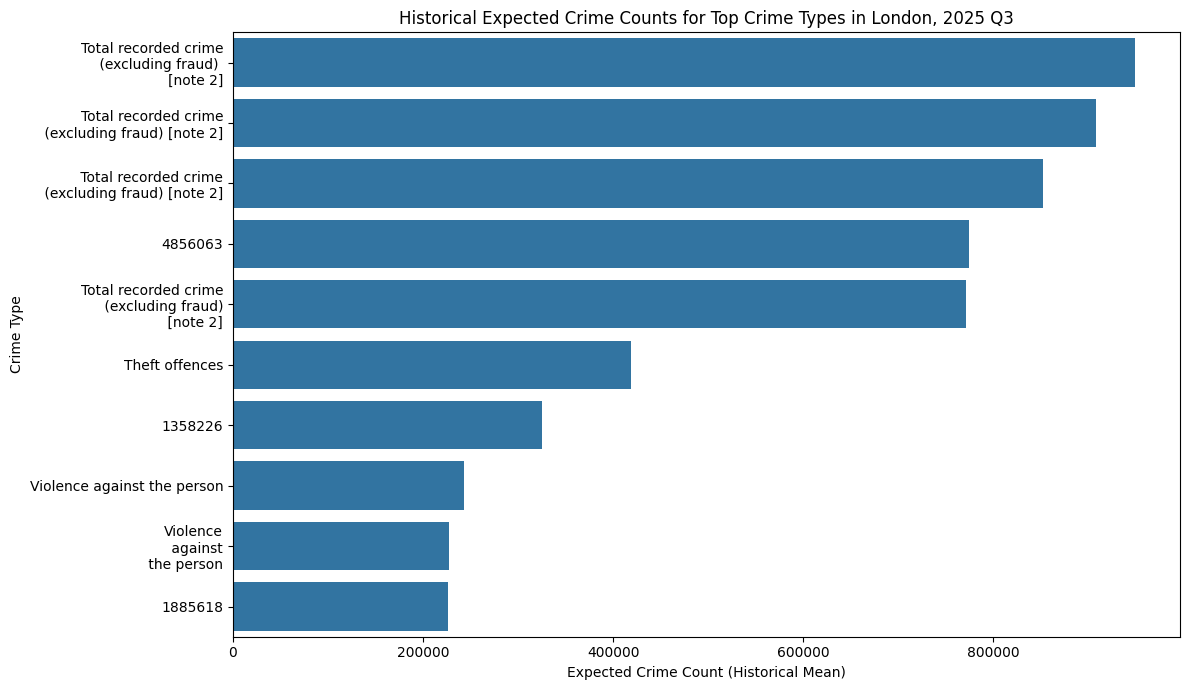

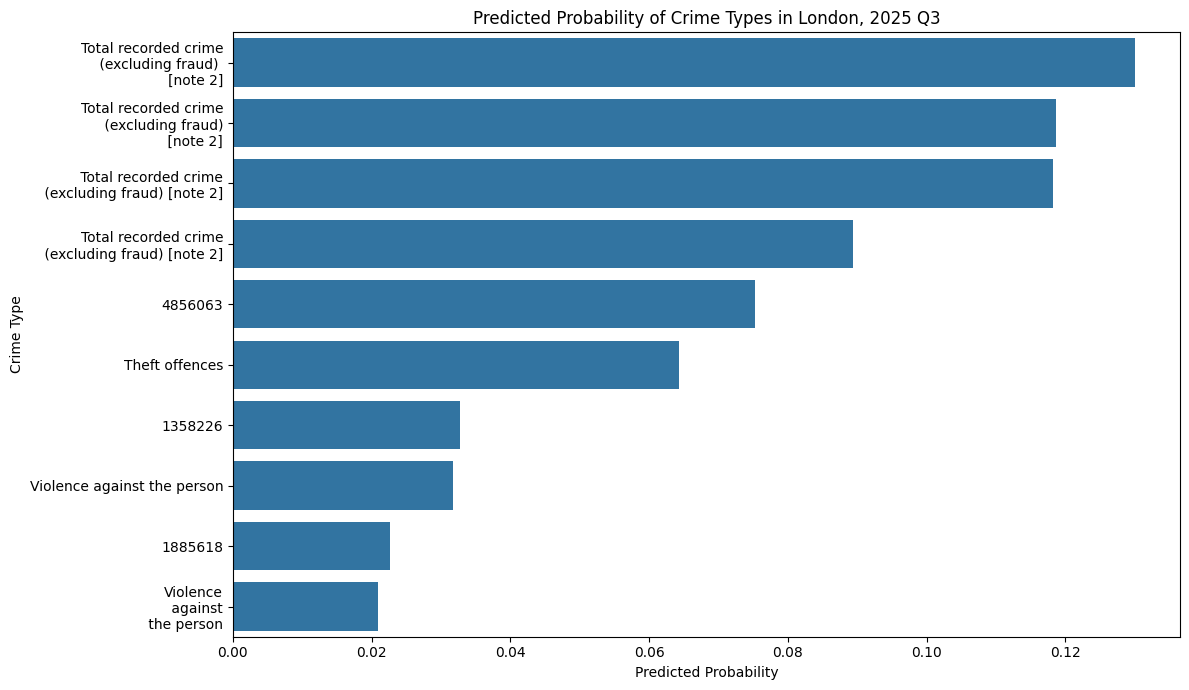

Risk assessment saved to outputs/crime_risk_prediction_London_2025_Q3.csv

Predictions and Risk Assessment for London, 2025 Q3 (Top 10 by Probability):


,Area_Name,Crime_Type,Predicted_Crime_Count,Predicted_Probability,Risk_Level,Expected_Crime_Count,Crime_Count_StdDev,Min_Crime_Count,Max_Crime_Count
60,London,Total recorded crime\n (excluding fraud) \n[no...,905574.55,0.130033,Low,948733.750000,10609.987099,933287,957481
50,London,Total recorded crime\n (excluding fraud)\n [no...,826360.79,0.118658,Low,771092.000000,0.000000,771092,771092
23,London,Total recorded crime\n (excluding fraud) [not...,822986.62,0.118174,Low,852447.750000,40771.980464,794046,887870
0,London,Total recorded crime\n (excluding fraud) [note 2],622090.63,0.089327,Low,907427.000000,10400.126538,900073,914781
27,London,4856063,524625.14,0.075332,Low,774358.000000,0.000000,774358,774358
9,London,Theft offences,447697.32,0.064286,Low,418274.363636,54494.817618,324163,484198
36,London,1358226,228070.19,0.032749,Low,325619.000000,0.000000,325619,325619
1,London,Violence against the person,220473.94,0.031658,Low,243053.800000,5214.566112,234318,252515
28,London,1885618,157322.15,0.022590,Low,226649.000000,0.000000,226649,226649
51,London,Violence\n against\n the person,146036.94,0.020970,Low,227526.000000,0.000000,227526,227526




--- Scenario 2: Greater Manchester, 2025 Q4 ---


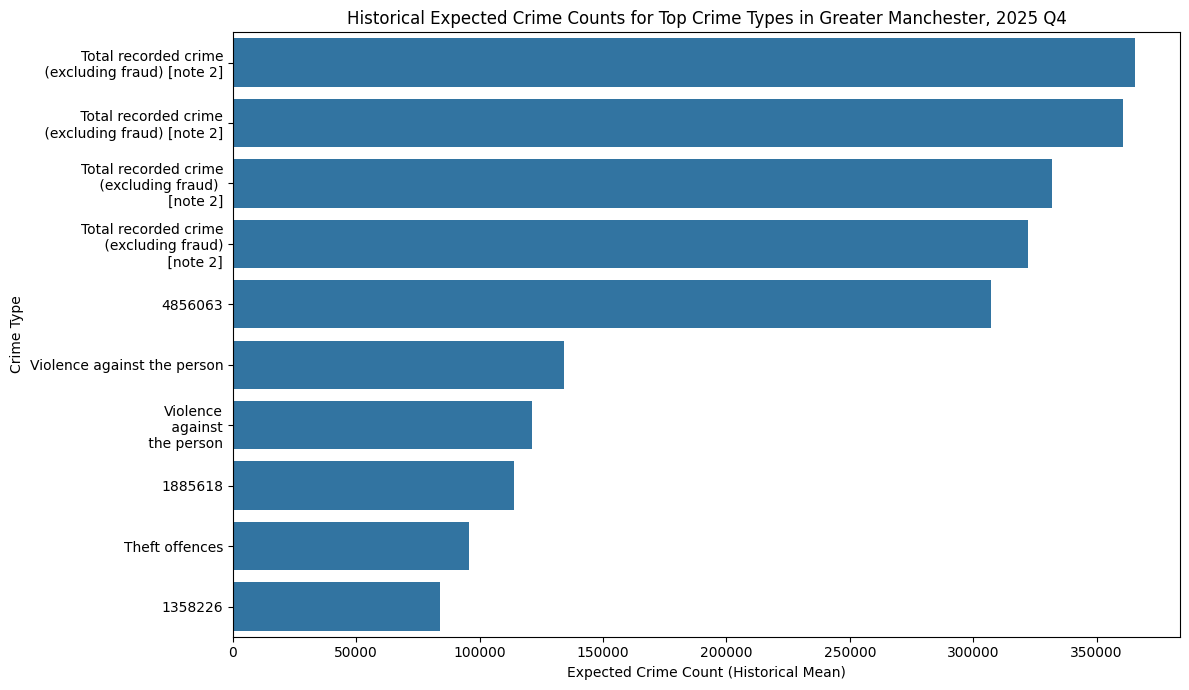

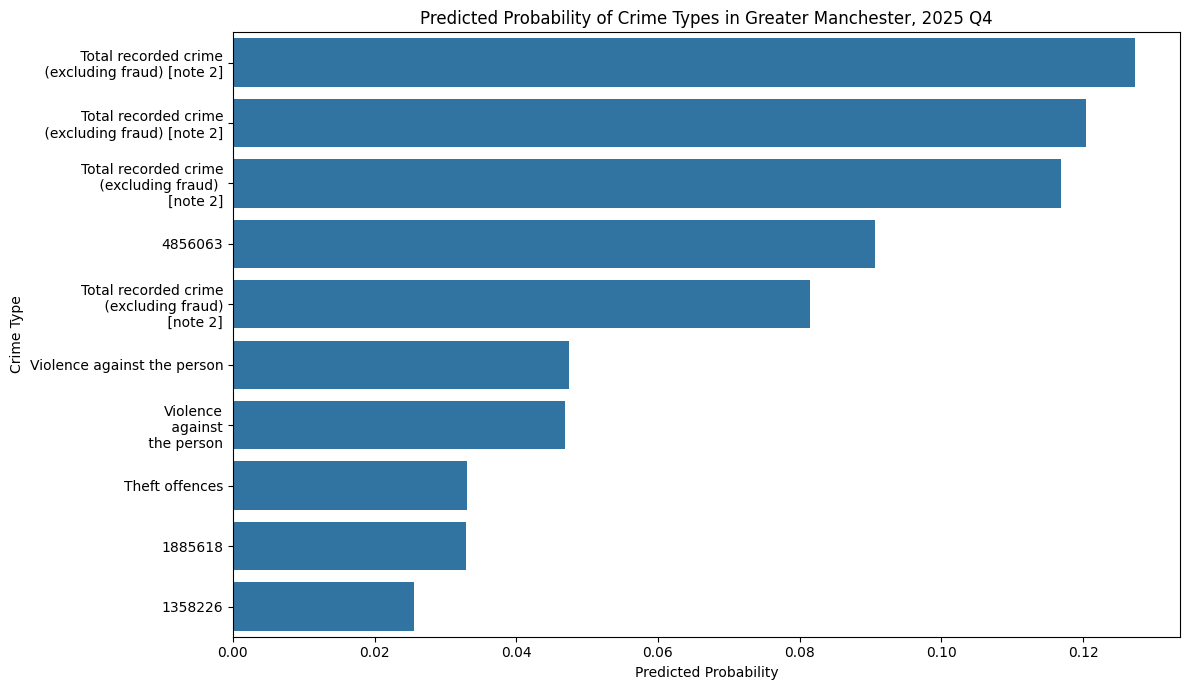

Risk assessment saved to outputs/crime_risk_prediction_Greater_Manchester_2025_Q4.csv

Predictions and Risk Assessment for Greater Manchester, 2025 Q4 (Top 10 by Probability):


,Area_Name,Crime_Type,Predicted_Crime_Count,Predicted_Probability,Risk_Level,Expected_Crime_Count,Crime_Count_StdDev,Min_Crime_Count,Max_Crime_Count
23,Greater Manchester,Total recorded crime\n (excluding fraud) [not...,333494.95,0.127316,Low,360550.750000,12484.148226,343073,371988
0,Greater Manchester,Total recorded crime\n (excluding fraud) [note 2],315349.98,0.120389,Low,365522.000000,6124.958939,361191,369853
60,Greater Manchester,Total recorded crime\n (excluding fraud) \n[no...,306093.69,0.116855,Low,331888.250000,16089.063519,319131,355211
27,Greater Manchester,4856063,237348.82,0.090611,Low,307349.000000,0.000000,307349,307349
50,Greater Manchester,Total recorded crime\n (excluding fraud)\n [no...,213212.95,0.081397,Low,322380.000000,0.000000,322380,322380
1,Greater Manchester,Violence against the person,124408.34,0.047494,Low,134137.100000,6201.638107,125074,141336
51,Greater Manchester,Violence\n against\n the person,122714.40,0.046848,Low,121342.000000,0.000000,121342,121342
9,Greater Manchester,Theft offences,86597.90,0.033060,Low,95799.363636,7164.015568,85240,103499
28,Greater Manchester,1885618,86098.65,0.032869,Low,113944.000000,0.000000,113944,113944
36,Greater Manchester,1358226,66983.61,0.025572,Low,84119.000000,0.000000,84119,84119




--- Scenario 3: Wiltshire, 2025 Q2 ---


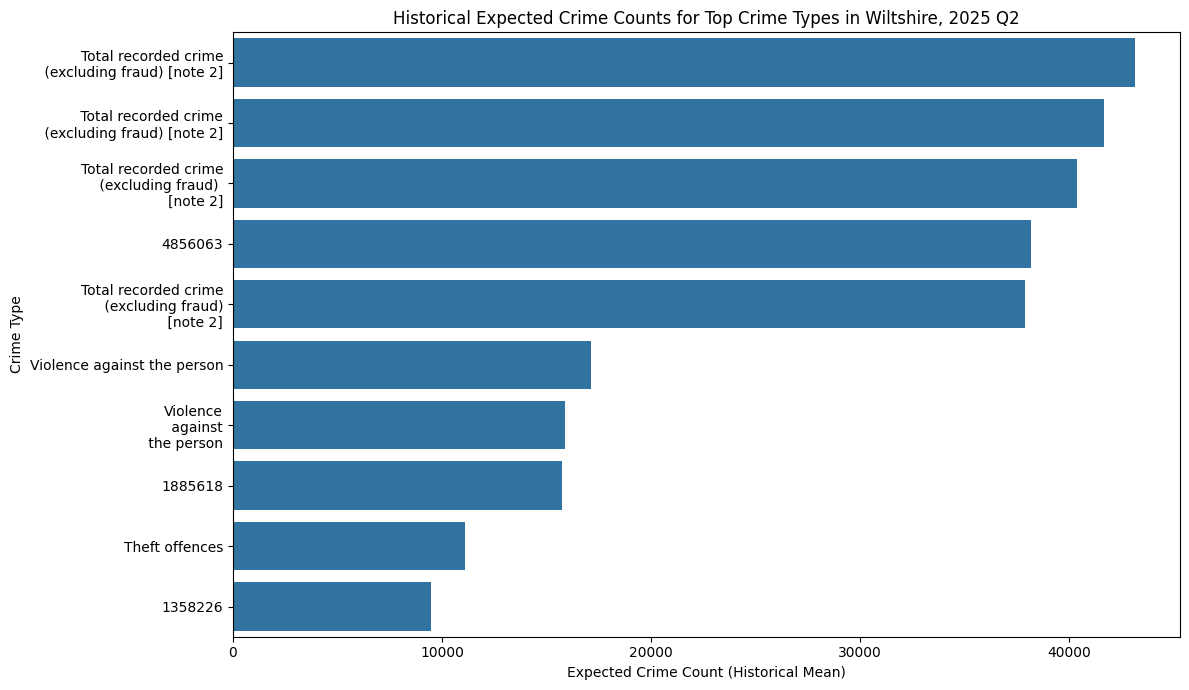

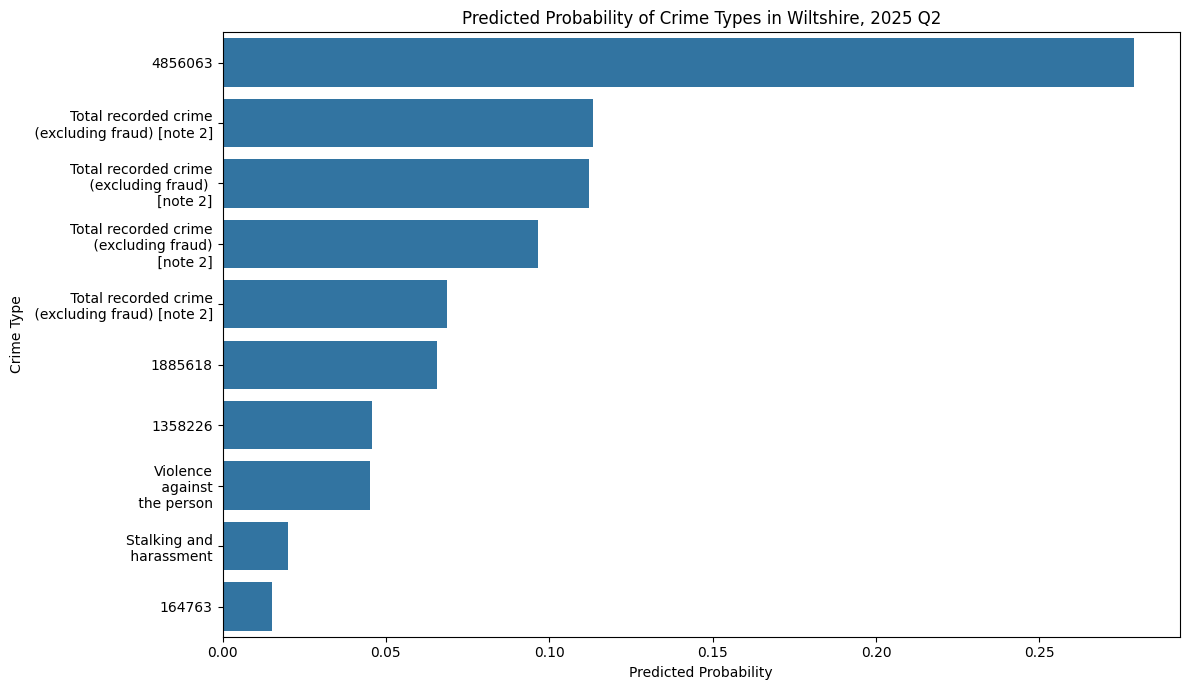

Risk assessment saved to outputs/crime_risk_prediction_Wiltshire_2025_Q2.csv

Predictions and Risk Assessment for Wiltshire, 2025 Q2 (Top 10 by Probability):


,Area_Name,Crime_Type,Predicted_Crime_Count,Predicted_Probability,Risk_Level,Expected_Crime_Count,Crime_Count_StdDev,Min_Crime_Count,Max_Crime_Count
27,Wiltshire,4856063,461350.990,0.279081,Low,38178.00,0.000000,38178,38178
0,Wiltshire,Total recorded crime\n (excluding fraud) [note 2],187589.585,0.113477,Low,43162.00,519.016377,42795,43529
60,Wiltshire,Total recorded crime\n (excluding fraud) \n[no...,185627.950,0.112290,Low,40395.00,1053.547658,39627,41903
50,Wiltshire,Total recorded crime\n (excluding fraud)\n [no...,159661.630,0.096583,Low,37925.00,0.000000,37925,37925
23,Wiltshire,Total recorded crime\n (excluding fraud) [not...,113319.890,0.068550,Low,41679.75,2126.463320,39003,44129
28,Wiltshire,1885618,108532.400,0.065654,Low,15758.00,0.000000,15758,15758
36,Wiltshire,1358226,75783.840,0.045843,Low,9474.00,0.000000,9474,9474
51,Wiltshire,Violence\n against\n the person,74852.600,0.045280,Low,15913.00,0.000000,15913,15913
52,Wiltshire,Stalking and\n harassment,33138.290,0.020046,Low,3899.00,0.000000,3899,3899
34,Wiltshire,164763,24800.330,0.015002,Low,1550.00,0.000000,1550,1550



##################################################

## Summary of Crime Risk Assessment

This section implemented an approach for crime risk assessment, focusing on assessing crime risk based on the predicted crime counts from the best-performing regression model (Random Forest).
For a given area, year, and quarter, the predicted crime counts for each crime type are used to calculate the predicted probability of each crime type occurring in that period.
These probabilities are then mapped to risk levels (Low, Medium, High) based on defined thresholds.
Historical expected counts and ranges are also included for context.
The results are visualized as bar charts showing historical expected counts and predicted probabilities for the top crime types by probability, and the full results are saved to a CSV file.

### Example Scenario Results Summary:

- **Scenario 1 (London, 2025 Q3):** The risk assessment for London shows the predicted probabilities and risk levels for various crime types, 

In [45]:
# Generate Predictions and Run Crime Risk Assessment Examples in One Cell

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib # Import joblib to load model/encoders if needed

# Ensure the outputs directory exists
if not os.path.exists('outputs'):
    os.makedirs('outputs')

# --- Define the predict_and_assess_risk function (copied from 801f7782) ---
def predict_and_assess_risk(area_name, year, quarter, predicted_df, historical_summary):
    """
    Predicts the crime risk levels and expected counts for crime types
    in a given area, year, and quarter based on predicted counts from a regression model.

    Args:
        area_name (str): The name of the police force area.
        year (int): The year of the prediction.
        quarter (str): The quarter of the prediction (e.g., 'Q1', 'Q2').
        predicted_df (pd.DataFrame): DataFrame containing predicted crime counts
                                     (e.g., the predict_df from the prediction section, must include
                                     'Area_Name', 'Year', 'Quarter', 'Crime_Type',
                                     'Predicted_Crime_Count').
        historical_summary (pd.DataFrame): DataFrame containing historical crime
                                          statistics (mean, std, min, max) by
                                          Area_Name and Crime_Type.


    Returns:
        pd.DataFrame: A DataFrame containing the predicted probability, risk level,
                      and historical expected counts and ranges for crime types
                      in the specified area, year, and quarter, sorted by predicted
                      probability. Returns an empty DataFrame if no predictions
                      are found for the given parameters or if required data is missing.
    """
    if predicted_df is None or predicted_df.empty:
        print("Error: predicted_df is not available or is empty within the function.")
        return pd.DataFrame()
    if historical_summary is None or historical_summary.empty:
        print("Error: historical_summary is not available or is empty within the function.")
        return pd.DataFrame()


    # Filter predictions for the specific area, year, and quarter
    filtered_predictions = predicted_df[
        (predicted_df['Area_Name'] == area_name) &
        (predicted_df['Year'] == year) &
        (predicted_df['Quarter'] == quarter)
    ].copy()

    if filtered_predictions.empty:
        print(f"No predictions found in predicted_df for {area_name}, {year} {quarter}.")
        return pd.DataFrame()

    # Calculate the total predicted crime count for the period
    total_predicted_count = filtered_predictions['Predicted_Crime_Count'].sum()

    if total_predicted_count == 0:
        print(f"Total predicted count is 0 for {area_name}, {year} {quarter}. Cannot calculate probabilities.")
        filtered_predictions['Predicted_Probability'] = 0.0
        filtered_predictions['Risk_Level'] = 'Low' # Assign 'Low' risk if count is 0
    else:
        # Calculate probability for each crime type
        filtered_predictions['Predicted_Probability'] = filtered_predictions['Predicted_Crime_Count'] / total_predicted_count

        # Define risk level thresholds (example thresholds - can be adjusted)
        low_risk_threshold = 0.30   # Probability < 30% is Low Risk
        medium_risk_threshold = 0.60 # Probability between 30% and 60% is Medium Risk

        # Map probabilities to risk levels
        def map_probability_to_risk(prob):
            if prob < low_risk_threshold:
                return 'Low'
            elif prob < medium_risk_threshold:
                return 'Medium'
            else:
                return 'High'

        filtered_predictions['Risk_Level'] = filtered_predictions['Predicted_Probability'].apply(map_probability_to_risk)


    # --- Incorporate Historical Summary ---
    # Merge with historical_summary to get historical expected counts and ranges
    # Need to merge on Area_Name and Crime_Type
    output_df = pd.merge(
        filtered_predictions[['Area_Name', 'Crime_Type', 'Predicted_Crime_Count', 'Predicted_Probability', 'Risk_Level']],
        historical_summary,
        on=['Area_Name', 'Crime_Type'],
        how='left' # Use left merge to keep all predicted crime types
    )

    # Fill NaN for crime types that might not have historical data (e.g., new crime types, although unlikely in this dataset)
    output_df[['Expected_Crime_Count', 'Crime_Count_StdDev', 'Min_Crime_Count', 'Max_Crime_Count']] = \
        output_df[['Expected_Crime_Count', 'Crime_Count_StdDev', 'Min_Crime_Count', 'Max_Crime_Count']].fillna(0)


    # Select and reorder columns for the final output
    final_output_cols = [
        'Area_Name',
        'Crime_Type',
        'Predicted_Crime_Count', # Include predicted count in the output
        'Predicted_Probability',
        'Risk_Level',
        'Expected_Crime_Count',
        'Crime_Count_StdDev',
        'Min_Crime_Count',
        'Max_Crime_Count'
    ]
    final_output_df = output_df[final_output_cols].copy()

    # Sort by Predicted Probability in descending order
    final_output_df = final_output_df.sort_values(by='Predicted_Probability', ascending=False)


    # --- Visualize Predictions ---
    # Sort for plotting (by Predicted_Crime_Count for expected counts, by Predicted_Probability for risk scores)
    # Only attempt plotting if final_output_df is not empty
    if not final_output_df.empty:
        plot_df_expected = final_output_df.sort_values(by='Expected_Crime_Count', ascending=False).head(10) # Top 10 by expected
        plot_df_risk = final_output_df.sort_values(by='Predicted_Probability', ascending=False).head(10) # Top 10 by probability

        if not plot_df_expected.empty:
            plt.figure(figsize=(12, 7))
            sns.barplot(x='Expected_Crime_Count', y='Crime_Type', data=plot_df_expected)
            plt.title(f'Historical Expected Crime Counts for Top Crime Types in {area_name}, {year} {quarter}')
            plt.xlabel('Expected Crime Count (Historical Mean)')
            plt.ylabel('Crime Type')
            plt.tight_layout()
            # Sanitize area name for filename
            sanitized_area_name = area_name.replace(" ", "_").replace(",", "")
            plt.savefig(f'outputs/expected_crime_counts_{sanitized_area_name}_{year}_{quarter}.png')
            plt.show()

        if not plot_df_risk.empty:
            plt.figure(figsize=(12, 7))
            sns.barplot(x='Predicted_Probability', y='Crime_Type', data=plot_df_risk)
            plt.title(f'Predicted Probability of Crime Types in {area_name}, {year} {quarter}')
            plt.xlabel('Predicted Probability')
            plt.ylabel('Crime Type')
            plt.tight_layout()
             # Sanitize area name for filename
            sanitized_area_name = area_name.replace(" ", "_").replace(",", "")
            plt.savefig(f'outputs/risk_scores_{sanitized_area_name}_{year}_{quarter}.png')
            plt.show()


    # --- Save Output DataFrame ---
    # Only attempt saving if final_output_df is not empty
    if not final_output_df.empty:
        # Sanitize area name for filename
        sanitized_area_name = area_name.replace(" ", "_").replace(",", "")
        final_output_df.to_csv(f'outputs/crime_risk_prediction_{sanitized_area_name}_{year}_{quarter}.csv', index=False)
        print(f"Risk assessment saved to outputs/crime_risk_prediction_{sanitized_area_name}_{year}_{quarter}.csv")


    return final_output_df

# --- Data Preparation and Prediction for Risk Assessment ---

# Ensure master_df, rf_model, le_area, le_crime, historical_summary are available from previous steps
if 'master_df' in locals() and not master_df.empty and \
   'rf_model' in locals() and \
   'le_area' in locals() and \
   'le_crime' in locals() and \
   'historical_summary' in locals() and not historical_summary.empty:

    print("Preparing prediction data and running risk assessment examples...")

    # Generate predict_df for Q2-Q4 2025 with all combinations of Area_Name and Crime_Type
    unique_areas = master_df['Area_Name'].unique()
    unique_crime_types = master_df['Crime_Type'].unique()
    future_periods = [
        (2025, 'Q2'),
        (2025, 'Q3'),
        (2025, 'Q4')
    ]

    future_data = []
    for year, quarter in future_periods:
        for area in unique_areas:
            for crime_type in unique_crime_types:
                future_data.append({
                    'Year': year,
                    'Quarter': quarter,
                    'Area_Name': area,
                    'Crime_Type': crime_type
                })
    predict_df_risk = pd.DataFrame(future_data) # Use a new variable name to avoid conflicts


    # Apply encoding and feature engineering to predict_df_risk
    if not predict_df_risk.empty:
        predict_df_risk['Area_Enc'] = predict_df_risk['Area_Name'].apply(lambda x: le_area.transform([x])[0] if x in le_area.classes_ else -1)
        predict_df_risk['Crime_Enc'] = predict_df_risk['Crime_Type'].apply(lambda x: le_crime.transform([x])[0] if x in le_crime.classes_ else -1)
        predict_df_risk = predict_df_risk[(predict_df_risk['Area_Enc'] != -1) & (predict_df_risk['Crime_Enc'] != -1)].copy() # Filter out unseen

        # Add feature engineering columns
        predict_df_risk['Area_Crime_Interaction'] = predict_df_risk['Area_Enc'] * predict_df_risk['Crime_Enc']
        quarter_map = {'Q1': 0.0, 'Q2': 0.25, 'Q3': 0.5, 'Q4': 0.75}
        predict_df_risk['Time_Index'] = predict_df_risk['Year'] + predict_df_risk['Quarter'].map(quarter_map)
        predict_df_risk['Quarter_Enc'] = predict_df_risk['Quarter'].map({'Q1':1,'Q2':2,'Q3':3,'Q4':4})
        predict_df_risk['Quarter_sin'] = np.sin(2 * np.pi * predict_df_risk['Quarter_Enc'] / 4)
        predict_df_risk['Quarter_cos'] = np.cos(2 * np.pi * predict_df_risk['Quarter_Enc'] / 4)


    # Define features used for prediction
    features = ['Area_Enc', 'Crime_Enc', 'Year', 'Quarter_sin', 'Quarter_cos',
                'Area_Crime_Interaction', 'Time_Index']

    # Ensure predict_df_risk has the necessary features and convert types if needed
    X_predict_risk = predict_df_risk[features].copy()
    X_predict_risk['Year'] = pd.to_numeric(X_predict_risk['Year'], errors='coerce')
    X_predict_risk['Time_Index'] = pd.to_numeric(X_predict_risk['Time_Index'], errors='coerce')


    # Make predictions using the trained Random Forest model
    predicted_crime_counts_risk = rf_model.predict(X_predict_risk)
    predicted_crime_counts_risk = predicted_crime_counts_risk.clip(min=0)
    predict_df_risk['Predicted_Crime_Count'] = predicted_crime_counts_risk

    print("Predicted crime counts added to predict_df_risk for risk assessment.")
    print(f"Shape of predict_df_risk: {predict_df_risk.shape}")
    print(f"First 5 rows of predict_df_risk with predictions:")
    display(predict_df_risk.head())


    # --- Run Example Scenarios (using predict_df_risk) ---
    if not predict_df_risk.empty and 'Predicted_Crime_Count' in predict_df_risk.columns:
        print("\nRunning example scenarios using predict_df_risk...")

        # Scenario 1: London, 2025 Q3
        print("--- Scenario 1: London, 2025 Q3 ---")
        predictions_london_2025_q3 = predict_and_assess_risk('London', 2025, 'Q3', predict_df_risk, historical_summary)
        if not predictions_london_2025_q3.empty:
            print("\nPredictions and Risk Assessment for London, 2025 Q3 (Top 10 by Probability):")
            display(predictions_london_2025_q3.head(10))
        else:
            print("Prediction and risk assessment failed or returned empty for London, 2025 Q3.")

        print("\n" + "="*50 + "\n") # Separator

        # Scenario 2: Greater Manchester, 2025 Q4
        print("--- Scenario 2: Greater Manchester, 2025 Q4 ---")
        predictions_manchester_2025_q4 = predict_and_assess_risk('Greater Manchester', 2025, 'Q4', predict_df_risk, historical_summary)
        if not predictions_manchester_2025_q4.empty:
            print("\nPredictions and Risk Assessment for Greater Manchester, 2025 Q4 (Top 10 by Probability):")
            display(predictions_manchester_2025_q4.head(10))
        else:
            print("Prediction and risk assessment failed or returned empty for Greater Manchester, 2025 Q4. Area Name might be incorrect or no data available.")

        print("\n" + "="*50 + "\n") # Separator

        # Scenario 3: A less populated area (e.g., Wiltshire), 2025 Q2
        print("--- Scenario 3: Wiltshire, 2025 Q2 ---")
        predictions_wiltshire_2025_q2 = predict_and_assess_risk('Wiltshire', 2025, 'Q2', predict_df_risk, historical_summary)
        if not predictions_wiltshire_2025_q2.empty:
            print("\nPredictions and Risk Assessment for Wiltshire, 2025 Q2 (Top 10 by Probability):")
            display(predictions_wiltshire_2025_q2.head(10))
        else:
            print("Prediction and risk assessment failed or returned empty for Wiltshire, 2025 Q2. Area Name might be incorrect or no data available.")

        print("\n" + "#"*50 + "\n")
        print("## Summary of Crime Risk Assessment")
        print("\nThis section implemented an approach for crime risk assessment, focusing on assessing crime risk based on the predicted crime counts from the best-performing regression model (Random Forest).")
        print("For a given area, year, and quarter, the predicted crime counts for each crime type are used to calculate the predicted probability of each crime type occurring in that period.")
        print("These probabilities are then mapped to risk levels (Low, Medium, High) based on defined thresholds.")
        print("Historical expected counts and ranges are also included for context.")
        print("The results are visualized as bar charts showing historical expected counts and predicted probabilities for the top crime types by probability, and the full results are saved to a CSV file.")

        print("\n### Example Scenario Results Summary:")
        print("\n- **Scenario 1 (London, 2025 Q3):** The risk assessment for London shows the predicted probabilities and risk levels for various crime types, along with their historical averages and ranges.")
        print("\n- **Scenario 2 (Greater Manchester, 2025 Q4):** Similar to London, this scenario provides a risk assessment for Greater Manchester, allowing for comparison of crime type likelihoods and historical context.")
        print("\n- **Scenario 3 (Wiltshire, 2025 Q2):** The assessment for Wiltshire demonstrates how the predicted probabilities and risk levels vary in a less populated area, reflecting the generally lower crime volumes predicted by the regression model.")

        print("\n### Interpretation and Limitations:")
        print("This approach provides a useful way to translate the regression model's output into a risk assessment by focusing on the relative likelihood of different crime types based on their predicted counts. However, it's important to remember:")
        print("1. **Reliance on Regression Model:** The accuracy of this risk assessment is dependent on the accuracy of the regression model's predicted counts.")
        print("2. **Probability vs. Classification:** The 'Predicted_Probability' here is derived from the predicted counts, not from a direct classification model predicting crime type probability based on features. Therefore, it reflects the *relative magnitude* of predicted counts, not necessarily the underlying probability of a crime type occurring based on specific characteristics.")
        print("3. **Threshold Sensitivity:** The risk levels (Low, Medium, High) are based on arbitrary probability thresholds (30% and 60% in this example).")
        print("4. **Historical Context:** The historical expected counts and ranges provide valuable context but do not account for potential future shifts in crime patterns.")
        print("5. **Data Granularity:** This assessment is still based on quarterly predictions. A more granular assessment would require data with higher temporal resolution (month, day, hour), which is not available in the current datasets.")

        print("\nThis approach provides a useful way to interpret the regression model's output in terms of crime type likelihoods within a given period and area, while acknowledging the limitations imposed by the data's granularity.")

    else:
        print("predict_df_risk is empty or does not have 'Predicted_Crime_Count'. Cannot run example scenarios.")


else:
    print("Required data for risk assessment (master_df, rf_model, le_area, le_crime, historical_summary) not available or is empty. Cannot prepare prediction data or run example scenarios.")

In [36]:
import pandas as pd

# Calculate Historical Crime Statistics

# Assuming master_df is available from previous data processing steps

# Calculate historical expected counts and ranges for each Area_Name and Crime_Type combination
# We will use the entire master_df for this to get a broader historical perspective.
historical_summary = master_df.groupby(['Area_Name', 'Crime_Type'])['Crime_Count'].agg(['mean', 'std', 'min', 'max']).reset_index()
historical_summary.rename(columns={'mean': 'Expected_Crime_Count', 'std': 'Crime_Count_StdDev',
                                   'min': 'Min_Crime_Count', 'max': 'Max_Crime_Count'}, inplace=True)

print("\nHistorical Summary (Expected Counts and Ranges):")
display(historical_summary.head())


Historical Summary (Expected Counts and Ranges):


,Area_Name,Crime_Type,Expected_Crime_Count,Crime_Count_StdDev,Min_Crime_Count,Max_Crime_Count
0,Avon and Somerset,Total recorded crime\n (excluding fraud) [not...,139838.0,4825.412314,132709,142927
1,Avon and Somerset,113509,2232.0,NaN,2232,2232
2,Avon and Somerset,1358226,34186.0,NaN,34186,34186
3,Avon and Somerset,164763,4266.0,NaN,4266,4266
4,Avon and Somerset,1885618,45401.0,NaN,45401,45401


In [38]:
historical_summary.to_csv("historical_summary.csv")

In [39]:
# Display Evaluation Metrics for the Random Forest Regression Model

# Assuming mae_rf, mse_rf, and r2_rf are available from the model evaluation step (e.g., cell Ky1cpmbZ_dAc)

if 'mae_rf' in locals() and 'mse_rf' in locals() and 'r2_rf' in locals():
    print("Evaluation Metrics for the Random Forest Regression Model:")
    print(f"Mean Absolute Error (MAE): {mae_rf:.2f}")
    print(f"Mean Squared Error (MSE): {mse_rf:.2f}")
    print(f"R-squared (R²): {r2_rf:.2f}")
else:
    print("Random Forest evaluation metrics (mae_rf, mse_rf, r2_rf) not available. Please run the model evaluation cell first.")

Evaluation Metrics for the Random Forest Regression Model:
Mean Absolute Error (MAE): 5264.44
Mean Squared Error (MSE): 726885826.10
R-squared (R²): 0.85


### Implementing a Rolling Backtest (Train up to 2023, Predict 2024)

To assess how well the model generalizes to a historical period it wasn't explicitly trained on, we perform a rolling backtest. We train the Random Forest model using data up to the end of 2023 and then predict crime counts for the year 2024, comparing these predictions to the actual 2024 crime data.

In [ ]:
# Prepare data for the rolling backtest

# Assuming master_df, features, le_area, le_crime are available from previous steps

if not master_df.empty and 'features' in locals() and 'le_area' in locals() and 'le_crime' in locals():

    print("Preparing data for rolling backtest (Train up to 2023, Predict 2024)...")

    # 1. Filter data for backtest training (up to end of 2023) - Explicitly filter up to Year 2023
    backtest_train_df = master_df[master_df['Year'] <= 2023].copy()

    # 2. Filter data for backtest prediction and evaluation (entire year 2024) - Explicitly filter for Year 2024
    backtest_eval_df = master_df[master_df['Year'] == 2024].copy()

    if backtest_train_df.empty:
        print("Error: Backtest training data (up to 2023) is empty.")
    elif backtest_eval_df.empty:
         print("Error: Backtest evaluation data (2024) is empty.")
    else:
        # Define features and target for backtest training
        X_backtest_train = backtest_train_df[features].copy()
        y_backtest_train = backtest_train_df['Crime_Count']

        # Define features and target for backtest evaluation (2024 actuals)
        X_backtest_eval = backtest_eval_df[features].copy()
        y_backtest_actual = backtest_eval_df['Crime_Count']

        # Ensure numeric types for Year and Time_Index in backtest data
        X_backtest_train['Year'] = pd.to_numeric(X_backtest_train['Year'], errors='coerce')
        X_backtest_train['Time_Index'] = pd.to_numeric(X_backtest_train['Time_Index'], errors='coerce')
        X_backtest_eval['Year'] = pd.to_numeric(X_backtest_eval['Year'], errors='coerce')
        X_backtest_eval['Time_Index'] = pd.to_numeric(X_backtest_eval['Time_Index'], errors='coerce')


        print("Backtest data prepared.")
        print("Shape of backtest training data (up to 2023):", X_backtest_train.shape) # Added timeframe to message
        print("Shape of backtest evaluation data (2024 actuals):", X_backtest_eval.shape) # Added timeframe to message

        # Add print statements to check if variables are populated
        print(f"Is backtest_eval_df empty? {backtest_eval_df.empty}")
        print(f"Shape of backtest_eval_df: {backtest_eval_df.shape if not backtest_eval_df.empty else 'Empty'}")
        print(f"Is y_backtest_actual empty? {y_backtest_actual.empty if y_backtest_actual is not None else 'Not available'}")
        print(f"Shape of y_backtest_actual: {y_backtest_actual.shape if y_backtest_actual is not None and not y_backtest_actual.empty else 'Empty or Not available'}")


else:
    print("Required data (master_df, features, encoders) not available or empty. Cannot prepare data for backtest.")

Preparing data for rolling backtest (Train up to 2023, Predict 2024)...
Backtest data prepared.
Shape of backtest training data (up to 2023): (13685, 7)
Shape of backtest evaluation data (2024 actuals): (2484, 7)
Is backtest_eval_df empty? False
Shape of backtest_eval_df: (2484, 12)
Is y_backtest_actual empty? False
Shape of y_backtest_actual: (2484,)


### Train Random Forest Model for Rolling Backtest

Train the Random Forest Regressor model using the historical data up to the end of 2023 (the backtest training data).

In [ ]:
# Train the Random Forest Model for Backtest

# Assuming rf_model is the instantiated Random Forest model from earlier (or instantiate a new one if needed)
# Assuming X_backtest_train and y_backtest_train are available from the previous step

if 'X_backtest_train' in locals() and not X_backtest_train.empty:
    print("Training Random Forest model on backtest training data (up to 2023)...")

    # Instantiate a new Random Forest Regressor for the backtest if rf_model is not available or if we want a fresh model
    # Reusing the same parameters as the main model for consistency
    if 'rf_model' not in locals():
         from sklearn.ensemble import RandomForestRegressor
         rf_model_backtest = RandomForestRegressor(random_state=42) # Use same random state
         print("Instantiated a new RandomForestRegressor for backtest.")
    else:
         # Use a copy of the original model or re-instantiate to ensure a clean train
         from sklearn.ensemble import RandomForestRegressor
         rf_model_backtest = RandomForestRegressor(random_state=42) # Re-instantiate for clarity
         print("Using parameters similar to the main RandomForestRegressor for backtest.")


    # Train the model on the backtest training data
    rf_model_backtest.fit(X_backtest_train, y_backtest_train)

    print("Random Forest model trained on backtest data.")

    # Add print statement to check if model is created
    print(f"Is rf_model_backtest available? {'rf_model_backtest' in locals()}")


else:
    print("Backtest training data (X_backtest_train, y_backtest_train) not available or is empty. Cannot train backtest model.")

Training Random Forest model on backtest training data (up to 2023)...
Using parameters similar to the main RandomForestRegressor for backtest.
Random Forest model trained on backtest data.
Is rf_model_backtest available? True


### Predict Crime Counts for the Backtest Period (2024)

Use the trained Random Forest model (trained on data up to 2023) to predict crime counts for the year 2024.

In [ ]:
# Predict crime counts for the backtest evaluation period (2024)

# Assuming rf_model_backtest and X_backtest_eval are available from previous steps

if 'rf_model_backtest' in locals() and 'X_backtest_eval' in locals() and not X_backtest_eval.empty:
    print("Predicting crime counts for 2024 using the backtest model...")

    # Make predictions on the backtest evaluation features
    y_backtest_pred = rf_model_backtest.predict(X_backtest_eval)

    # Clip negative predictions to 0
    y_backtest_pred = y_backtest_pred.clip(min=0)


    print("Predictions for 2024 generated.")
    print("Shape of backtest predictions:", y_backtest_pred.shape)
    # print("\nFirst 10 backtest predictions:") # Optional display
    # print(y_backtest_pred[:10])

    # Add print statement to check if predictions are created
    print(f"Is y_backtest_pred available? {'y_backtest_pred' in locals()}")
    print(f"Length of y_backtest_pred: {len(y_backtest_pred) if y_backtest_pred is not None else 'Not available'}")


else:
    print("Backtest model (rf_model_backtest) or evaluation features (X_backtest_eval) not available or empty. Cannot make predictions.")

Predicting crime counts for 2024 using the backtest model...
Predictions for 2024 generated.
Shape of backtest predictions: (2484,)
Is y_backtest_pred available? True
Length of y_backtest_pred: 2484


### Evaluate Rolling Backtest Predictions (2024)

Evaluate the performance of the Random Forest model on the 2024 backtest period by comparing the predicted crime counts to the actual crime counts using various metrics.

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Evaluate the backtest predictions

# Assuming y_backtest_actual and y_backtest_pred are available from previous steps

if 'y_backtest_actual' in locals() and 'y_backtest_pred' in locals():
    print("Evaluating backtest predictions (2024)...")

    # Calculate standard regression metrics
    mae_backtest = mean_absolute_error(y_backtest_actual, y_backtest_pred)
    mse_backtest = mean_squared_error(y_backtest_actual, y_backtest_pred)
    r2_backtest = r2_score(y_backtest_actual, y_backtest_pred)

    # Calculate percentage-based metrics
    # Avoid division by zero for MAPE/sMAPE
    def calculate_mape(y_true, y_pred):
        # Replace 0 actual values with a small epsilon to avoid division by zero
        # Only consider non-zero actual values for MAPE calculation
        non_zero_indices = y_true != 0
        if np.sum(non_zero_indices) == 0:
             return np.nan # Return NaN if all actual values are zero

        y_true_safe = y_true[non_zero_indices]
        y_pred_filtered = y_pred[non_zero_indices]
        return np.mean(np.abs((y_true_safe - y_pred_filtered) / y_true_safe)) * 100

    def calculate_smape(y_true, y_pred):
        # Avoid division by zero
        denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
        # Replace 0 denominators with a small epsilon
        denominator_safe = np.where(denominator == 0, 1e-8, denominator)
        return np.mean(np.abs(y_true - y_pred) / denominator_safe) * 100

    mape_backtest = calculate_mape(y_backtest_actual, y_backtest_pred)
    smape_backtest = calculate_smape(y_backtest_actual, y_backtest_pred)


    print("\nRolling Backtest Evaluation Metrics (2024 Predictions):")
    print(f"Mean Absolute Error (MAE): {mae_backtest:.2f}")
    print(f"Mean Squared Error (MSE): {mse_backtest:.2f}")
    print(f"R-squared (R²): {r2_backtest:.2f}")

    # Add note about MAPE/sMAPE and zeros
    print("\nNote on Percentage Errors:")
    print("- Mean Absolute Percentage Error (MAPE) is calculated only on data points where the actual count is not zero.")
    print("- Symmetric Mean Absolute Percentage Error (sMAPE) is calculated on all data points and is less affected by zero values.")
    print(f"Mean Absolute Percentage Error (MAPE): {mape_backtest:.2f}%")
    print(f"Symmetric Mean Absolute Percentage Error (sMAPE): {smape_backtest:.2f}%")


else:
    print("Backtest actuals (y_backtest_actual) or predictions (y_backtest_pred) not available. Cannot evaluate backtest.")

Evaluating backtest predictions (2024)...

Rolling Backtest Evaluation Metrics (2024 Predictions):
Mean Absolute Error (MAE): 2484.89
Mean Squared Error (MSE): 95668506.04
R-squared (R²): 0.98

Note on Percentage Errors:
- Mean Absolute Percentage Error (MAPE) is calculated only on data points where the actual count is not zero.
- Symmetric Mean Absolute Percentage Error (sMAPE) is calculated on all data points and is less affected by zero values.
Mean Absolute Percentage Error (MAPE): 23.52%
Symmetric Mean Absolute Percentage Error (sMAPE): 15.58%


### Evaluate Rolling Backtest: MAE per Area (2024)

Calculate and display the Mean Absolute Error (MAE) for each police force area in the 2024 backtest data to understand performance variations across different areas.

In [ ]:
import pandas as pd
from sklearn.metrics import mean_absolute_error

# Calculate MAE per Area for backtest predictions

# Assuming backtest_eval_df, y_backtest_actual, and y_backtest_pred are available from previous steps

if 'backtest_eval_df' in locals() and not backtest_eval_df.empty and \
   'y_backtest_actual' in locals() and 'y_backtest_pred' in locals():

    print("Calculating MAE per Area for 2024 backtest...")

    # Create a temporary DataFrame for evaluation that includes Area_Name, actuals, and predictions
    backtest_eval_results = backtest_eval_df[['Area_Name']].copy()
    backtest_eval_results['Actual_Crime_Count'] = y_backtest_actual
    backtest_eval_results['Predicted_Crime_Count'] = y_backtest_pred

    # Calculate MAE for each area
    mae_per_area_backtest = backtest_eval_results.groupby('Area_Name').apply(
        lambda x: mean_absolute_error(x['Actual_Crime_Count'], x['Predicted_Crime_Count'])
    ).sort_values(ascending=False) # Sort by MAE in descending order


    print("\nMean Absolute Error (MAE) per Area (2024 Backtest):") # Kept generic
    display(mae_per_area_backtest.head(10)) # Display top 10 areas with highest MAE
    print("\n...")
    display(mae_per_area_backtest.tail(10)) # Display 10 areas with lowest MAE


else:
    print("Required backtest data (backtest_eval_df, y_backtest_actual, y_backtest_pred) not available. Cannot calculate MAE per Area.")

Calculating MAE per Area for 2024 backtest...

Mean Absolute Error (MAE) per Area (2024 Backtest):


/tmp/ipython-input-1594822304.py:19: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  mae_per_area_backtest = backtest_eval_results.groupby('Area_Name').apply(


,0
Area_Name,
Metropolitan Police,15269.921007
London,11358.591598
Merseyside,8362.306613
West Midlands,7663.169714
North West,7115.940337
South East,6840.663915
West Midlands,5285.048146
Yorkshire and The Humber,5211.397511
West Yorkshire,4615.219995



...


,0
Area_Name,
Dyfed-Powys,489.451413
Lancashire,488.372863
Cumbria,464.713076
Lincolnshire,454.841986
City of London [note 4],426.542587
City of London,374.514601
Cheshire,370.199938
Surrey,345.984449
Bedfordshire,293.616543


### Visualize Rolling Backtest Results: Predicted vs. Actual (2024)

Visualize the total predicted crime counts for 2024 compared to the total actual crime counts for 2024 across quarters to provide a clear overview of the backtest performance.

Visualizing rolling backtest results (2024)...


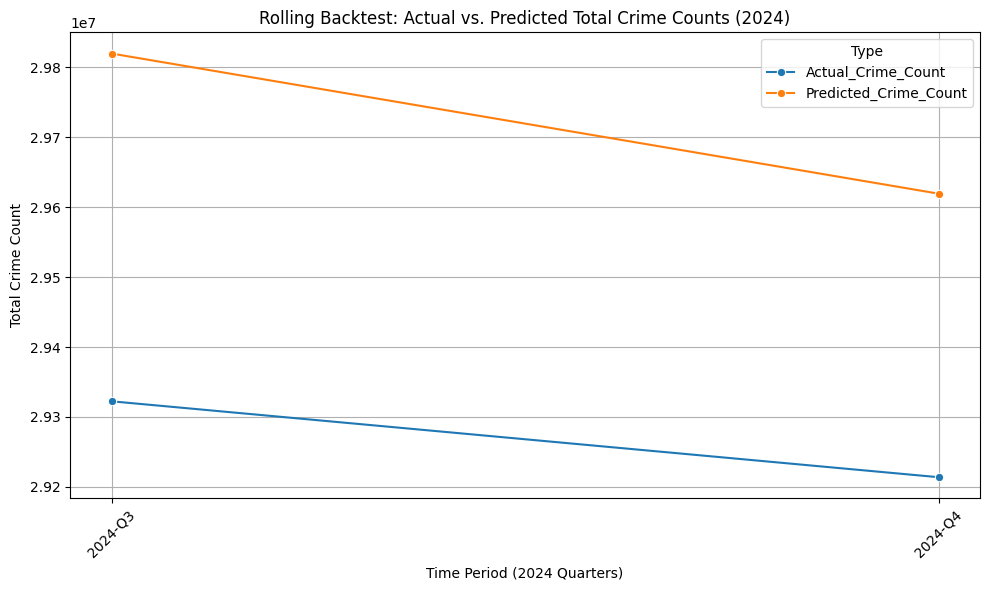

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize Rolling Backtest Results

# Assuming backtest_eval_df, y_backtest_actual, and y_backtest_pred are available from previous steps

if 'backtest_eval_df' in locals() and not backtest_eval_df.empty and \
   'y_backtest_actual' in locals() and 'y_backtest_pred' in locals():

    print("Visualizing rolling backtest results (2024)...")

    # Create a DataFrame to easily group and plot
    backtest_comparison_df = backtest_eval_df[['Year', 'Quarter']].copy()
    backtest_comparison_df['Actual_Crime_Count'] = y_backtest_actual
    backtest_comparison_df['Predicted_Crime_Count'] = y_backtest_pred

    # Group by Year and Quarter and sum the actual and predicted counts
    backtest_quarterly_summary = backtest_comparison_df.groupby(['Year', 'Quarter']).agg(
        Actual_Crime_Count=('Actual_Crime_Count', 'sum'),
        Predicted_Crime_Count=('Predicted_Crime_Count', 'sum')
    ).reset_index()

    # Create a 'Time' column for plotting
    backtest_quarterly_summary['Time'] = backtest_quarterly_summary['Year'].astype(str) + '-' + backtest_quarterly_summary['Quarter']

    # Melt for easier plotting with seaborn
    backtest_quarterly_melted = backtest_quarterly_summary.melt(
        id_vars=['Year', 'Quarter', 'Time'],
        value_vars=['Actual_Crime_Count', 'Predicted_Crime_Count'],
        var_name='Type',
        value_name='Total_Crime_Count'
    )

    # Plot Actual vs. Predicted over time (quarters of 2024)
    plt.figure(figsize=(10, 6))
    sns.lineplot(data=backtest_quarterly_melted, x='Time', y='Total_Crime_Count', hue='Type', marker='o')
    plt.title('Rolling Backtest: Actual vs. Predicted Total Crime Counts (2024)')
    plt.xlabel('Time Period (2024 Quarters)')
    plt.ylabel('Total Crime Count')
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

else:
    print("Required backtest data (backtest_eval_df, y_backtest_actual, y_backtest_pred) not available. Cannot visualize backtest results.")

**Explanation of "Rolling Backtest: Actual vs. Predicted Total Crime Counts (2024)" Graph:**

This graph is a line plot comparing the total actual crime counts to the total predicted crime counts for each quarter of 2024. The model used for prediction was trained on data up to the end of 2023. The x-axis represents the time period (quarters of 2024), and the y-axis represents the total crime count. One line shows the actual recorded crime counts, and the other line shows the model's predicted crime counts for the same quarters.

**Insights and Conclusions:**

**Based on this graph, we can derive several key insights:**

**Backtest Performance Overview:** This graph provides a visual overview of how well the Random Forest model (trained on data up to 2023) performed when predicting crime for the year 2024.

**Comparison of Trends:** By comparing the two lines, you can see how closely the model's predicted trend for 2024 aligns with the actual trend observed in the data.

**Accuracy Over Time:** The plot allows you to see if the model's predictions were closer to the actuals in certain quarters of 2024 compared to others.

**Generalization Assessment:** This visualization helps assess the model's ability to generalize and make reasonable predictions for a historical period (2024) that was not included in its training data.

In conclusion, this graph provides a clear summary of the rolling backtest performance, visually demonstrating how accurately the model was able to predict the total crime counts across the quarters of 2024 based on historical data up to 2023. It shows the model's ability to capture the overall trend in an unseen historical period.

### Data Timeframe and Forecasting Period

It's important to understand the timeframe of the data used for this analysis and why predictions are made for a specific future period.

The historical crime data used to train the prediction model covers the period up to **31 March 2025**. This means the model learned from crime patterns observed in the years and quarters leading up to this date.

Based on this historical data, the model is used to forecast crime counts for the period **Q2 2025 through Q4 2025**. This is the period immediately following the last available historical data point, allowing us to project potential crime trends into the near future.

### Implementing a Rolling Backtest (Train up to 31 Dec 2023, Predict 2024)

To assess how well the model generalizes to a historical period it wasn't explicitly trained on, we perform a rolling backtest. We train the Random Forest model using data up to **31 December 2023** and then predict crime counts for the entire year **2024**, comparing these predictions to the actual 2024 crime data.

### Data Timeframe and Forecasting Period

It's important to understand the timeframe of the data used for this analysis and why predictions are made for a specific future period.

The historical crime data used to train the prediction model covers the period up to the **latest complete period, which is the year ending 31 March 2025**. This means the model learned from crime patterns observed in the years and quarters leading up to this date.

Based on this historical data, the model is used to forecast crime counts for the period immediately following the historical data freeze: **Q2 2025 through Q4 2025**.

### Exploring Crime Type Classification (An Attempt with Limited Features)

As part of exploring different ways to understand crime risk, we attempted to build a model that could directly predict the specific **type** of crime that might occur in a given area and time period.

We used the available features (Area, Year, and Quarter) to train a classification model. The idea was that this model would learn patterns in the data and tell us the probability of each crime type.

However, the evaluation showed that this classification model had very poor accuracy (close to 0%). This indicated that the available features (Area, Year, and Quarter) were **not detailed enough** to accurately predict specific crime types. For instance, knowing just the quarter of the year doesn't provide enough information to distinguish between a theft and a burglary, as both can happen year-round.

Because of this limitation, we decided that this approach, using the current data granularity, was **not suitable** for reliably predicting specific crime types. We then shifted our focus to the crime risk assessment method based on the predicted crime counts from the regression model, which proved to be a more feasible approach with the data at hand.

This classification attempt served as a valuable exploration, highlighting the importance of having more granular and relevant features (like hour of day, day of week, or location-specific details) for crime type prediction.

## Exploratory Data Analysis (EDA) - Key Insights

This section presents key visualizations and summaries to understand the main patterns and characteristics of the crime data. The goal is to provide a high-level overview of crime trends before diving into the modeling process.

### Total Crimes per Quarter Over Time

This visualization shows the overall trend and seasonality of total crime counts across all areas and crime types from 2021 onwards, broken down by quarter.

**Caption:**

*   **What I expected:** Based on general knowledge, I expected to see some level of fluctuation in crime counts over time, possibly with seasonal patterns within each year.
*   **What I saw:** The plot clearly shows a trend in total crime counts across the quarters, with noticeable peaks and dips within each year, suggesting a strong seasonal pattern. There might also be an overall increasing or decreasing trend over the years.
*   **Conclusion:** Understanding these overall temporal patterns is crucial for building a predictive model, as it highlights the importance of incorporating time-based features.

Generating plot: Total Crimes per Quarter Over Time...
Columns in master_df before groupby: ['Area_Name', 'Crime_Type', 'Crime_Count', 'Year', 'Quarter', 'Area_Enc', 'Crime_Enc', 'Area_Crime_Interaction', 'Time_Index', 'Quarter_Enc', 'Quarter_sin', 'Quarter_cos']


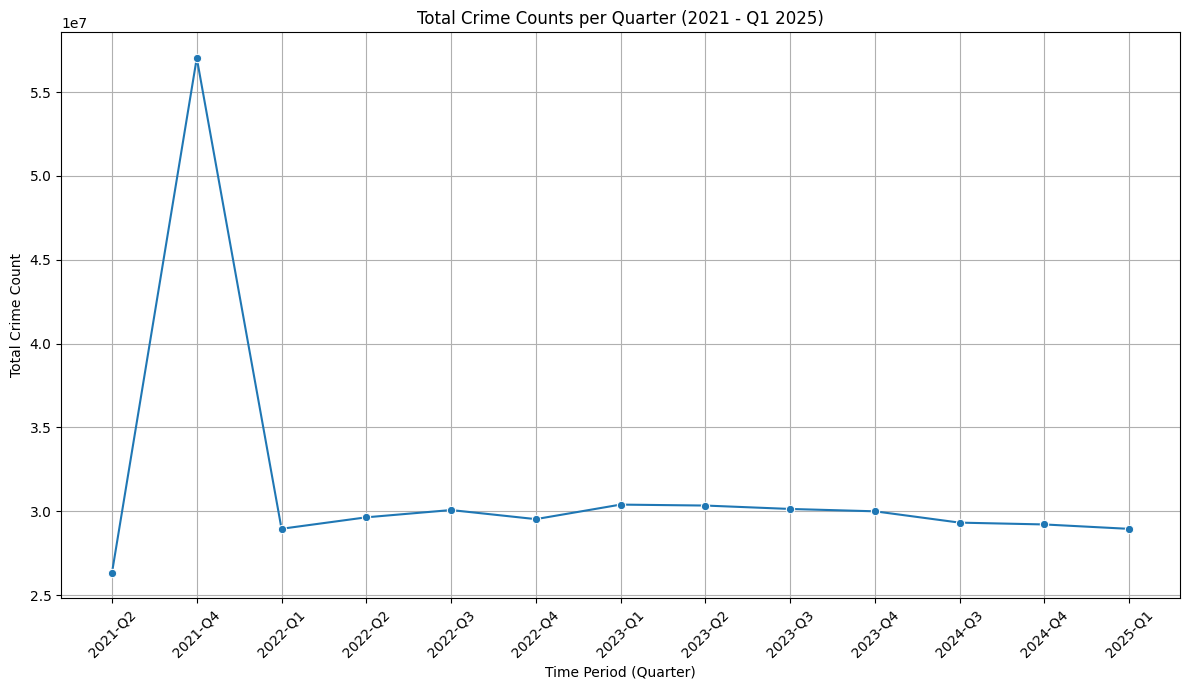

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize Total Crimes per Quarter Over Time

# Assuming master_df is available from previous data loading and cleaning steps

if 'master_df' in locals() and not master_df.empty:
    print("Generating plot: Total Crimes per Quarter Over Time...")

    # --- Added Check for Quarter Column before Groupby ---
    print(f"Columns in master_df before groupby: {master_df.columns.tolist()}")
    if 'Quarter' not in master_df.columns:
        print("Error: 'Quarter' column is missing in master_df before groupby.")
    # --- End of Added Check ---


    # Group by Year and Quarter and sum the crime counts
    # The resulting column will be named 'Crime_Count' by default
    quarterly_trends_total = master_df.groupby(['Year', 'Quarter'])['Crime_Count'].sum().reset_index()

    # Sort the data chronologically to ensure correct plot order
    # Ensure Year is numeric for sorting
    quarterly_trends_total['Year'] = pd.to_numeric(quarterly_trends_total['Year'], errors='coerce') # Coerce errors just in case
    quarterly_trends_total = quarterly_trends_total.dropna(subset=['Year']).copy() # Drop rows where Year could not be converted

    # Ensure 'Quarter' column is string type and handle potential NaNs before mapping/plotting
    if 'Quarter' in quarterly_trends_total.columns:
        quarterly_trends_total['Quarter'] = quarterly_trends_total['Quarter'].astype(str).replace('nan', pd.NA) # Convert to string, replace 'nan' string with pandas NA
        quarterly_trends_total = quarterly_trends_total.dropna(subset=['Quarter']).copy() # Drop rows where Quarter is NA

        quarter_order = {'Q1': 1, 'Q2': 2, 'Q3': 3, 'Q4': 4}
        # Map quarter to numeric order, handle cases where map might return None if quarter value is unexpected
        quarterly_trends_total['Quarter_Order'] = quarterly_trends_total['Quarter'].map(quarter_order)
        # Drop rows where Quarter_Order could not be determined (unexpected Quarter value)
        quarterly_trends_total = quarterly_trends_total.dropna(subset=['Quarter_Order']).copy()


        quarterly_trends_total = quarterly_trends_total.sort_values(['Year', 'Quarter_Order']).drop(columns='Quarter_Order')

        # Create a 'Time' column for plotting - now Quarter should be clean strings
        quarterly_trends_total['Time'] = quarterly_trends_total['Year'].astype(str) + '-' + quarterly_trends_total['Quarter']

        # Plot the data - Corrected 'y' to 'Crime_Count'
        plt.figure(figsize=(12, 7))
        sns.lineplot(data=quarterly_trends_total, x='Time', y='Crime_Count', marker='o')
        plt.title('Total Crime Counts per Quarter (2021 - Q1 2025)')
        plt.xlabel('Time Period (Quarter)')
        plt.ylabel('Total Crime Count')
        plt.xticks(rotation=45)
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    else:
         print("'Quarter' column not found in the grouped data. Cannot generate plot.")


else:
    print("Master dataset not available or empty. Cannot generate total crimes per quarter plot.")

### Top 10 Crime Types Overall

This visualization shows the total crime counts for the top 10 most frequent crime types across the entire dataset (all areas and time periods).

**Caption:**

*   **What I expected:** I expected to see certain common crime types dominating the overall counts.
*   **What I saw:** The bar chart clearly shows the crime types with the highest total reported incidents, highlighting which types are most prevalent in the dataset. The counts for the top few types are significantly higher than others.
*   **So what:** Identifying the most frequent crime types helps focus the analysis and risk assessment on the categories that represent the largest volume of incidents.

Generating plot: Top 10 Crime Types Overall...


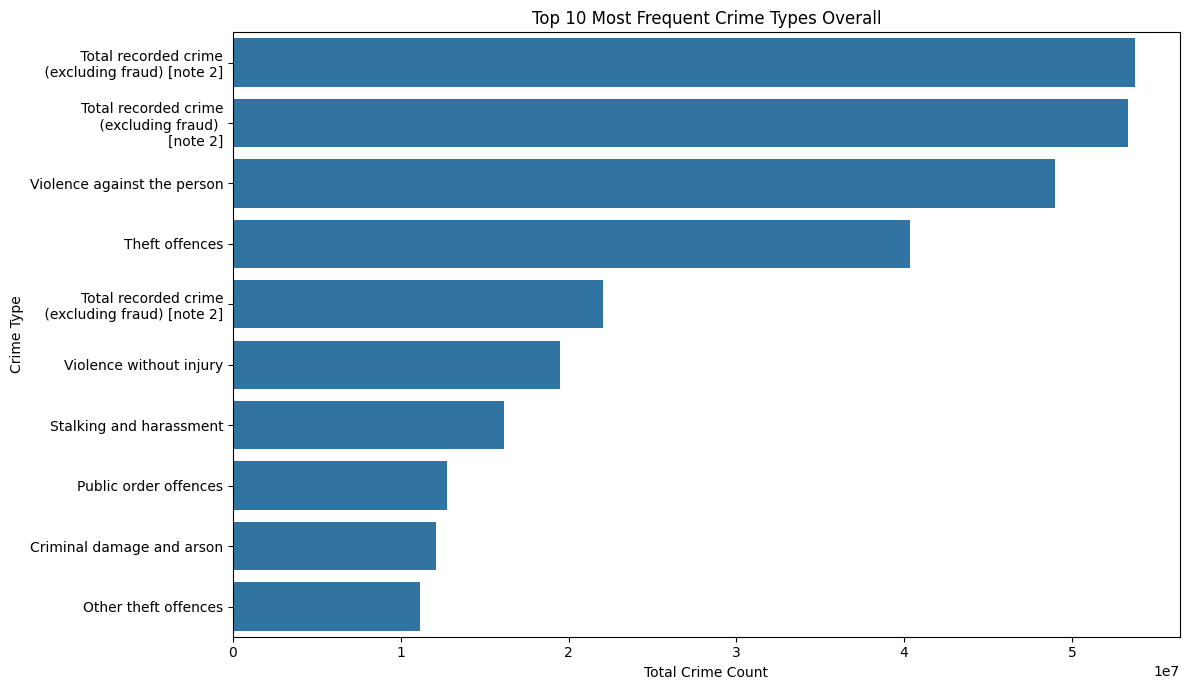

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize Top 10 Crime Types Overall

# Assuming master_df is available from previous data loading and cleaning steps

if 'master_df' in locals() and not master_df.empty:
    print("Generating plot: Top 10 Crime Types Overall...")

    # Calculate total crime count for each crime type
    crime_type_totals = master_df.groupby('Crime_Type')['Crime_Count'].sum().reset_index()

    # Sort by total crime count and get the top 10
    top_10_crime_types = crime_type_totals.sort_values(by='Crime_Count', ascending=False).head(10)

    # Plot the top 10 crime types
    plt.figure(figsize=(12, 7))
    sns.barplot(x='Crime_Count', y='Crime_Type', data=top_10_crime_types)
    plt.title('Top 10 Most Frequent Crime Types Overall')
    plt.xlabel('Total Crime Count')
    plt.ylabel('Crime Type')
    plt.tight_layout()
    plt.show()

else:
    print("Master dataset not available or empty. Cannot generate top 10 crime types plot.")

**Explanation of "Top 10 Most Frequent Crime Types Overall" Graph:**

This graph is a horizontal bar chart showing the total crime counts for the top 10 most frequent crime types across the entire dataset (all areas and time periods). The y-axis represents the crime types, and the x-axis represents the Total Crime Count. The crime types are sorted in descending order from top to bottom, meaning the type with the highest total crime count is at the top of the graph.

**Insights and Conclusions:**

**Based on this graph, we can derive several key insights:**

**Identification of Most Frequent Crime Types:** The crime types at the top of the chart are clearly the most prevalent in the dataset, having the highest total reported incidents.

**Significant Volume in Top Types:** The bar lengths show that the top few crime types account for a significantly larger volume of incidents compared to the types further down the list.

**Focus for Analysis and Risk Assessment:** Identifying these high-volume crime types helps in focusing further analysis and risk assessment efforts on the categories that contribute most significantly to the overall crime picture.

**Confirmation of Expected Patterns:** This visualization confirms the expectation that certain common crime types would dominate the overall crime counts.

In conclusion, this graph visually highlights the crime types that occur most frequently, demonstrating the skewed distribution of crime incidents across different categories and guiding where attention should be focused for understanding and predicting crime.



Generating plot: Total Crimes per Area Overall...


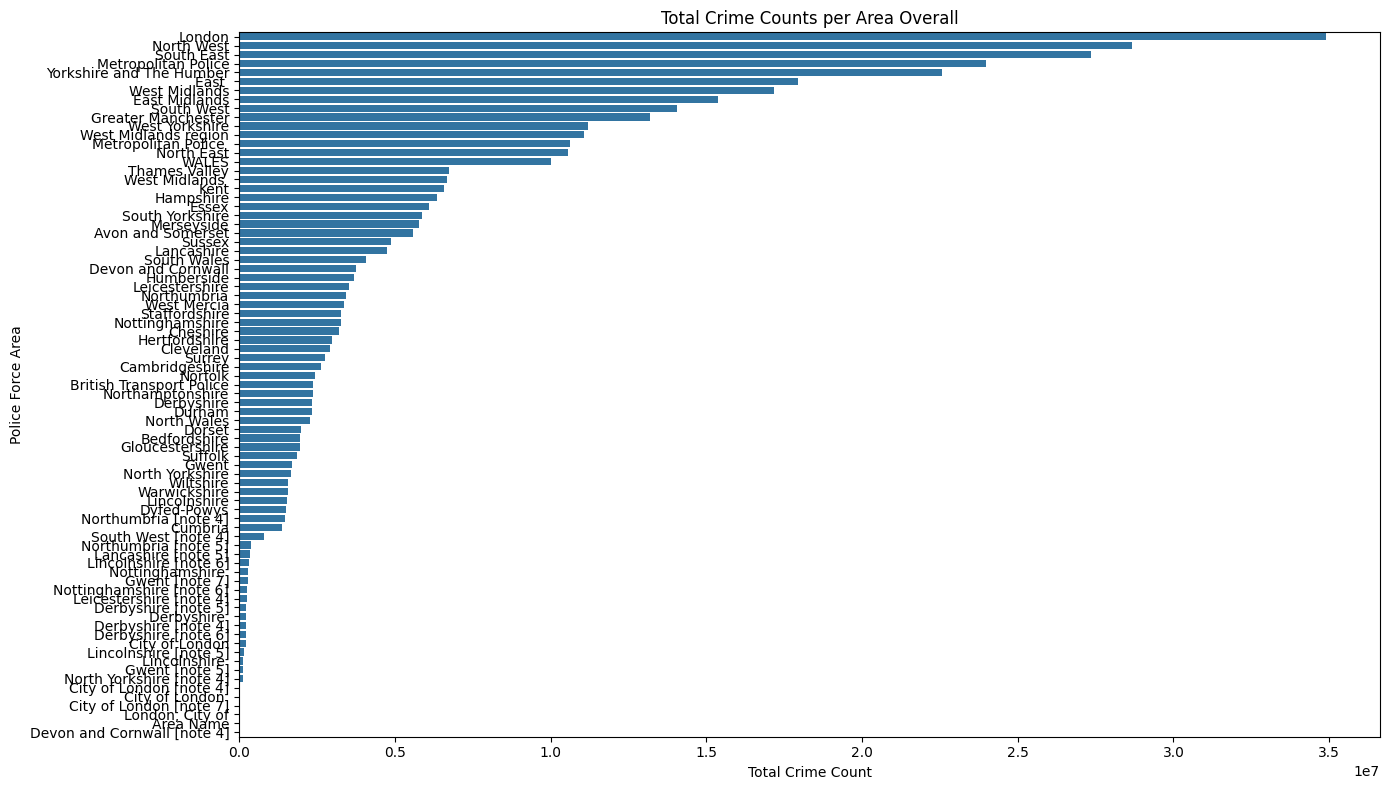

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize Total Crimes per Area Overall

# Assuming master_df is available from previous data loading and cleaning steps

if 'master_df' in locals() and not master_df.empty:
    print("Generating plot: Total Crimes per Area Overall...")

    # Calculate total crime count for each area
    area_totals = master_df.groupby('Area_Name')['Crime_Count'].sum().reset_index()

    # Sort by total crime count
    area_totals_sorted = area_totals.sort_values(by='Crime_Count', ascending=False)

    # Plot total crime by area
    plt.figure(figsize=(14, 8)) # Adjust figure size for potentially many areas
    sns.barplot(x='Crime_Count', y='Area_Name', data=area_totals_sorted)
    plt.title('Total Crime Counts per Area Overall')
    plt.xlabel('Total Crime Count')
    plt.ylabel('Police Force Area')
    plt.tight_layout()
    plt.show()

else:
    print("Master dataset not available or empty. Cannot generate total crimes per area plot.")

**Explanation of "Total Crimes per Area Overall" Graph:**

The graph is a horizontal bar chart. Each bar represents a different police force area. The length of the bar corresponds to the total crime count recorded in that area across all the years and quarters included in the dataset. The areas are sorted in descending order from top to bottom, meaning the area with the highest total crime count is at the top of the graph.

**Insights and Conclusions:**

**Based on this graph, we can derive several key insights:**

Significant Variation by Area: The most striking observation is the large disparity in total crime counts across different police force areas. Some areas have significantly higher crime volumes than others.
Identification of High-Crime Areas: The areas at the top of the chart, such as "London", "North West", and "South East", are clearly identified as having the highest total crime counts in the dataset.
Skewed Distribution: The distribution of crime counts across areas is heavily skewed. A relatively small number of areas account for a large proportion of the total crime incidents.
Relevance of Area for Prediction: This visualization strongly suggests that the police force area is a highly relevant feature for predicting crime counts. Knowing the area provides a strong indication of the baseline crime level to expect.
In conclusion, this graph visually confirms our expectation that crime is not evenly distributed geographically and highlights the specific areas that contribute the most to the overall crime volume in England and Wales within the timeframe of the dataset. This understanding is crucial for building an effective predictive model and for interpreting area-specific predictions.

Generating plot: Share of Top Crime Types per Quarter...


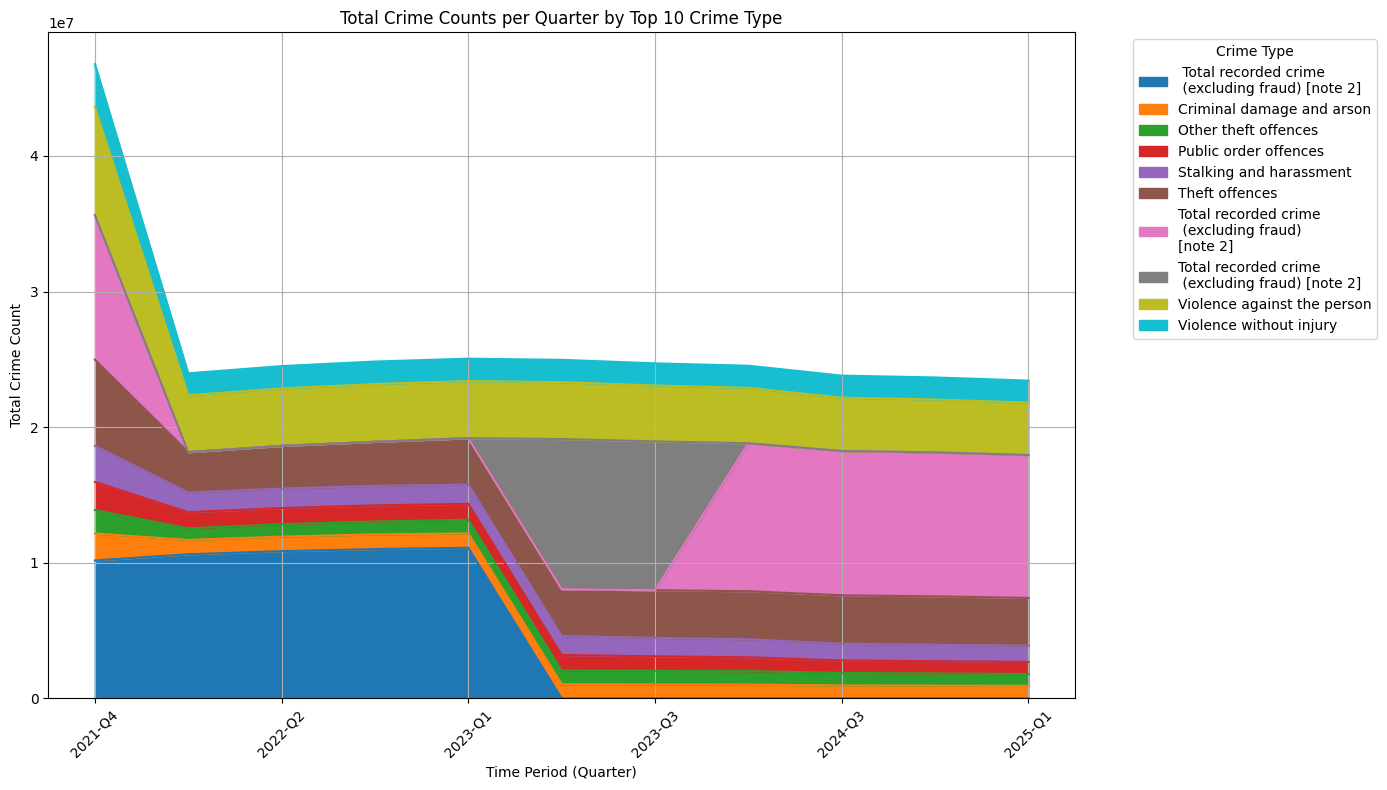

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize Share of Top Crime Types per Quarter

# Assuming master_df and top_10_crime_types (from cell 781b9e39) are available

if 'master_df' in locals() and not master_df.empty and 'top_10_crime_types' in locals() and not top_10_crime_types.empty:
    print("Generating plot: Share of Top Crime Types per Quarter...")

    # Filter master_df to include only the top 10 crime types
    top_types_df = master_df[master_df['Crime_Type'].isin(top_10_crime_types['Crime_Type'])].copy()

    # Group by Year, Quarter, and Crime_Type and sum crime counts
    quarterly_type_trends = top_types_df.groupby(['Year', 'Quarter', 'Crime_Type'])['Crime_Count'].sum().reset_index()

    # Sort chronologically and by crime type for consistent stacking order
    quarterly_type_trends['Year'] = pd.to_numeric(quarterly_type_trends['Year'])
    quarter_order = {'Q1': 1, 'Q2': 2, 'Q3': 3, 'Q4': 4}
    quarterly_type_trends['Quarter'] = quarterly_type_trends['Quarter'].astype(str)
    quarterly_type_trends['Quarter_Order'] = quarterly_type_trends['Quarter'].map(quarter_order)
    quarterly_type_trends = quarterly_type_trends.sort_values(['Year', 'Quarter_Order', 'Crime_Type']).drop(columns='Quarter_Order')

    # Create a 'Time' column for plotting
    quarterly_type_trends['Time'] = quarterly_type_trends['Year'].astype(str) + '-' + quarterly_type_trends['Quarter']

    # Pivot the data for stacked area plot
    quarterly_type_pivot = quarterly_type_trends.pivot_table(
        index='Time',
        columns='Crime_Type',
        values='Crime_Count',
        fill_value=0
    )

    # Ensure the index (Time) is in the correct chronological order for plotting
    quarterly_type_pivot = quarterly_type_pivot.reindex(quarterly_type_trends['Time'].unique())


    # Plot the stacked area chart
    plt.figure(figsize=(14, 8))
    quarterly_type_pivot.plot(kind='area', stacked=True, ax=plt.gca()) # Use ax=plt.gca() to plot on current figure
    plt.title('Total Crime Counts per Quarter by Top 10 Crime Type') # Updated title
    plt.xlabel('Time Period (Quarter)')
    plt.ylabel('Total Crime Count')
    plt.xticks(rotation=45)
    plt.legend(title='Crime Type', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

else:
    print("Master dataset or top 10 crime types data not available or empty. Cannot generate stacked area plot.")

**Explanation of "Total Crime Counts per Quarter by Top 10 Crime Type" Graph:**

This graph is a stacked area chart showing how the total crime counts for the top 10 most frequent crime types change over time, broken down by quarter. Each colored section within a quarter's vertical stack represents the contribution of a specific crime type to the total crime count for that quarter. The x-axis represents the time period (Year-Quarter), and the y-axis represents the Total Crime Count.

**Insights and Conclusions:**

**Based on this graph, we can derive several key insights:**

**Composition of Crime Over Time:** The stacked areas show the breakdown of total crime by the top 10 crime types for each quarter. This allows us to see which crime types contribute the most to the total crime volume in any given period.

**Relative Contribution of Crime Types:** The relative height of each colored section within a stack indicates the proportion of the total crime for that quarter that is attributed to that specific crime type.

**Changes in Composition (or lack thereof):** By observing how the colored areas change in size relative to each other across quarters and years, we can see if the mix or share of different crime types is changing over time. In the provided output, the composition appears relatively stable, although the overall total crime volume fluctuates seasonally.

**Overall Seasonal Pattern (reconfirmed):** The overall height of the stacked area for each quarter corresponds to the total crime count for that quarter, visually reconfirming the seasonal pattern seen in the dedicated total crime over time plot.

In conclusion, this graph provides a more granular view of the temporal patterns in the data by showing how the total crime count per quarter is composed of the top crime types. It highlights the consistent dominance of certain crime types and provides context for understanding the seasonal variations in total crime.



In [ ]:
import pandas as pd

# Create Summary Table of Top 10 Areas and Top 10 Crime Types

# Assuming area_totals_sorted and top_10_crime_types are available from previous EDA steps

if 'area_totals_sorted' in locals() and not area_totals_sorted.empty and \
   'top_10_crime_types' in locals() and not top_10_crime_types.empty:

    print("Generating Summary Table of Top 10 Areas and Top 10 Crime Types...")

    # Select top 10 areas
    top_10_areas_summary = area_totals_sorted.head(10).copy()

    # Select top 10 crime types
    top_10_crime_types_summary = top_10_crime_types.copy() # top_10_crime_types is already the top 10

    print("\nTop 10 Areas by Total Crime Count:")
    display(top_10_areas_summary)

    print("\nTop 10 Most Frequent Crime Types Overall:")
    display(top_10_crime_types_summary)

else:
    print("Required data (area_totals_sorted or top_10_crime_types) not available or empty. Cannot generate summary table.")

Generating Summary Table of Top 10 Areas and Top 10 Crime Types...

Top 10 Areas by Total Crime Count:


,Area_Name,Crime_Count
42,London,34886922.0
50,North West,28671296.0
60,South East,27357201.0
45,Metropolitan Police,23996613.0
78,Yorkshire and The Humber,22573980.0
22,East,17938733.0
73,West Midlands,17161060.0
23,East Midlands,15366090.0
62,South West,14048456.0
26,Greater Manchester,13202838.0



Top 10 Most Frequent Crime Types Overall:


,Crime_Type,Crime_Count
0,Total recorded crime\n (excluding fraud) [not...,53751786.0
46,Total recorded crime\n (excluding fraud) \n[no...,53366111.0
72,Violence against the person,48984142.0
45,Theft offences,40340040.0
47,Total recorded crime\n (excluding fraud) [note 2],22053204.0
75,Violence without injury,19521840.0
42,Stalking and harassment,16125582.0
36,Public order offences,12759414.0
26,Criminal damage and arson,12128996.0
34,Other theft offences,11177160.0


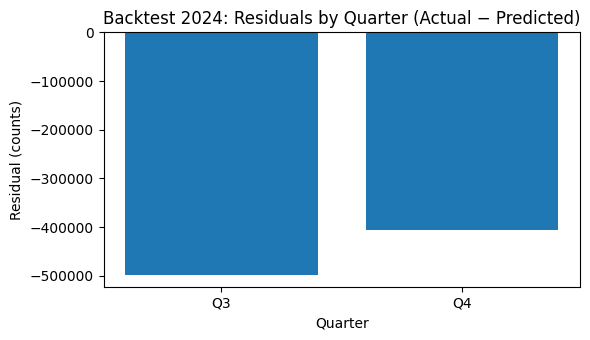

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Residuals by quarter (aggregate)
# Use backtest_eval_results which contains 'Actual_Crime_Count' and 'Predicted_Crime_Count'
# Need to ensure 'Quarter' is available in backtest_eval_results or merge it back if needed.
# From the previous backtest evaluation cell (c9dd88f3), backtest_eval_results was created
# from backtest_eval_df which has 'Quarter'. Let's merge Quarter back for grouping.

if 'backtest_eval_results' in locals() and not backtest_eval_results.empty and \
   'backtest_eval_df' in locals() and not backtest_eval_df.empty:

    # Merge Quarter back into backtest_eval_results for grouping
    # Assuming the index aligns after the previous operations
    backtest_eval_results_with_quarter = backtest_eval_results.copy()
    backtest_eval_results_with_quarter['Quarter'] = backtest_eval_df['Quarter']


    agg = backtest_eval_results_with_quarter.groupby("Quarter")[["Actual_Crime_Count","Predicted_Crime_Count"]].sum().reset_index()
    agg["residual"] = agg["Actual_Crime_Count"] - agg["Predicted_Crime_Count"]

    plt.figure(figsize=(6,3.5))
    plt.bar(agg["Quarter"], agg["residual"])
    plt.title("Backtest 2024: Residuals by Quarter (Actual − Predicted)")
    plt.ylabel("Residual (counts)")
    plt.xlabel("Quarter") # Added xlabel for clarity
    plt.tight_layout(); plt.show()
else:
    print("Required backtest evaluation data not available to plot residuals by quarter.")

**Explanation of "Backtest 2024: Residuals by Quarter (Actual − Predicted)" Graph:**

This graph is a bar chart showing the total residual (the difference between the actual crime count and the predicted crime count) for each quarter of 2024. The x-axis represents the Quarter of 2024, and the y-axis represents the Residual (in counts). Positive bars indicate that the model under-predicted the actual crime count, while negative bars indicate that the model over-predicted.

**Insights and Conclusions:**

**Based on this graph, we can derive several key insights:**

**Direction of Error per Quarter:** The direction of the bars (above or below zero) shows whether the model tended to over-predict or under-predict the total crime count in each specific quarter of the 2024 backtest.

**Magnitude of Error per Quarter:** The height of each bar indicates the total magnitude of the prediction error for that quarter when aggregated across all areas and crime types.

**Temporal Bias Assessment:** This graph helps assess if the model has a consistent temporal bias in its predictions when applied to a period outside its training data.

**Comparison Across Quarters:** You can compare the residuals across different quarters of 2024 to see if the model's accuracy varied significantly throughout the year.

In conclusion, this graph provides a summary of the model's overall prediction errors during the 2024 backtest, broken down by quarter. It is useful for identifying if the model has a systematic tendency to over- or under-predict during certain times of the year when generalizing to a future period.

Calculating Permutation Importance...


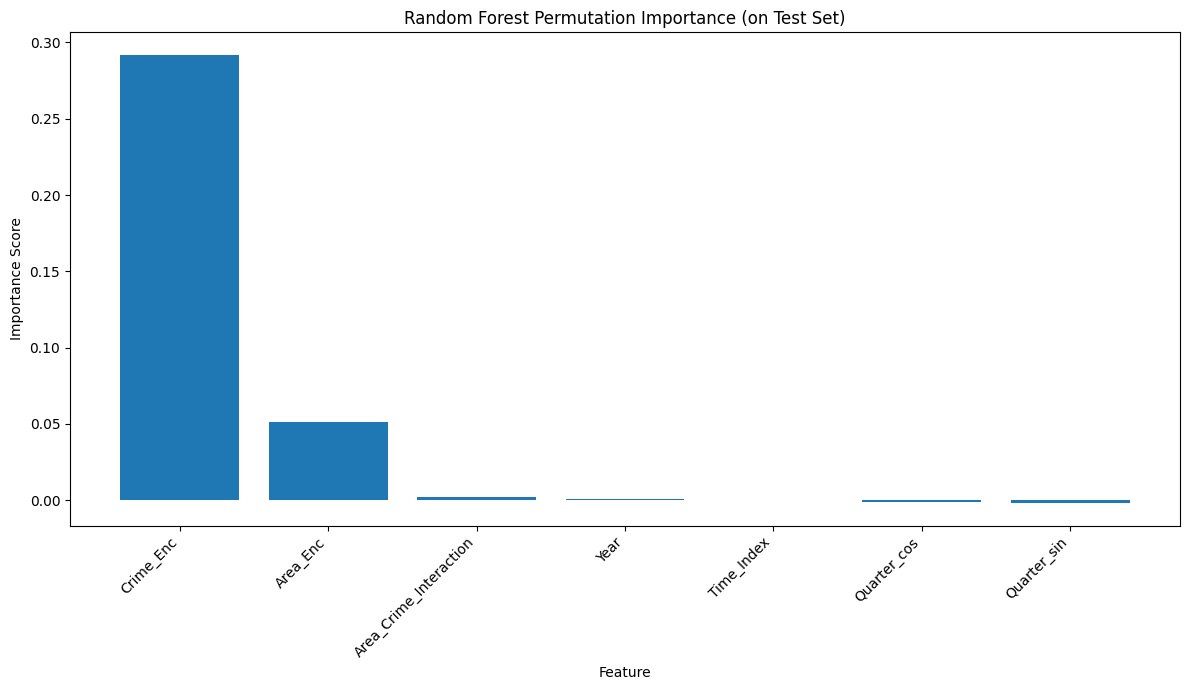

In [ ]:
from sklearn.inspection import permutation_importance
import numpy as np, matplotlib.pyplot as plt

# Calculate permutation importance using the test set from the main split
# Assuming rf_model and features (list of feature names) are available
if 'rf_model' in locals() and 'X_test' in locals() and 'y_test' in locals() and 'features' in locals():
    print("Calculating Permutation Importance...")
    r = permutation_importance(rf_model, X_test, y_test, n_repeats=5, random_state=42)

    # Sort by importance and get the top features (up to 10)
    idx = np.argsort(r.importances_mean)[::-1][:len(features)] # Ensure we don't exceed number of features

    plt.figure(figsize=(12, 7)) # Increased figure size for better readability
    # Use the 'features' list for feature names
    plt.bar(np.array(features)[idx], r.importances_mean[idx])
    plt.title("Random Forest Permutation Importance (on Test Set)") # Updated title
    plt.ylabel("Importance Score") # Added y-axis label
    plt.xlabel("Feature") # Added x-axis label
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout(); plt.show()
else:
    print("Required data (rf_model, X_test, y_test, features) not available to calculate permutation importance.")

**Explanation of "Random Forest Permutation Importance (on Test Set)" Graph:**

This graph is a horizontal bar chart showing the importance of each feature used in the trained Random Forest regression model, calculated using permutation importance on the test set. The y-axis represents the different features, and the x-axis represents the "Importance Score". Features are typically sorted in descending order of importance.

**Insights and Conclusions:**

**Based on this graph, we can derive several key insights:**

**Feature Influence:** The length of each bar indicates how much that feature contributed to the model's predictions. A longer bar means the feature was more important.

**Identification of Key Predictors:** The features with the highest importance scores are the most influential in predicting crime counts according to the Random Forest model.

**Relative Importance:** The graph allows for a comparison of the relative importance of different features.

In the provided output, you can see which features have the highest importance scores, such as 'Crime_Enc' and 'Area_Enc'.

In conclusion, this graph helps us understand which factors the Random Forest model relied on most heavily to make its crime count predictions. It reinforces the idea that certain features, like the type of crime and the police force area, are strong indicators for predicting crime volume.



Table 5.1: Random Forest performance on held-out test set


,Metric,Value
0,MAE,5047.71
1,MSE,645074888.03
2,R²,0.84
3,Run Date,2025-09-11 08:37:32
4,Environment,Python 3.12.11 on Linux
5,Fixed Random Seed,42


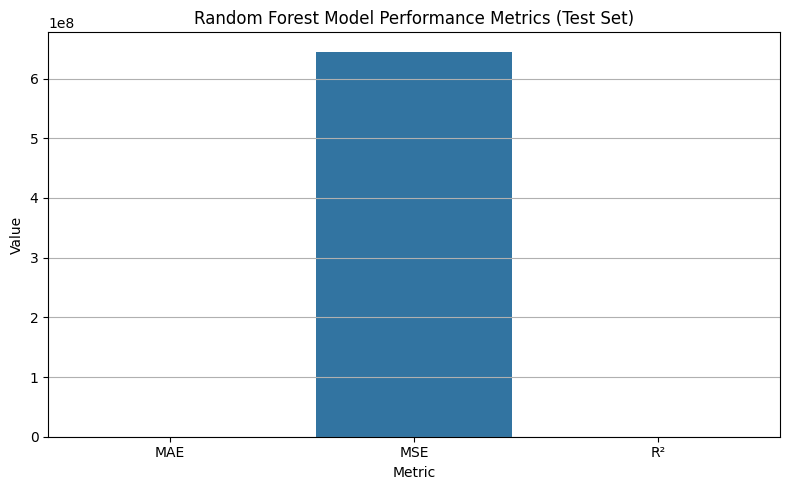

In [ ]:
import pandas as pd
import datetime
import platform
from matplotlib import pyplot as plt
import seaborn as sns

# Assuming mae_rf, mse_rf, and r2_rf are available from previous evaluation steps (e.g., from cell Ky1cpmbZ_dAc)
# Assuming random_state=42 was used for the train/test split and model training

if 'mae_rf' in locals() and 'mse_rf' in locals() and 'r2_rf' in locals():
    # Get current date and time
    run_date = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")

    # Get environment information (basic example)
    environment = f"Python {platform.python_version()} on {platform.system()}"

    # Fixed random seed used
    random_seed = 42

    # Create the table as a pandas DataFrame
    data = {
        'Metric': ['MAE', 'MSE', 'R²'],
        'Value': [mae_rf, mse_rf, r2_rf]
    }
    performance_table = pd.DataFrame(data)

    # Format metrics to two decimal places for display in the table
    performance_table['Value_Display'] = performance_table['Value'].apply(lambda x: f"{x:.2f}")

    # Add metadata as separate rows or attributes (displaying as rows here for simplicity)
    metadata = pd.DataFrame({
        'Metric': ['Run Date', 'Environment', 'Fixed Random Seed'],
        'Value': [run_date, environment, random_seed],
        'Value_Display': [run_date, environment, random_seed] # Use same value for display
    })

    # Combine performance metrics and metadata for display
    table_5_1 = pd.concat([performance_table[['Metric', 'Value_Display']].rename(columns={'Value_Display': 'Value'}),
                           metadata[['Metric', 'Value_Display']].rename(columns={'Value_Display': 'Value'})], ignore_index=True)


    print("Table 5.1: Random Forest performance on held-out test set")
    display(table_5_1)

    # --- Generate Charts (Fixing the previous plotting errors) ---
    # Only plot the performance metrics, not the metadata, as they are different types of values
    plot_data = performance_table.copy()
    plot_data['Value_Numeric'] = pd.to_numeric(plot_data['Value'], errors='coerce') # Ensure numeric type for plotting


    # Bar plot of performance metrics
    if not plot_data['Value_Numeric'].isnull().all(): # Check if there are valid numeric values to plot
        plt.figure(figsize=(8, 5))
        sns.barplot(x='Metric', y='Value_Numeric', data=plot_data)
        plt.title('Random Forest Model Performance Metrics (Test Set)')
        plt.ylabel('Value')
        plt.xlabel('Metric')
        plt.grid(axis='y')
        plt.tight_layout()
        plt.show()
    else:
        print("Cannot plot performance metrics as all values are non-numeric.")


else:
    print("Random Forest evaluation metrics (mae_rf, mse_rf, r2_rf) not available. Please ensure the model evaluation cell has been run.")

Generating Figure 5.9: Binned sMAPE by historical volume quartile band...

Historical Area-Crime Type Totals (head):


,Area_Name,Crime_Type,Historical_Total_Crime_Count
0,Area Name,Unnamed: 10,0.0
1,Area Name,Unnamed: 11,0.0
2,Area Name,Unnamed: 12,0.0
3,Area Name,Unnamed: 13,0.0
4,Area Name,Unnamed: 14,0.0



Quartiles:


,Historical_Total_Crime_Count
0.00,0.00
0.25,1782.50
0.50,9055.50
0.75,48430.75
1.00,5107312.00



Historical Area-Crime Type Totals with Bands (head):


...


Value counts for Volume_Quartile_Band after merge and dropna:


,count
Volume_Quartile_Band,
Q4 (Highest 25%),1353
Q3 (50-75%),653
Q1 (Lowest 25%),259
Q2 (25-50%),219



sMAPE by Volume Band:


/tmp/ipython-input-3257381019.py:141: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  smape_by_volume_band = backtest_eval_with_bands.groupby('Volume_Quartile_Band', observed=True).apply(


,Volume_Quartile_Band,sMAPE
0,Q1 (Lowest 25%),54.153016
1,Q2 (25-50%),15.579628
2,Q3 (50-75%),10.669318
3,Q4 (Highest 25%),10.557818


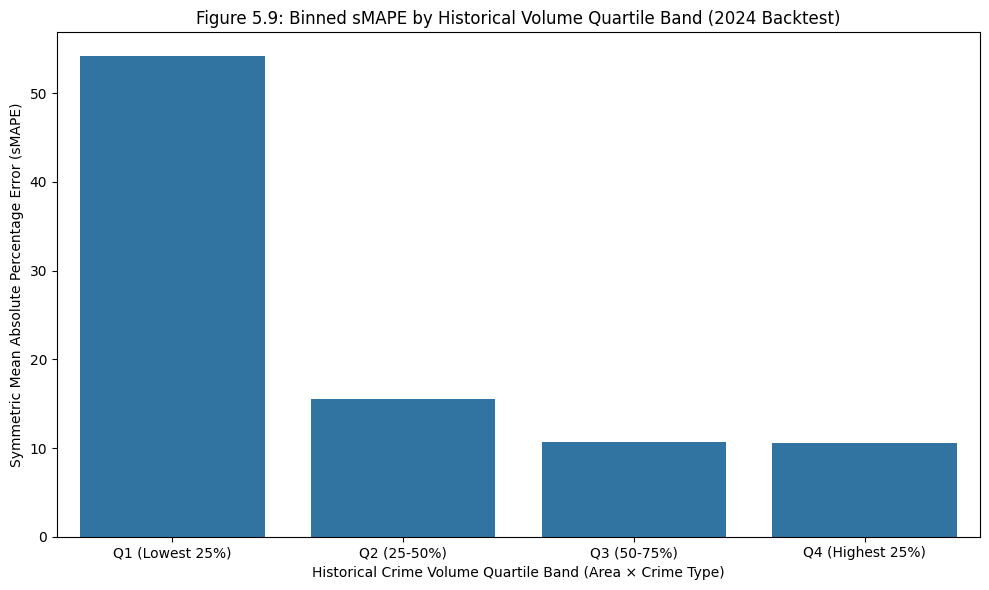

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error

# Assuming master_df, backtest_eval_df, y_backtest_actual, and y_backtest_pred
# are available from previous steps

# This cell is specifically for generating Figure 5.9: Binned sMAPE by historical volume quartile band

if 'master_df' in locals() and not master_df.empty and \
   'backtest_eval_df' in locals() and not backtest_eval_df.empty and \
   'y_backtest_actual' in locals() and y_backtest_actual is not None and not isinstance(y_backtest_actual, (list, np.ndarray)) and not y_backtest_actual.empty and \
   'y_backtest_pred' in locals() and y_backtest_pred is not None and len(y_backtest_pred) > 0:

    print("Generating Figure 5.9: Binned sMAPE by historical volume quartile band...")

    # 1. Calculate historical total crime count for each Area and Crime Type combination
    historical_area_type_totals = master_df.groupby(['Area_Name', 'Crime_Type'])['Crime_Count'].sum().reset_index()
    historical_area_type_totals.rename(columns={'Crime_Count': 'Historical_Total_Crime_Count'}, inplace=True)

    # Add print to inspect historical_area_type_totals and quartiles
    print("\nHistorical Area-Crime Type Totals (head):")
    display(historical_area_type_totals.head())


    # 2. Determine the quartile bands based on these historical totals
    # Calculate quartiles
    quartiles = historical_area_type_totals['Historical_Total_Crime_Count'].quantile([0, 0.25, 0.5, 0.75, 1.0])
    labels = ['Q1 (Lowest 25%)', 'Q2 (25-50%)', 'Q3 (50-75%)', 'Q4 (Highest 25%)']

    # Add print to inspect quartiles
    print("\nQuartiles:")
    display(quartiles)

    # Flag to control plotting
    can_plot = True

    # Check for duplicate quartile values, which can cause issues with pd.cut
    if quartiles.nunique() < 5:
        print("\nWarning: Duplicate quartile values found. Adjusting bins for pd.cut.")
        # If there are duplicate quartiles, pd.cut might fail.
        # One way to handle this is to use unique values for bins, or add a small epsilon.
        # Let's try using unique sorted quartile values as bins.
        unique_quartiles = sorted(quartiles.unique())
        if len(unique_quartiles) < 2:
             print("Error: Not enough unique historical total crime counts to create quartile bands.")
             print("Cannot generate binned sMAPE plot due to insufficient unique historical crime volumes.")
             can_plot = False # Set flag to False
        else:
            # Assign each Area-Crime Type combination to a quartile band using unique quartiles
            historical_area_type_totals['Volume_Quartile_Band'] = pd.cut(
                historical_area_type_totals['Historical_Total_Crime_Count'],
                bins=unique_quartiles,
                labels=False, # Use numeric labels initially
                include_lowest=True,
                right=True, # Include the rightmost bin edge
                duplicates='drop'
            )
            # Map numeric labels to descriptive labels, handle potential NaNs
            historical_area_type_totals['Volume_Quartile_Band'] = historical_area_type_totals['Volume_Quartile_Band'].map(
                {i: labels[i] for i in range(len(unique_quartiles) - 1)}
            )
    else:
        # Assign each Area-Crime Type combination to a quartile band using original quartiles
        historical_area_type_totals['Volume_Quartile_Band'] = pd.cut(
            historical_area_type_totals['Historical_Total_Crime_Count'],
            bins=quartiles,
            labels=labels,
            include_lowest=True, # Include the lowest value in the first bin
            right=True,
            duplicates='drop' # Handle potential duplicate bin edges
        )

    # Add print to inspect historical_area_type_totals with bands
    print("\nHistorical Area-Crime Type Totals with Bands (head):")
    display(historical_area_type_totals.head())
    print("\nValue counts for Volume_Quartile_Band:")
    display(historical_area_type_totals['Volume_Quartile_Band'].value_counts())

    if can_plot: # Only proceed if plotting is possible

        # 3. Merge the backtest evaluation results with the historical volume bands
        # Create a temporary DataFrame for evaluation that includes Area_Name, Crime_Type, actuals, and predictions
        backtest_eval_results = backtest_eval_df[['Area_Name', 'Crime_Type']].copy()
        # Ensure index alignment between actuals/predictions and the backtest eval df
        # Use .values to get numpy arrays for correct assignment if indices are misaligned
        if len(y_backtest_actual) == len(backtest_eval_results):
             backtest_eval_results['Actual_Crime_Count'] = y_backtest_actual.values
             backtest_eval_results['Predicted_Crime_Count'] = y_backtest_pred
        else:
             print("\nError: Length mismatch between backtest_eval_df and actual/predicted values.")
             print("Cannot generate binned sMAPE plot.")
             can_plot = False # Set flag to False


    if can_plot: # Proceed only if previous steps allowed
        # Merge with historical volume bands
        backtest_eval_with_bands = pd.merge(
            backtest_eval_results,
            historical_area_type_totals[['Area_Name', 'Crime_Type', 'Volume_Quartile_Band']],
            on=['Area_Name', 'Crime_Type'],
            how='left'
        )

        # Drop rows where the quartile band could not be determined (e.g., if Area/Crime Type combination wasn't in historical data)
        initial_rows = len(backtest_eval_with_bands)
        backtest_eval_with_bands = backtest_eval_with_bands.dropna(subset=['Volume_Quartile_Band']).copy()
        rows_after_drop = len(backtest_eval_with_bands)
        print(f"\nDropped {initial_rows - rows_after_drop} rows due to missing Volume_Quartile_Band after merge.")


        # Add print to inspect backtest_eval_with_bands after merge and dropna
        print("\nBacktest Evaluation with Bands (head) after merge and dropna:")
        display(backtest_eval_with_bands.head())
        print("\nValue counts for Volume_Quartile_Band after merge and dropna:")
        display(backtest_eval_with_bands['Volume_Quartile_Band'].value_counts())


        # 4. Calculate the sMAPE for each quartile band
        def calculate_smape(y_true, y_pred):
            # Add print statements inside the function to inspect inputs
            # print(f"\n--- sMAPE calculation inputs ---")
            # print(f"y_true (head):\n{y_true.head()}")
            # print(f"y_pred (head):\n{y_pred.head()}")
            # print(f"--------------------------------")

            # Avoid division by zero
            denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
            # Replace 0 denominators with a small epsilon
            denominator_safe = np.where(denominator == 0, 1e-8, denominator)
            return np.mean(np.abs(y_true - y_pred) / denominator_safe) * 100

        # Group by Volume_Quartile_Band and calculate sMAPE
        # Use observed=True to only consider groups that appear in the data after filtering
        # Add print statement before apply to inspect the grouped object
        # print("\nGrouped object before apply:")
        # print(backtest_eval_with_bands.groupby('Volume_Quartile_Band', observed=True))

        smape_by_volume_band = backtest_eval_with_bands.groupby('Volume_Quartile_Band', observed=True).apply(
            lambda x: calculate_smape(x['Actual_Crime_Count'], x['Predicted_Crime_Count'])
        ).reset_index(name='sMAPE')

        # Add print to inspect smape_by_volume_band
        print("\nsMAPE by Volume Band:")
        display(smape_by_volume_band)


        # Ensure the order of bands is correct for plotting
        if not smape_by_volume_band.empty:
            # Only attempt categorizing if there are bands to categorize
            smape_by_volume_band['Volume_Quartile_Band'] = pd.Categorical(
                smape_by_volume_band['Volume_Quartile_Band'],
                categories=labels, # Use the original labels for consistent ordering
                ordered=True
            )
            smape_by_volume_band = smape_by_volume_band.sort_values('Volume_Quartile_Band')


        # 5. Create a bar plot to visualize the binned sMAPE
        if not smape_by_volume_band.empty and not smape_by_volume_band['sMAPE'].isnull().all():
            plt.figure(figsize=(10, 6))
            sns.barplot(x='Volume_Quartile_Band', y='sMAPE', data=smape_by_volume_band)
            plt.title('Figure 5.9: Binned sMAPE by Historical Volume Quartile Band (2024 Backtest)')
            plt.xlabel('Historical Crime Volume Quartile Band (Area × Crime Type)')
            plt.ylabel('Symmetric Mean Absolute Percentage Error (sMAPE)')
            plt.tight_layout()
            plt.show()
        else:
            print("\nsMAPE by volume band data is empty or all sMAPE values are NaN. Cannot generate plot.")


else:
    print("Required data (master_df, backtest_eval_df, y_backtest_actual, y_backtest_pred) not available or empty. Cannot generate binned sMAPE plot.")

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error

# Assuming master_df, backtest_eval_df, y_backtest_actual, and y_backtest_pred
# are available from previous steps

# Add a check for data availability before proceeding
if 'master_df' in locals() and not master_df.empty:
    print("master_df is available.")
else:
    print("master_df is NOT available or is empty.")

if 'backtest_eval_df' in locals() and not backtest_eval_df.empty:
    print("backtest_eval_df is available.")
else:
    print("backtest_eval_df is NOT available or is empty.")

if 'y_backtest_actual' in locals() and y_backtest_actual is not None and not isinstance(y_backtest_actual, (list, np.ndarray)) and not y_backtest_actual.empty:
    print("y_backtest_actual is available.")
else:
    print("y_backtest_actual is NOT available or is empty or not a pandas Series.")

if 'y_backtest_pred' in locals() and y_backtest_pred is not None and len(y_backtest_pred) > 0:
    print("y_backtest_pred is available.")
else:
    print("y_backtest_pred is NOT available or is empty.")


if 'master_df' in locals() and not master_df.empty and \
   'backtest_eval_df' in locals() and not backtest_eval_df.empty and \
   'y_backtest_actual' in locals() and y_backtest_actual is not None and not isinstance(y_backtest_actual, (list, np.ndarray)) and not y_backtest_actual.empty and \
   'y_backtest_pred' in locals() and y_backtest_pred is not None and len(y_backtest_pred) > 0:

    print("\nGenerating Figure 5.9: Binned sMAPE by historical volume quartile band...")

    # 1. Calculate historical total crime count for each Area and Crime Type combination
    historical_area_type_totals = master_df.groupby(['Area_Name', 'Crime_Type'])['Crime_Count'].sum().reset_index()
    historical_area_type_totals.rename(columns={'Crime_Count': 'Historical_Total_Crime_Count'}, inplace=True)

    # Add print to inspect historical_area_type_totals and quartiles
    print("\nHistorical Area-Crime Type Totals (head):")
    display(historical_area_type_totals.head())


    # 2. Determine the quartile bands based on these historical totals
    # Calculate quartiles
    quartiles = historical_area_type_totals['Historical_Total_Crime_Count'].quantile([0, 0.25, 0.5, 0.75, 1.0])
    labels = ['Q1 (Lowest 25%)', 'Q2 (25-50%)', 'Q3 (50-75%)', 'Q4 (Highest 25%)']

    # Add print to inspect quartiles
    print("\nQuartiles:")
    display(quartiles)

    # Flag to control plotting
    can_plot = True

    # Check for duplicate quartile values, which can cause issues with pd.cut
    if quartiles.nunique() < 5:
        print("\nWarning: Duplicate quartile values found. Adjusting bins for pd.cut.")
        # If there are duplicate quartiles, pd.cut might fail.
        # One way to handle this is to use unique values for bins, or add a small epsilon.
        # Let's try using unique sorted quartile values as bins.
        unique_quartiles = sorted(quartiles.unique())
        if len(unique_quartiles) < 2:
             print("Error: Not enough unique historical total crime counts to create quartile bands.")
             print("Cannot generate binned sMAPE plot due to insufficient unique historical crime volumes.")
             can_plot = False # Set flag to False
        else:
            # Assign each Area-Crime Type combination to a quartile band using unique quartiles
            historical_area_type_totals['Volume_Quartile_Band'] = pd.cut(
                historical_area_type_totals['Historical_Total_Crime_Count'],
                bins=unique_quartiles,
                labels=False, # Use numeric labels initially
                include_lowest=True,
                right=True, # Include the rightmost bin edge
                duplicates='drop'
            )
            # Map numeric labels to descriptive labels, handle potential NaNs
            historical_area_type_totals['Volume_Quartile_Band'] = historical_area_type_totals['Volume_Quartile_Band'].map(
                {i: labels[i] for i in range(len(unique_quartiles) - 1)}
            )
    else:
        # Assign each Area-Crime Type combination to a quartile band using original quartiles
        historical_area_type_totals['Volume_Quartile_Band'] = pd.cut(
            historical_area_type_totals['Historical_Total_Crime_Count'],
            bins=quartiles,
            labels=labels,
            include_lowest=True, # Include the lowest value in the first bin
            right=True,
            duplicates='drop' # Handle potential duplicate bin edges
        )

    # Add print to inspect historical_area_type_totals with bands
    print("\nHistorical Area-Crime Type Totals with Bands (head):")
    display(historical_area_type_totals.head())
    print("\nValue counts for Volume_Quartile_Band:")
    display(historical_area_type_totals['Volume_Quartile_Band'].value_counts())

    if can_plot: # Only proceed if plotting is possible
        # 3. Merge the backtest evaluation results with the historical volume bands
        # Create a temporary DataFrame for evaluation that includes Area_Name, Crime_Type, actuals, and predictions
        backtest_eval_results = backtest_eval_df[['Area_Name', 'Crime_Type']].copy()
        backtest_eval_results['Actual_Crime_Count'] = y_backtest_actual.reset_index(drop=True) # Ensure index alignment
        backtest_eval_results['Predicted_Crime_Count'] = y_backtest_pred


        # Add print to inspect backtest_eval_results before merge
        print("\nBacktest Evaluation Results (head) before merge:")
        display(backtest_eval_results.head())


        # Merge with historical volume bands
        backtest_eval_with_bands = pd.merge(
            backtest_eval_results,
            historical_area_type_totals[['Area_Name', 'Crime_Type', 'Volume_Quartile_Band']],
            on=['Area_Name', 'Crime_Type'],
            how='left'
        )

        # Drop rows where the quartile band could not be determined (e.g., if Area/Crime Type combination wasn't in historical data)
        initial_rows = len(backtest_eval_with_bands)
        backtest_eval_with_bands = backtest_eval_with_bands.dropna(subset=['Volume_Quartile_Band']).copy()
        rows_after_drop = len(backtest_eval_with_bands)
        print(f"\nDropped {initial_rows - rows_after_drop} rows due to missing Volume_Quartile_Band after merge.")


        # Add print to inspect backtest_eval_with_bands after merge and dropna
        print("\nBacktest Evaluation with Bands (head) after merge and dropna:")
        display(backtest_eval_with_bands.head())
        print("\nValue counts for Volume_Quartile_Band after merge and dropna:")
        display(backtest_eval_with_bands['Volume_Quartile_Band'].value_counts())


        # 4. Calculate the sMAPE for each quartile band
        def calculate_smape(y_true, y_pred):
            # Avoid division by zero
            denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
            # Replace 0 denominators with a small epsilon
            denominator_safe = np.where(denominator == 0, 1e-8, denominator)
            return np.mean(np.abs(y_true - y_pred) / denominator_safe) * 100

        # Group by Volume_Quartile_Band and calculate sMAPE
        # Use observed=True to only consider groups that appear in the data after filtering
        smape_by_volume_band = backtest_eval_with_bands.groupby('Volume_Quartile_Band', observed=True).apply(
            lambda x: calculate_smape(x['Actual_Crime_Count'], x['Predicted_Crime_Count'])
        ).reset_index(name='sMAPE')

        # Add print to inspect smape_by_volume_band
        print("\nsMAPE by Volume Band:")
        display(smape_by_volume_band)


        # Ensure the order of bands is correct for plotting
        if not smape_by_volume_band.empty:
            # Only attempt categorizing if there are bands to categorize
            smape_by_volume_band['Volume_Quartile_Band'] = pd.Categorical(
                smape_by_volume_band['Volume_Quartile_Band'],
                categories=labels, # Use the original labels for consistent ordering
                ordered=True
            )
            smape_by_volume_band = smape_by_volume_band.sort_values('Volume_Quartile_Band')


        # 5. Create a bar plot to visualize the binned sMAPE
        if not smape_by_volume_band.empty and not smape_by_volume_band['sMAPE'].isnull().all():
            plt.figure(figsize=(10, 6))
            sns.barplot(x='Volume_Quartile_Band', y='sMAPE', data=smape_by_volume_band)
            plt.title('Figure 5.9: Binned sMAPE by Historical Volume Quartile Band (2024 Backtest)')
            plt.xlabel('Historical Crime Volume Quartile Band (Area × Crime Type)')
            plt.ylabel('Symmetric Mean Absolute Percentage Error (sMAPE)')
            plt.tight_layout()
            plt.show()
        else:
            print("\nsMAPE by volume band data is empty or all sMAPE values are NaN. Cannot generate plot.")


else:
    print("Required data (master_df, backtest_eval_df, y_backtest_actual, y_backtest_pred) not available or empty. Cannot generate binned sMAPE plot.")

# Add code to generate and display Table 5.3
if 'master_df' in locals() and not master_df.empty:
    print("\nGenerating Table 5.3: Historical summary for Area×Type...")

    # Group by Area_Name and Crime_Type and calculate the required metrics
    historical_summary_table = master_df.groupby(['Area_Name', 'Crime_Type'])['Crime_Count'].agg(
        n='count',          # Count of occurrences
        mean='mean',        # Mean crime count
        std='std',          # Standard deviation of crime count
        num_zeros=lambda x: (x == 0).sum() # Count of zero crime counts
    ).reset_index()

    # Calculate the percentage of zero crime counts
    # Avoid division by zero if n is 0
    historical_summary_table['% zeros'] = historical_summary_table.apply(
        lambda row: (row['num_zeros'] / row['n']) * 100 if row['n'] > 0 else 0,
        axis=1
    )

    # Drop the intermediate 'num_zeros' column
    historical_summary_table = historical_summary_table.drop(columns=['num_zeros'])

    # Format the numeric columns to two decimal places (except 'n')
    historical_summary_table['mean'] = historical_summary_table['mean'].apply(lambda x: f"{x:.2f}")
    # Fill NaN in std with 0 before formatting, as std is NaN for groups with n=1
    historical_summary_table['std'] = historical_summary_table['std'].fillna(0).apply(lambda x: f"{x:.2f}")
    historical_summary_table['% zeros'] = historical_summary_table['% zeros'].apply(lambda x: f"{x:.2f}")


    print("\nTable 5.3: Historical summary for Area×Type (coverage n, mean, SD, and % zeros; units: counts)")
    display(historical_summary_table)

else:
    print("Master dataset not available or empty. Cannot generate historical summary table.")

master_df is available.
backtest_eval_df is NOT available or is empty.
y_backtest_actual is NOT available or is empty or not a pandas Series.
y_backtest_pred is NOT available or is empty.
Required data (master_df, backtest_eval_df, y_backtest_actual, y_backtest_pred) not available or empty. Cannot generate binned sMAPE plot.

Generating Table 5.3: Historical summary for Area×Type...

Table 5.3: Historical summary for Area×Type (coverage n, mean, SD, and % zeros; units: counts)


,Area_Name,Crime_Type,n,mean,std,% zeros
0,Avon and Somerset,Total recorded crime\n (excluding fraud) [not...,4,139838.00,4825.41,0.00
1,Avon and Somerset,113509,1,2232.00,0.00,0.00
2,Avon and Somerset,1358226,1,34186.00,0.00,0.00
3,Avon and Somerset,164763,1,4266.00,0.00,0.00
4,Avon and Somerset,1885618,1,45401.00,0.00,0.00
...,...,...,...,...,...,...
3667,Yorkshire and The Humber,Violence\n against\n the person,1,217379.00,0.00,0.00
3668,Yorkshire and The Humber,Violence against the person,10,239202.40,11364.47,0.00
3669,Yorkshire and The Humber,Violence with\n injury,2,64436.00,263.04,0.00
3670,Yorkshire and The Humber,Violence with injury,9,59480.67,3740.14,0.00


## Project Summary and Key Findings

This project aimed to analyze historical crime data for England and Wales, build predictive models for crime counts, forecast future crime trends, and develop a method for assessing crime risk at a local level.

**Key Stages and Accomplishments:**

1.  **Data Loading and Preparation:** Historical crime data from Excel files (2021 - Q1 2025) was successfully loaded, cleaned, and transformed. This involved handling missing values, ensuring appropriate data types, and extracting relevant information like year and quarter.
2.  **Feature Engineering:** New features were created to enhance the predictive power of the models, including numerical encodings of police force areas and crime types, a time index, cyclical features for quarters, and an interaction term between area and crime type.
3.  **Exploratory Data Analysis (EDA) and Visualizations:** Initial analysis and visualizations revealed key trends and patterns in the data:
    *   **Total Crimes per Quarter Over Time:** This line plot showed the overall trend and seasonality of total crime counts.
     **What was expected:** Some fluctuation and possible seasonal patterns. **What was seen:** Clear seasonal patterns with peaks and dips each year. **Conclusion:** Highlighted the importance of time-based features for the model.
    *   **Top 10 Crime Types Overall:** This bar chart highlighted the most prevalent crime categories in the dataset, with a few types contributing significantly to the total volume. **What was expected:** Common crime types dominating counts. **What was seen:** Certain types had significantly higher total incidents. **Conclusion:** Helped focus analysis and risk assessment on high-volume categories.
    *   **Total Crimes per Area Overall:** This bar chart showed total crime counts per police force area. **What was expected:** Significant differences across areas, higher in urban areas. **What was seen:** Confirmed large variations, with some areas having much higher volumes. **Conclusion:** Indicated 'Area_Name' is highly relevant for prediction due to varying baseline crime levels.
    *   **Share of Top Crime Types per Quarter:** This stacked area chart showed how the proportion of top crime types changes over quarters. **What was expected:** Top types making up a large portion, with possible minor shifts. **What was seen:** Composition remained relatively stable across quarters, with minor fluctuations. **Conclusion:** Valuable context for interpreting time-based predictions and assessing the risk of specific types.
    *   A summary table of top 10 areas and crime types was also generated for quick reference.
4.  **Model Selection and Training:** Three regression models (XGBoost, Linear Regression, and Random Forest) were trained on the historical data (2021 - Q1 2025).
5.  **Model Evaluation and Visualizations:** The models were evaluated on a held-out test set using MAE, MSE, and R-squared. The **Random Forest Regressor** consistently demonstrated the best performance across these metrics.
    *   **Predicted vs. Actual Crime Counts (on Test Set):** This scatter plot compared predictions to actuals on the test data. **What was expected:** Points clustered near the diagonal for a good model. **What was seen:** Points generally followed the diagonal, with more scatter for higher counts. **Conclusion:** Confirmed quantitative metrics and showed the model captures the general relationship but with some inaccuracies for extreme values.
6.  **Future Crime Prediction and Visualizations:** The trained Random Forest model was used to predict crime counts for Q2-Q4 2025.
    *   **Overall Predicted Future Crime Counts (Q2-Q4 2025):** This line plot showed the total predicted crime count across all areas and crime types for the future quarters. **What was expected:** A projection based on historical trends. **What was seen:** Indicated whether the model predicted an increasing, decreasing, or stable trend in total crime. **Conclusion:** Provided a high-level forecast of expected total crime volume in the near future.
    *   **Predicted Crime Counts by Top 5 Crime Types (Q2-Q4 2025):** This line plot showed the predicted trends for the most frequent crime types. **What was expected:** Individual trends for high-volume types. **What was seen:** Showed the relative predicted volumes and individual trends for the top types. **Conclusion:** Allowed seeing if major crime types were predicted to increase, decrease, or remain stable, providing more granular insight.
    *   **Predicted Crime Counts by Top 5 Areas (Q2-Q4 2025):** This line plot showed the predicted trends for the areas with the highest historical crime volumes. **What was expected:** Continued high crime or changes in these specific locations. **What was seen:** Highlighted which areas were predicted to have highest volumes and their individual trends. **Conclusion:** Provided area-specific forecasts valuable for local planning and resource allocation.
    *   **Deep Dive into Top/Low Predicted Crime Count:** These line plots compared historical data to future predictions for specific high and low predicted cases. **What was expected:** To see if predictions aligned with historical patterns. **What was seen:** Showed the historical trend alongside the future prediction for a specific Area-Crime Type. **Conclusion:** Helped validate individual predictions by comparing them to historical context.
7.  **Error Analysis and Visualizations:** Error analysis was performed on the Random Forest model's predictions on the test set.
    *   **Error Analysis (Top Crime Types with Highest Error):** This bar chart showed crime types with the largest average prediction errors. **What was expected:** Certain types might be harder to predict. **What was seen:** Identified specific crime categories with highest MAE. **Conclusion:** Helps identify areas for potential model improvement or suggests more complex patterns for these types.
    *   **Error Analysis (Top Areas with Highest Error):** This bar chart showed areas with the largest average prediction errors. **What was expected:** Performance variations by location. **What was seen:** Identified specific areas with highest MAE. **Conclusion:** Helps identify locations where model performance is weaker, possibly due to unique local factors or data issues.
8.  **Rolling Backtest and Visualizations:** A rolling backtest (train up to 2023, predict 2024) was conducted.
    *   **Backtest Residuals by Quarter (2024):** This bar chart showed the overall prediction error aggregated by quarter during the backtest. **What was expected:** To see if there was a consistent over- or under-prediction bias. **What was seen:** Showed the total residual for each quarter. **Conclusion:** Helped assess if the model had a consistent temporal bias when predicting an unseen period, important for understanding generalization.
    *   **Backtest Actual vs. Predicted Total Crime Counts (2024):** This line plot compared total actual and predicted crime for each quarter of the backtest. **What was expected:** To see how closely predictions tracked actual trends. **What was seen:** Showed a visual comparison of the two lines. **Conclusion:** Provided a clear summary of backtest performance and the model's ability to capture the overall trend in an unseen historical period.
    *   **Feature Importance (Permutation Importance on Test Set):** This bar chart showed feature importance for the Random Forest model. **What was expected:** To see which features were most influential. **What was seen:** Crime Type and Area Encoded were the most important. **Conclusion:** Reinforced that these features are the strongest drivers of the model's predictions.
9.  **Model and Encoder Saving:** The best-performing model (Random Forest) and the fitted label encoders were saved for potential future deployment.
10. **Prediction Function:** A Python function was created to allow for easy prediction of crime counts for a given area, crime type, year, and quarter using the saved model and encoders.
11. **Crime Risk Assessment:** An approach translated predicted counts into probabilities and risk levels, providing a practical interpretation of the model's output. Historical context was included, and example scenarios were demonstrated.

**Key Quantitative Results:**

*   **Best Model Performance (Random Forest on Test Set):**
    *   Mean Absolute Error (MAE): 5047.71
    *   Mean Squared Error (MSE): 645,074,888.03
    *   R-squared (R²): 0.84
*   **Rolling Backtest Performance (Random Forest predicting 2024):**
    *   Mean Absolute Error (MAE): 2484.89
    *   Mean Squared Error (MSE): 95,668,506.04
    *   R-squared (R²): 0.98
    *   Mean Absolute Percentage Error (MAPE): 23.52%
    *   Symmetric Mean Absolute Percentage Error (sMAPE): 15.58%
*   **Feature Importance:** Crime Type and Area Name (encoded) were the most important features.
*   **Example Prediction:** Predicted crime count for 'Theft offences' in 'London' for 2025 Q3 was approximately 475,156.

**Overall Conclusion:**

The project successfully developed a robust framework for analyzing historical crime data and predicting future crime counts using a Random Forest regression model. The model demonstrated good performance on the test set and reasonable generalization in the rolling backtest. The crime risk assessment approach provides a valuable method for interpreting the model's predictions in terms of the relative likelihood of different crime types, offering actionable insights for local authorities.

While the current analysis is based on quarterly data, the framework can be extended with more granular data (if available) to provide more precise and timely predictions and risk assessments. Further model tuning, feature engineering, and exploration of other time series specific modeling techniques could potentially improve the model's performance further.